# 06 — GAN Asset-Pricing Model Replication

## Deep Learning in Asset Pricing — Chen, Pelger, and Zhu

This notebook implements the main **Generative Adversarial Network (GAN) asset-pricing model**
used in Chen, Pelger, and Zhu, *Deep Learning in Asset Pricing*.

The objective is to construct a nonlinear, macro-conditioned **stochastic discount factor
(SDF)** that assigns portfolio weights to individual stocks so that the resulting SDF
minimizes asset-pricing errors. At the same time, an adversarial network searches for
conditional instruments that make these pricing errors as difficult as possible to satisfy.

The notebook is a **PyTorch reconstruction of the methodology**, rather than a
line-by-line translation of the authors' original TensorFlow implementation. The goal is
therefore to reproduce the economic mechanism, training procedure, and empirical behavior
of the published GAN model as closely as possible using the supplied data.

---

## 1. Main Research Objective

A central asset-pricing condition is that expected discounted excess returns should be
approximately zero:

\[
E[M_{t+1}R_{i,t+1}] = 0,
\]

where

- \(R_{i,t+1}\) is the return of asset \(i\),
- \(M_{t+1}\) is the stochastic discount factor.

The GAN model allows the SDF to depend nonlinearly on both:

1. **firm-specific characteristics**, and
2. **aggregate macroeconomic conditions**.

The SDF portfolio factor can be represented schematically as

\[
F_{t+1}
=
\sum_i
\omega_{i,t}R_{i,t+1},
\]

with

\[
M_{t+1}=1-F_{t+1}.
\]

The portfolio weights

\[
\omega_{i,t}
=
f_\theta(X_{i,t},H_t)
\]

are learned by a neural network, where:

- \(X_{i,t}\) contains firm characteristics,
- \(H_t\) is a latent macroeconomic state produced by an LSTM,
- \(f_\theta\) is the SDF neural network.

The adversarial network simultaneously learns conditional instruments

\[
g_\phi(X_{i,t},H_t^{g})
\]

that identify pricing errors that the SDF network has difficulty eliminating.

This creates the minimax problem

\[
\min_{\theta}
\max_{\phi}
\;
\mathcal{L}(\theta,\phi),
\]

where the SDF network minimizes pricing errors while the adversarial network attempts to
find conditional moments with large pricing errors.

---

# 2. Data Used in This Notebook

The model combines two major sources of information.

### Firm-level information

For every stock-month observation, the model uses:

- the supplied monthly return field,
- 46 firm characteristics.

The 46 characteristics include information related to:

- size,
- value,
- profitability,
- investment,
- momentum,
- reversal,
- volatility,
- liquidity,
- leverage,
- operating performance,
- market beta,
- idiosyncratic risk.

The characteristics have already been transformed into monthly cross-sectional ranks,
approximately bounded between

\[
[-0.5,\;0.5].
\]

Therefore, they are **not standardized again inside this notebook**.

The author-provided `Char_*.npz` files preserve an important three-dimensional panel
structure:

\[
T \times N \times 47,
\]

where:

- \(T\) = number of months,
- \(N\) = persistent asset slots,
- 47 = return + 46 characteristics.

The value `-99.99` identifies padded/inactive asset slots.

Preserving this slot structure is important because the GAN pricing loss is computed using
asset-specific moments over the periods in which each asset exists.

---

### Macroeconomic information

The model also uses:

\[
178
\]

macroeconomic predictors.

The macro variables have previously been standardized using **training-period statistics
only**, preventing information leakage from validation or test periods.

Two different LSTMs transform the 178 macro variables into latent economic states:

- a **4-dimensional state** for the SDF network,
- a **32-dimensional state** for the conditional-instrument network.

These states allow both networks to change their behavior as aggregate economic conditions
change over time.

---

# 3. Chronological Sample Split

The same chronological split used throughout the replication project is retained:

| Sample | Period | Months |
|---|---|---:|
| Training | 1967–1986 | 240 |
| Validation | 1987–1991 | 60 |
| Test | 1992–2016 | 300 |
| Total | 1967–2016 | 600 |

No random train/test split is used.

The validation and test samples therefore occur strictly after the training period,
providing a genuine out-of-sample evaluation.

---

# 4. GAN Architecture

The complete GAN consists of four neural-network components.

## SDF Macro Encoder

The first LSTM compresses the 178 macroeconomic predictors into a four-dimensional state:

\[
178
\rightarrow
\text{LSTM}(4).
\]

The resulting macro state is combined with the 46 firm characteristics.

---

## SDF Weight Network

The SDF network therefore receives

\[
46+4=50
\]

inputs per stock.

Its architecture is

\[
50
\rightarrow
64
\rightarrow
64
\rightarrow
1.
\]

The hidden layers use:

- ReLU activation,
- dropout with probability \(0.05\).

The final output is an unconstrained portfolio weight for each stock.

---

## Conditional Macro Encoder

A second LSTM transforms the same 178 macro predictors into a larger latent state:

\[
178
\rightarrow
\text{LSTM}(32).
\]

The larger state gives the adversarial network additional flexibility in identifying
time-varying pricing errors.

---

## Conditional-Instrument Network

The conditional network receives

\[
46+32=78
\]

inputs and produces

\[
8
\]

learned conditional instruments per stock:

\[
78 \rightarrow 8.
\]

These instruments are not predefined economic factors. They are learned jointly with the
asset-pricing problem.

---

# 5. Asset-Pricing Loss

For each month, the SDF network generates stock weights

\[
\omega_{i,t}.
\]

The raw SDF factor is

\[
F_t =
\sum_i \omega_{i,t}R_{i,t}.
\]

The corresponding stochastic discount factor is

\[
M_t=1-F_t.
\]

For conditional instruments \(g_{i,t}\), pricing moments take the form

\[
M_tR_{i,t}g_{i,t}.
\]

Because the stock panel is unbalanced, each asset has its own number of observations
\(T_i\). The implementation therefore preserves the persistent asset-slot dimension and
computes asset-specific average pricing moments across the periods in which each asset is
active.

The loss then aggregates squared pricing moments across assets, with precision weighting
based on the amount of available history.

The estimation loss uses the **raw neural-network weights**. Portfolio normalization is
introduced only when constructing the final factor for performance evaluation.

---

# 6. Three-Stage GAN Estimation

Each GAN member is trained using three sequential stages.

## Stage 1 — Unconditional SDF Estimation

The SDF network is trained while the adversarial network is inactive.

The objective is to minimize unconditional pricing errors.

Training length:

\[
256 \text{ epochs}.
\]

This provides a stable initial SDF before introducing the adversary.

---

## Stage 2 — Adversarial Instrument Estimation

The SDF network is frozen.

The conditional-instrument network is trained to **maximize** the pricing loss.

Training length:

\[
64 \text{ epochs}.
\]

The adversary therefore searches for combinations of characteristics and macro states for
which the current SDF has the largest pricing errors.

---

## Stage 3 — Conditional SDF Estimation

The conditional network is frozen at the adversarial solution obtained in Stage 2.

The SDF network is then trained again to minimize the conditional pricing errors identified
by the adversary.

Training length:

\[
1024 \text{ epochs}.
\]

The same learning rate is used throughout:

\[
\text{learning rate}=0.001.
\]

---

# 7. Multiple Independent GAN Estimations

Neural-network estimation depends on random initialization. A single GAN model can
therefore contain substantial seed-specific estimation noise.

To reduce this variability, this notebook estimates **nine independent GAN members**:

\[
\text{seeds}
=
42,43,\ldots,50.
\]

Every member uses exactly the same:

- input data,
- architecture,
- hyperparameters,
- training periods,
- three-stage estimation procedure.

No model is removed or selected because of its validation or test performance.

The nine normalized SDF factor series are combined using an equal-weight ensemble.

---

# 8. SDF Normalization for Evaluation

The raw neural-network weights do not have a fixed portfolio scale.

For performance evaluation, monthly weights are therefore normalized by gross exposure:

\[
\tilde{\omega}_{i,t}
=
\frac{\omega_{i,t}}
{\sum_j |\omega_{j,t}|}.
\]

Thus,

\[
\sum_i
|\tilde{\omega}_{i,t}|=1.
\]

The normalized monthly factor return is then

\[
F_t^{norm}
=
\sum_i
\tilde{\omega}_{i,t}R_{i,t}.
\]

This normalization makes factor returns economically interpretable and comparable across
models and months.

Importantly, this normalization is used for **factor evaluation**, not for the GAN
estimation loss.

---

# 9. Evaluation Metrics

The primary performance statistic is the **monthly Sharpe ratio**:

\[
SR_{monthly}
=
\frac{\bar{F}}{\sigma(F)}.
\]

Annualized Sharpe ratios are also reported as

\[
SR_{annual}
=
\sqrt{12}\,
SR_{monthly}.
\]

Additional diagnostics include:

- monthly mean factor return,
- monthly volatility,
- minimum factor return,
- maximum factor return,
- fraction of positive months,
- pairwise correlations between GAN members,
- correlation with the official SDF.

The main benchmark is the authors' official normalized GAN SDF:

| Sample | Official Monthly Sharpe |
|---|---:|
| Training | 2.678 |
| Validation | 1.416 |
| Test | 0.749 |

---

# 10. Notebook Structure

The notebook is organized sequentially so that data validation, model construction,
estimation, and evaluation can be checked separately before proceeding to the next stage.

## Part 1 — Environment and Imports

Loads the required Python libraries, including NumPy, pandas, PyTorch, matplotlib, and
filesystem utilities.

The section also establishes reproducibility settings and identifies the available
computing device, including Apple MPS acceleration when available.

---

## Part 2 — Project Paths and Configuration

Defines the project, data, results, table, factor, and model directories.

This avoids hard-coded machine-specific paths wherever possible and ensures that outputs
are stored consistently inside the replication repository.

---

## Part 3 — Load Author Firm-Level Characteristic Data

Loads the supplied:

- `Char_train.npz`,
- `Char_valid.npz`,
- `Char_test.npz`

files.

The section verifies:

- date dimensions,
- number of characteristics,
- return column,
- tensor shapes,
- training/validation/test periods.

The author files contain the return variable plus exactly 46 firm characteristics.

---

## Part 4 — Inspect Auxiliary RF Data

Examines the supplied `RF_*.npz` files and compares them with the main characteristic
files.

The analysis shows that these files:

- have the same panel dimensions,
- have the same 46 characteristics,
- preserve the same asset masks,
- differ primarily in the return field.

The return transformation in these files is not interpreted as a conventional monthly
risk-free-rate subtraction. Therefore, these auxiliary files are not used as the core GAN
return input.

---

## Part 5 — Verify Return Consistency

Compares the return field contained in the author `Char` arrays with the processed
`RetChar` dataset.

Month-by-month comparisons confirm that the return observations coincide numerically.

For the GAN reconstruction, the author-provided return field is therefore retained exactly
as supplied rather than applying another return transformation inside Code 06.

---

## Part 6 — Load and Align Macroeconomic Inputs

Loads the standardized 178-dimensional macroeconomic dataset prepared previously.

The section verifies:

- 600 monthly observations,
- 178 macro variables,
- exact chronological alignment with firm-level data,
- absence of missing or non-finite values.

The macro tensors are split into:

\[
240,\;60,\;300
\]

months for training, validation, and testing.

---

## Part 7 — Construct Firm-Level GAN Inputs

Separates each characteristic tensor into:

- returns,
- 46 firm characteristics,
- valid-observation mask.

The section checks the number of active stock-month observations and verifies that valid
characteristics remain inside the expected ranked range.

---

## Part 8 — Monthly Data Interface

Constructs a convenient month-by-month representation for forward-pass diagnostics and
model inspection.

This representation is useful for checking individual months, but the compressed monthly
representation is **not used for the final asset-specific pricing loss**, because the
persistent asset-slot structure must be preserved.

---

## Part 9 — GAN Hyperparameters and Model Configuration

Defines the core architecture and training constants:

- 46 firm characteristics,
- 178 macro variables,
- SDF macro hidden dimension = 4,
- conditional macro hidden dimension = 32,
- SDF hidden layers = `[64, 64]`,
- 8 conditional instruments,
- dropout = 0.05,
- learning rate = 0.001.

Keeping these values in one configuration section improves transparency and
reproducibility.

---

## Part 10 — Define and Instantiate Neural Networks

Defines:

1. `MacroLSTMEncoder`,
2. `SDFWeightNetwork`,
3. `ConditionalInstrumentNetwork`.

The section instantiates the four GAN components and verifies:

- parameter counts,
- tensor dimensions,
- macro-state dimensions,
- stock-weight output dimensions,
- conditional-instrument dimensions,
- finite forward-pass outputs.

---

## Part 11 — Verify Persistent Asset-Slot Structure

Investigates the second dimension of the author NPZ tensors.

The analysis confirms that active observations are not simply packed into the first
\(N_t\) rows every month. Instead, asset slots persist through time and have different
lifetimes.

This result is critical because the pricing loss needs to preserve asset identity across
months.

---

## Part 12 — Construct the GAN Moment Loss

Implements the central asset-pricing objective.

For every month, the function:

1. generates the SDF macro state,
2. produces stock-level SDF weights,
3. constructs the SDF factor,
4. computes \(M_t=1-F_t\),
5. generates adversarial instruments when conditional estimation is active,
6. calculates asset-level pricing moments,
7. accumulates moments using persistent asset slots,
8. averages each asset's moments over its observed history,
9. forms the final squared-moment loss.

This function is the core economic objective of the GAN.

---

## Part 13 — Initial Loss Diagnostics

Runs the GAN loss before estimation.

Both unconditional and conditional losses are checked for:

- finite values,
- sensible magnitudes,
- correct active-asset counts,
- valid factor construction.

This verifies the loss before performing expensive optimization.

---

## Part 14 — Gradient Diagnostics

Performs backward propagation through the SDF and adversarial networks.

Gradient norms are inspected for:

- the SDF LSTM,
- the SDF feed-forward network,
- the conditional LSTM,
- the conditional-instrument network.

Non-zero finite gradients confirm that the complete computation graph is differentiable
and that all intended components can be optimized.

---

## Part 15 — Chronological LSTM State Carryover

Extends the loss and evaluation functions to carry LSTM hidden and cell states forward in
time.

Training ends in December 1986. Its terminal LSTM state initializes validation in January
1987.

Likewise, the validation terminal state initializes the test sample in January 1992.

This preserves chronological information while avoiding future information leakage.

---

## Part 16 — Stage 1: Unconditional SDF Training

Trains the SDF network for 256 epochs using unconditional pricing moments.

The adversarial network is frozen.

The observed loss declines substantially, confirming that the SDF network learns to reduce
basic unconditional pricing errors.

---

## Part 17 — Stage 2: Adversarial Training

Freezes the SDF and trains the conditional network for 64 epochs.

Because this is the adversarial step, optimization maximizes rather than minimizes the
conditional pricing loss.

Increasing pricing loss during this stage indicates that the adversary is successfully
finding difficult conditional moments.

---

## Part 18 — Stage 3: Conditional SDF Training

Freezes the trained adversary and trains the SDF network for 1024 additional epochs.

The SDF now attempts to eliminate the pricing errors identified by the adversary.

A declining conditional loss confirms successful completion of the minimax training
procedure.

---

## Part 19 — Deterministic Single-Model Evaluation

Switches all networks to evaluation mode and evaluates the trained single GAN member.

The section:

- removes dropout randomness,
- carries LSTM states chronologically,
- computes train, validation, and test factor returns,
- evaluates pricing loss,
- reports preliminary Sharpe ratios.

Raw factor weights can generate large factor magnitudes, motivating normalized evaluation.

---

## Part 20 — Normalized SDF Factor Evaluation

Normalizes monthly SDF portfolio weights to unit gross exposure and reconstructs the
economically interpretable SDF factor.

This produces the single-model monthly factor return used for direct performance
comparison.

---

## Part 21 — Load the Official SDF

Loads the authors' supplied `SDF Time-Series.xlsx`.

The official factor contains 600 monthly observations from January 1967 through December
2016.

This section establishes a direct empirical benchmark rather than relying only on rounded
numbers reported in a table.

---

## Part 22 — Validate the Single GAN Model Against the Official SDF

Compares the first trained GAN model with the official SDF.

The analysis includes:

- full-sample correlation,
- train correlation,
- validation correlation,
- test correlation,
- official Sharpe ratios by sample.

The official SDF reproduces the benchmark Sharpe ratios approximately:

\[
2.68,\;1.42,\;0.75.
\]

The single PyTorch GAN produces lower Sharpe ratios but positive correlations with the
official SDF in every sample, showing that the reconstruction already captures an
economically related factor.

---

## Part 23 — Build a Reusable GAN Training Function

Packages the complete three-stage GAN estimation procedure into a reusable function.

For a given random seed, the function:

1. initializes completely new networks,
2. performs Stage 1,
3. performs Stage 2,
4. restores the strongest adversarial state,
5. performs Stage 3,
6. evaluates normalized factors chronologically,
7. calculates Sharpe ratios,
8. saves the model checkpoint,
9. returns training histories and factor series.

A seed-42 dry run verifies that the reusable function reproduces the previously trained
single-model results.

---

## Part 24 — Train Nine Independent GAN Models

Runs the reusable estimator for seeds

\[
42,\ldots,50.
\]

Each model is estimated independently from a fresh random initialization.

All nine models are retained regardless of individual validation or test performance,
avoiding ex-post model selection.

Model checkpoints are saved for reproducibility.

---

## Part 25 — Construct the Nine-Member Ensemble

Stacks the normalized factor series from all nine models.

The resulting matrices have dimensions:

\[
240\times9,
\qquad
60\times9,
\qquad
300\times9.
\]

The final replication factor is calculated as the equal-weight monthly average across the
nine independently estimated SDF factors.

Ensembling reduces seed-specific neural-network noise.

---

## Part 26 — Evaluate Final Ensemble Performance

Computes final performance statistics for the nine-member ensemble.

The replication produces monthly Sharpe ratios of approximately:

| Sample | Replication | Official |
|---|---:|---:|
| Training | 2.219 | 2.678 |
| Validation | 1.175 | 1.416 |
| Test | 0.611 | 0.749 |

Thus the reconstruction achieves approximately

\[
82\%-83\%
\]

of the official Sharpe ratio in all three samples.

The similar proportional gap across training, validation, and test suggests a systematic
implementation difference rather than a failure confined to the out-of-sample period.

---

## Part 27 — Compare the Ensemble with the Official SDF

Joins the 600-month replicated ensemble with the official SDF.

The resulting correlations are approximately:

| Sample | Correlation |
|---|---:|
| Training | 0.650 |
| Validation | 0.837 |
| Test | 0.800 |
| Full sample | 0.816 |

A time-series plot provides a visual comparison between the two factors.

The approximately 0.80 test correlation is particularly important because the entire
1992–2016 period is out of sample.

---

## Part 28 — Cross-Model Ensemble Diagnostics

Examines heterogeneity across the nine independently estimated GAN models.

Average pairwise correlations are approximately:

| Sample | Mean Pairwise Correlation |
|---|---:|
| Training | 0.622 |
| Validation | 0.259 |
| Test | 0.409 |

The models therefore learn related but non-identical pricing functions.

This diversity explains why the ensemble performs better than the typical individual
model: averaging retains their common economic signal while reducing model-specific
estimation noise.

The ensemble Sharpe is higher than both the average individual-member Sharpe and the best
single-member Sharpe in the corresponding samples.

---

## Part 29 — Save Final Replication Outputs

Stores the final outputs required for reproducibility and later comparison.

Saved results include:

- individual GAN-member performance,
- final ensemble performance,
- benchmark comparison,
- pairwise-correlation diagnostics,
- official-versus-replicated SDF comparison,
- final 600-month GAN ensemble factor,
- nine trained model checkpoints.

Integrity checks verify that:

- all nine members are present,
- no final Sharpe ratios are missing,
- the final SDF contains 600 unique monthly observations,
- all saved factor observations are finite.

---

## Part 30 — Final Completion and Replication Assessment

Performs the final notebook-level checks and summarizes the empirical results.

The completed replication demonstrates that:

1. the three-stage adversarial asset-pricing estimation is numerically stable;
2. firm characteristics and macroeconomic LSTM states are successfully integrated;
3. persistent asset identity is preserved in the pricing-moment loss;
4. the GAN produces positive out-of-sample factor performance;
5. independently trained models contain meaningful cross-seed diversification;
6. the nine-model ensemble substantially improves performance;
7. the ensemble reaches approximately 82% of the official Sharpe ratio;
8. the final test SDF has approximately 0.80 correlation with the authors' official SDF.

The remaining difference from the official results should not be interpreted as a direct
failure of the economic mechanism. This notebook is a PyTorch reconstruction, and small
differences in implementation details, initialization, optimization, normalization, or
legacy TensorFlow behavior can affect the exact numerical solution of a non-convex GAN
estimation problem.

Overall, the replication captures the central empirical behavior of the original model:
a nonlinear characteristic-based SDF conditioned on macroeconomic states, estimated
through adversarial moment conditions, with substantial gains from model ensembling.

---

# Final Replication Pipeline

The complete workflow of Code 06 can be summarized as

\[
\text{Firm Characteristics}
+
\text{Macroeconomic Variables}
\]

\[
\downarrow
\]

\[
\text{SDF LSTM}
+
\text{Conditional LSTM}
\]

\[
\downarrow
\]

\[
\text{SDF Weight Network}
\quad \leftrightarrow \quad
\text{Adversarial Instrument Network}
\]

\[
\downarrow
\]

\[
\text{Stage 1: Unconditional SDF}
\]

\[
\downarrow
\]

\[
\text{Stage 2: Adversarial Instruments}
\]

\[
\downarrow
\]

\[
\text{Stage 3: Conditional SDF}
\]

\[
\downarrow
\]

\[
9\text{ Independent GAN Estimations}
\]

\[
\downarrow
\]

\[
\text{Equal-Weight Ensemble}
\]

\[
\downarrow
\]

\[
\text{Normalized GAN SDF}
\]

\[
\downarrow
\]

\[
\text{Sharpe Ratio + Pricing Diagnostics + Official-SDF Comparison}
\]

In [1]:
from pathlib import Path
import numpy as np

# --------------------------------------------------
# Locate the datasets folder
# --------------------------------------------------

print("Current notebook working directory:")
print(Path.cwd())

Current notebook working directory:
/Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/notebooks


In [2]:
from pathlib import Path
import numpy as np

# ==================================================
# Locate author-provided datasets
# ==================================================

DATASETS_DIR = Path.cwd().parents[2] / "datasets"

CHAR_DIR = DATASETS_DIR / "char"
MACRO_DIR = DATASETS_DIR / "macro"
RF_DIR = DATASETS_DIR / "RF"

print("DATASETS_DIR:", DATASETS_DIR)
print("Exists      :", DATASETS_DIR.exists())

print("\nCHAR files:")
for path in sorted(CHAR_DIR.glob("*")):
    print(" ", path.name)

print("\nMACRO files:")
for path in sorted(MACRO_DIR.glob("*")):
    print(" ", path.name)

print("\nRF files:")
for path in sorted(RF_DIR.glob("*")):
    print(" ", path.name)

DATASETS_DIR: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /datasets
Exists      : True

CHAR files:
  Char_test.npz
  Char_train.npz
  Char_valid.npz

MACRO files:
  macro_test.npz
  macro_train.npz
  macro_valid.npz

RF files:
  .DS_Store
  RF_test_normalized_task_1.npz
  RF_train_normalized_task_1.npz
  RF_valid_normalized_task_1.npz


In [3]:
# ==================================================
# Inspect all NPZ arrays
# ==================================================

def inspect_npz(path):

    print("\n" + "=" * 70)
    print(path)
    print("=" * 70)

    data = np.load(
        path,
        allow_pickle=True,
    )

    print("Keys:", data.files)

    for key in data.files:

        arr = data[key]

        print(
            f"{key:30s}",
            "shape =",
            arr.shape,
            "| dtype =",
            arr.dtype,
        )

        if (
            arr.size > 0
            and np.issubdtype(
                arr.dtype,
                np.number,
            )
        ):
            print(
                "   min  =",
                np.nanmin(arr),
                "| max  =",
                np.nanmax(arr),
                "| mean =",
                np.nanmean(arr),
            )


for folder in [
    CHAR_DIR,
    MACRO_DIR,
    RF_DIR,
]:

    for path in sorted(
        folder.glob("*.npz")
    ):
        inspect_npz(path)


/Users/reza/Desktop/mfe-term 3/deepl learning1/project /datasets/char/Char_test.npz
Keys: ['date', 'variable', 'data']
date                           shape = (300,) | dtype = int64
   min  = 19920131 | max  = 20161230 | mean = 20040679.963333335
variable                       shape = (47,) | dtype = <U10
data                           shape = (300, 7141, 47) | dtype = float64
   min  = -99.99 | max  = 18.9975 | mean = -64.97147713838764

/Users/reza/Desktop/mfe-term 3/deepl learning1/project /datasets/char/Char_train.npz
Keys: ['date', 'variable', 'data']
date                           shape = (240,) | dtype = int64
   min  = 19670131 | max  = 19861231 | mean = 19765679.945833333
variable                       shape = (47,) | dtype = <U10
data                           shape = (240, 3686, 47) | dtype = float64
   min  = -99.99 | max  = 5.2448 | mean = -61.999415180156774

/Users/reza/Desktop/mfe-term 3/deepl learning1/project /datasets/char/Char_valid.npz
Keys: ['date', 'variable', 'd

In [4]:
# ============================================================
# Part 1 — Inspect author-provided firm-level Char NPZ files
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Locate datasets directory
# ------------------------------------------------------------

def find_datasets_dir(start=None):
    if start is None:
        start = Path.cwd()

    start = Path(start).resolve()

    for candidate in [start, *start.parents]:
        direct = candidate / "datasets"

        if (
            (direct / "char").exists()
            and (direct / "macro").exists()
        ):
            return direct

    raise FileNotFoundError(
        "Could not locate datasets directory."
    )


DATASETS_DIR = find_datasets_dir()

CHAR_DIR = DATASETS_DIR / "char"

print("Datasets directory:", DATASETS_DIR)
print("Char directory    :", CHAR_DIR)


# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------

char_files = {
    "train": CHAR_DIR / "Char_train.npz",
    "validation": CHAR_DIR / "Char_valid.npz",
    "test": CHAR_DIR / "Char_test.npz",
}


# ------------------------------------------------------------
# Inspect metadata only
# ------------------------------------------------------------

for split, path in char_files.items():

    with np.load(
        path,
        allow_pickle=False,
    ) as f:

        dates = f["date"]
        variables = f["variable"]
        data_shape = f["data"].shape
        data_dtype = f["data"].dtype

    print("\n" + "=" * 60)
    print(split.upper())
    print("=" * 60)

    print("File          :", path.name)
    print("Date shape    :", dates.shape)
    print("Variable shape:", variables.shape)
    print("Data shape    :", data_shape)
    print("Data dtype    :", data_dtype)

    print(
        "First date    :",
        dates[0],
    )

    print(
        "Last date     :",
        dates[-1],
    )


# ------------------------------------------------------------
# Inspect variable names
# ------------------------------------------------------------

with np.load(
    char_files["train"],
    allow_pickle=False,
) as f:

    char_variables = (
        f["variable"]
        .astype(str)
    )

print("\nNumber of stored variables:",
      len(char_variables))

print("\nVariable names:")
for i, name in enumerate(char_variables):
    print(f"{i:2d}: {name}")

Datasets directory: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /datasets
Char directory    : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /datasets/char

TRAIN
File          : Char_train.npz
Date shape    : (240,)
Variable shape: (47,)
Data shape    : (240, 3686, 47)
Data dtype    : float64
First date    : 19670131
Last date     : 19861231

VALIDATION
File          : Char_valid.npz
Date shape    : (60,)
Variable shape: (47,)
Data shape    : (60, 3347, 47)
Data dtype    : float64
First date    : 19870130
Last date     : 19911231

TEST
File          : Char_test.npz
Date shape    : (300,)
Variable shape: (47,)
Data shape    : (300, 7141, 47)
Data dtype    : float64
First date    : 19920131
Last date     : 20161230

Number of stored variables: 47

Variable names:
 0: ret
 1: A2ME
 2: AC
 3: AT
 4: ATO
 5: BEME
 6: Beta
 7: C
 8: CF
 9: CF2P
10: CTO
11: D2A
12: D2P
13: DPI2A
14: E2P
15: FC2Y
16: IdioVol
17: Investment
18: Lev
19: LME
20: LT_Rev
21: LTurnover
22: MktBet

In [5]:
# ============================================================
# Part 2 — Verify -99.99 padding and valid-stock masks
# ============================================================

import numpy as np
import pandas as pd
import gc

SENTINEL = -99.99

expected_valid_obs = {
    "train": 336_113,
    "validation": 132_167,
    "test": 750_275,
}

mask_diagnostics = []


for split, path in char_files.items():

    print("\n" + "=" * 70)
    print(split.upper())
    print("=" * 70)

    with np.load(
        path,
        allow_pickle=False,
    ) as f:

        data = f["data"]
        dates = f["date"]

        # ----------------------------------------------------
        # Return is variable 0
        # ----------------------------------------------------
        ret = data[:, :, 0]

        # A firm slot is considered valid when the return
        # is not the padding sentinel.
        valid_mask = (
            ret != SENTINEL
        )

        # ----------------------------------------------------
        # Check complete padding structure
        # ----------------------------------------------------
        #
        # Do this month-by-month to avoid creating another
        # full 3-D boolean array in memory.
        # ----------------------------------------------------

        padded_rows = 0
        padded_rows_all_sentinel = 0
        valid_rows_with_sentinel = 0

        monthly_valid_counts = []

        for t in range(data.shape[0]):

            month_data = data[t]
            month_valid = valid_mask[t]

            monthly_valid_counts.append(
                int(month_valid.sum())
            )

            # Rows identified as padding from return
            month_padding = ~month_valid

            padded_rows += int(
                month_padding.sum()
            )

            if month_padding.any():

                padded_block = month_data[
                    month_padding
                ]

                padded_rows_all_sentinel += int(
                    np.all(
                        padded_block == SENTINEL,
                        axis=1,
                    ).sum()
                )

            # Check whether any supposedly valid row still
            # contains the padding sentinel in another column
            if month_valid.any():

                valid_block = month_data[
                    month_valid
                ]

                valid_rows_with_sentinel += int(
                    np.any(
                        valid_block == SENTINEL,
                        axis=1,
                    ).sum()
                )

        monthly_valid_counts = np.asarray(
            monthly_valid_counts
        )

        n_valid = int(
            valid_mask.sum()
        )

        expected = expected_valid_obs[
            split
        ]

        print(
            "Array shape              :",
            data.shape,
        )

        print(
            "Valid observations       :",
            f"{n_valid:,}",
        )

        print(
            "Expected observations    :",
            f"{expected:,}",
        )

        print(
            "Difference               :",
            f"{n_valid - expected:,}",
        )

        print(
            "Padded firm slots        :",
            f"{padded_rows:,}",
        )

        print(
            "Padding rows all -99.99  :",
            f"{padded_rows_all_sentinel:,}",
        )

        print(
            "Valid rows containing sentinel:",
            f"{valid_rows_with_sentinel:,}",
        )

        print(
            "Monthly valid firms — min:",
            monthly_valid_counts.min(),
        )

        print(
            "Monthly valid firms — mean:",
            f"{monthly_valid_counts.mean():.2f}",
        )

        print(
            "Monthly valid firms — max:",
            monthly_valid_counts.max(),
        )

        mask_diagnostics.append({
            "split": split,
            "months": data.shape[0],
            "max_slots": data.shape[1],
            "valid_observations": n_valid,
            "expected_observations": expected,
            "difference": n_valid - expected,
            "padded_slots": padded_rows,
            "padding_rows_all_sentinel":
                padded_rows_all_sentinel,
            "valid_rows_with_sentinel":
                valid_rows_with_sentinel,
            "min_firms_per_month":
                int(monthly_valid_counts.min()),
            "mean_firms_per_month":
                float(monthly_valid_counts.mean()),
            "max_firms_per_month":
                int(monthly_valid_counts.max()),
        })

    # Free the large split before loading the next one
    del data, ret, valid_mask
    gc.collect()


mask_diagnostics = pd.DataFrame(
    mask_diagnostics
)

display(mask_diagnostics)


TRAIN
Array shape              : (240, 3686, 47)
Valid observations       : 336,113
Expected observations    : 336,113
Difference               : 0
Padded firm slots        : 548,527
Padding rows all -99.99  : 548,527
Valid rows containing sentinel: 0
Monthly valid firms — min: 430
Monthly valid firms — mean: 1400.47
Monthly valid firms — max: 2177

VALIDATION
Array shape              : (60, 3347, 47)
Valid observations       : 132,167
Expected observations    : 132,167
Difference               : 0
Padded firm slots        : 68,653
Padding rows all -99.99  : 68,653
Valid rows containing sentinel: 0
Monthly valid firms — min: 2086
Monthly valid firms — mean: 2202.78
Monthly valid firms — max: 2397

TEST
Array shape              : (300, 7141, 47)
Valid observations       : 750,275
Expected observations    : 750,275
Difference               : 0
Padded firm slots        : 1,392,025
Padding rows all -99.99  : 1,392,025
Valid rows containing sentinel: 0
Monthly valid firms — min: 1933
Month

,split,months,max_slots,valid_observations,expected_observations,difference,padded_slots,padding_rows_all_sentinel,valid_rows_with_sentinel,min_firms_per_month,mean_firms_per_month,max_firms_per_month
0,train,240,3686,336113,336113,0,548527,548527,0,430,1400.470833,2177
1,validation,60,3347,132167,132167,0,68653,68653,0,2086,2202.783333,2397
2,test,300,7141,750275,750275,0,1392025,1392025,0,1933,2500.916667,2826


In [6]:
# ============================================================
# Optional provenance check — raw Macro.csv
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_DATA_ROOT = DATASETS_DIR.parent

macro_csv_path = PROJECT_DATA_ROOT / "Macro.csv"

print("Macro.csv path :", macro_csv_path)
print("Exists         :", macro_csv_path.exists())

if macro_csv_path.exists():
    macro_csv = pd.read_csv(macro_csv_path)

    print("Macro.csv shape:", macro_csv.shape)
    print("\nFirst columns:")
    print(macro_csv.columns[:20].tolist())

    display(macro_csv.head())

Macro.csv path : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /Macro.csv
Exists         : True
Macro.csv shape: (600, 179)

First columns:
['Date', 'RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD', 'IPNCONGD', 'IPBUSEQ', 'IPMAT', 'IPDMAT', 'IPNMAT', 'IPMANSICS', 'IPB51222S', 'IPFUELS', 'CUMFNS']


,Date,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,SUV,Variance,dp,ep,b/m,ntis,tbl,tms,dfy,svar
0,1/1/67,-0.000262,-0.001279,0.001592,0.000467,-0.007144,0.002307,0.003122,0.003071,-0.002476,...,0.461402,-0.115399,-0.000829,0.003897,0.007481,-0.000341,-0.0036,-0.0041,0.0001,-0.211208
1,2/1/67,0.009231,0.008679,0.004719,-0.013455,-0.049586,0.004707,0.010373,0.007179,0.009027,...,0.253506,0.087912,-0.071794,-0.081296,-0.078545,-0.001510,-0.0024,-0.0024,-0.0002,0.156913
2,3/1/67,0.001219,-0.000212,-0.003700,-0.003846,-0.010152,-0.011408,-0.006268,-0.005973,-0.013540,...,0.081297,0.023404,0.001505,-0.008023,0.012455,0.002004,-0.0016,0.0009,0.0002,-0.575802
3,4/1/67,0.006053,0.003861,0.005201,0.007217,0.010028,-0.005653,0.002694,0.002707,0.003205,...,0.117900,-0.087005,-0.035199,-0.044750,0.017443,-0.002780,-0.0030,0.0029,-0.0007,0.194894
4,5/1/67,-0.000795,0.000331,0.009438,-0.000654,0.002522,0.009388,0.009422,0.010845,0.016924,...,-0.019238,-0.033899,-0.041372,-0.048738,-0.035250,0.000124,-0.0042,0.0093,0.0000,0.513076


In [8]:
# ============================================================
# Part 3 — Verify Char and macro monthly date alignment
# Correct handling of 2-digit years in Macro.csv
# ============================================================

import numpy as np
import pandas as pd


def parse_char_dates(x):
    """
    Author Char dates:
    19670131, 19670228, ...
    """
    return pd.to_datetime(
        x.astype(str),
        format="%Y%m%d",
    ).to_period("M")


def parse_macro_csv_dates(series):
    """
    Macro.csv stores dates like:
    1/1/67, 2/1/67, ..., 12/1/16

    Explicitly map:
      67-99 -> 1967-1999
      00-16 -> 2000-2016
    """

    parsed = []

    for value in series.astype(str):

        month, day, yy = value.split("/")

        month = int(month)
        day = int(day)
        yy = int(yy)

        if yy <= 16:
            year = 2000 + yy
        else:
            year = 1900 + yy

        parsed.append(
            pd.Timestamp(
                year=year,
                month=month,
                day=day,
            )
        )

    return pd.PeriodIndex(
        parsed,
        freq="M",
    )


# ------------------------------------------------------------
# Parse Macro.csv dates correctly
# ------------------------------------------------------------

macro_csv_dates = parse_macro_csv_dates(
    macro_csv["Date"]
)


# ------------------------------------------------------------
# Exact split dates
# ------------------------------------------------------------

macro_split_dates = {
    "train":
        macro_csv_dates[:240],

    "validation":
        macro_csv_dates[240:300],

    "test":
        macro_csv_dates[300:],
}


# ------------------------------------------------------------
# Compare Char and Macro month by month
# ------------------------------------------------------------

for split, path in char_files.items():

    with np.load(
        path,
        allow_pickle=False,
    ) as f:

        char_dates = parse_char_dates(
            f["date"]
        )

    expected_macro_dates = (
        macro_split_dates[split]
    )

    same_dates = np.array_equal(
        char_dates.astype(str),
        expected_macro_dates.astype(str),
    )

    print("\n" + "=" * 60)
    print(split.upper())
    print("=" * 60)

    print(
        "Char first month :",
        char_dates[0],
    )

    print(
        "Macro first month:",
        expected_macro_dates[0],
    )

    print(
        "Char last month  :",
        char_dates[-1],
    )

    print(
        "Macro last month :",
        expected_macro_dates[-1],
    )

    print(
        "Months           :",
        len(char_dates),
    )

    print(
        "Exact alignment  :",
        same_dates,
    )

    assert same_dates, (
        f"{split} Char/macro dates "
        "do not align."
    )


print(
    "\n✓ Firm-level and macro monthly dates align exactly."
)


TRAIN
Char first month : 1967-01
Macro first month: 1967-01
Char last month  : 1986-12
Macro last month : 1986-12
Months           : 240
Exact alignment  : True

VALIDATION
Char first month : 1987-01
Macro first month: 1987-01
Char last month  : 1991-12
Macro last month : 1991-12
Months           : 60
Exact alignment  : True

TEST
Char first month : 1992-01
Macro first month: 1992-01
Char last month  : 2016-12
Macro last month : 2016-12
Months           : 300
Exact alignment  : True

✓ Firm-level and macro monthly dates align exactly.


In [9]:
# ============================================================
# Part 4 — Inspect author RF normalized_task_1 arrays
# ============================================================

RF_DIR = DATASETS_DIR / "RF"

rf_files = {
    "train":
        RF_DIR / "RF_train_normalized_task_1.npz",

    "validation":
        RF_DIR / "RF_valid_normalized_task_1.npz",

    "test":
        RF_DIR / "RF_test_normalized_task_1.npz",
}


for split, path in rf_files.items():

    print("\n" + "=" * 70)
    print(split.upper())
    print("=" * 70)

    with np.load(
        path,
        allow_pickle=False,
    ) as f:

        print("File          :", path.name)
        print("Keys          :", list(f.keys()))
        print("Date shape    :", f["date"].shape)
        print("Variable shape:", f["variable"].shape)
        print("Data shape    :", f["data"].shape)
        print("Data dtype    :", f["data"].dtype)

        variables = f["variable"].astype(str)

        print("\nVariables:")
        for i, name in enumerate(variables):
            print(f"{i:2d}: {name}")

        print(
            "\nFirst date:",
            f["date"][0],
        )

        print(
            "Last date :",
            f["date"][-1],
        )

    # We only need the full variable listing once
    break


TRAIN
File          : RF_train_normalized_task_1.npz
Keys          : ['date', 'variable', 'data']
Date shape    : (240,)
Variable shape: (47,)
Data shape    : (240, 3686, 47)
Data dtype    : float64

Variables:
 0: ret
 1: A2ME
 2: AC
 3: AT
 4: ATO
 5: BEME
 6: Beta
 7: C
 8: CF
 9: CF2P
10: CTO
11: D2A
12: D2P
13: DPI2A
14: E2P
15: FC2Y
16: IdioVol
17: Investment
18: Lev
19: LME
20: LT_Rev
21: LTurnover
22: MktBeta
23: NI
24: NOA
25: OA
26: OL
27: OP
28: PCM
29: PM
30: PROF
31: Q
32: r2_1
33: r12_2
34: r12_7
35: r36_13
36: Rel2High
37: Resid_Var
38: RNA
39: ROA
40: ROE
41: S2P
42: SGA2S
43: Spread
44: ST_REV
45: SUV
46: Variance

First date: 19670131
Last date : 19861231


In [10]:
# ============================================================
# Part 4B — Compare RF and Char variable definitions
# ============================================================

with np.load(
    rf_files["train"],
    allow_pickle=False,
) as f:

    rf_variables = (
        f["variable"]
        .astype(str)
    )


print(
    "Char variables:",
    len(char_variables),
)

print(
    "RF variables  :",
    len(rf_variables),
)

print(
    "Same names/order:",
    np.array_equal(
        char_variables,
        rf_variables,
    )
)


Char variables: 47
RF variables  : 47
Same names/order: True


In [11]:
# ============================================================
# Part 4C — Compare Char and RF numerical values
# ============================================================

SENTINEL = -99.99

char_train_path = char_files["train"]
rf_train_path = rf_files["train"]

with np.load(
    char_train_path,
    allow_pickle=False,
) as f:
    char_data = f["data"]

with np.load(
    rf_train_path,
    allow_pickle=False,
) as f:
    rf_data = f["data"]


# ------------------------------------------------------------
# Confirm shape
# ------------------------------------------------------------

print("Char shape:", char_data.shape)
print("RF shape  :", rf_data.shape)

assert char_data.shape == rf_data.shape


# ------------------------------------------------------------
# Compare valid-stock masks
# ------------------------------------------------------------

char_mask = (
    char_data[:, :, 0] != SENTINEL
)

rf_mask = (
    rf_data[:, :, 0] != SENTINEL
)

print(
    "\nSame valid-stock mask:",
    np.array_equal(
        char_mask,
        rf_mask,
    )
)

print(
    "Char valid observations:",
    int(char_mask.sum()),
)

print(
    "RF valid observations  :",
    int(rf_mask.sum()),
)


# ------------------------------------------------------------
# Compare each variable on VALID observations only
# ------------------------------------------------------------

rows = []

for j, name in enumerate(char_variables):

    x = char_data[:, :, j][char_mask]
    y = rf_data[:, :, j][rf_mask]

    diff = y - x

    same = np.allclose(
        x,
        y,
        rtol=1e-10,
        atol=1e-12,
    )

    if np.std(x) > 0 and np.std(y) > 0:
        corr = np.corrcoef(
            x,
            y,
        )[0, 1]
    else:
        corr = np.nan

    rows.append({
        "column": j,
        "variable": name,
        "identical": same,
        "char_mean": x.mean(),
        "rf_mean": y.mean(),
        "char_std": x.std(),
        "rf_std": y.std(),
        "mean_abs_difference":
            np.mean(np.abs(diff)),
        "max_abs_difference":
            np.max(np.abs(diff)),
        "correlation": corr,
    })


comparison = pd.DataFrame(rows)

display(comparison)


print(
    "\nNumber of identical variables:",
    int(comparison["identical"].sum()),
    "/",
    len(comparison),
)

print("\nVariables that changed:")
display(
    comparison.loc[
        ~comparison["identical"]
    ].reset_index(drop=True)
)

Char shape: (240, 3686, 47)
RF shape  : (240, 3686, 47)

Same valid-stock mask: True
Char valid observations: 336113
RF valid observations  : 336113


,column,variable,identical,char_mean,rf_mean,char_std,rf_std,mean_abs_difference,max_abs_difference,correlation
0,0,ret,False,7.283254e-03,1.322521e-02,0.128763,0.131815,0.019562,1.235724,0.963206
1,1,A2ME,True,1.849750e-19,1.849750e-19,0.288881,0.288881,0.000000,0.000000,1.000000
2,2,AC,True,0.000000e+00,0.000000e+00,0.288881,0.288881,0.000000,0.000000,1.000000
3,3,AT,True,2.536799e-19,2.536799e-19,0.288881,0.288881,0.000000,0.000000,1.000000
4,4,ATO,True,-1.162700e-19,-1.162700e-19,0.288881,0.288881,0.000000,0.000000,1.000000
5,5,BEME,True,-3.065299e-19,-3.065299e-19,0.288881,0.288881,0.000000,0.000000,1.000000
6,6,Beta,True,1.691200e-19,1.691200e-19,0.288881,0.288881,0.000000,0.000000,1.000000
7,7,C,True,-3.170999e-20,-3.170999e-20,0.288881,0.288881,0.000000,0.000000,1.000000
8,8,CF,True,-1.268400e-19,-1.268400e-19,0.288881,0.288881,0.000000,0.000000,1.000000
9,9,CF2P,True,-1.479800e-19,-1.479800e-19,0.288881,0.288881,0.000000,0.000000,1.000000



Number of identical variables: 46 / 47

Variables that changed:


,column,variable,identical,char_mean,rf_mean,char_std,rf_std,mean_abs_difference,max_abs_difference,correlation
0,0,ret,False,0.007283,0.013225,0.128763,0.131815,0.019562,1.235724,0.963206


In [12]:
# ============================================================
# Part 4D — Diagnose Char-ret versus RF-ret transformation
# ============================================================

import numpy as np
import pandas as pd


with np.load(
    char_files["train"],
    allow_pickle=False,
) as f:
    char_ret = f["data"][:, :, 0]
    train_dates_raw = f["date"]


with np.load(
    rf_files["train"],
    allow_pickle=False,
) as f:
    rf_ret = f["data"][:, :, 0]


# ------------------------------------------------------------
# Valid-stock mask
# ------------------------------------------------------------

valid_mask = (
    char_ret != SENTINEL
)


# ------------------------------------------------------------
# Month-by-month diagnostics
# ------------------------------------------------------------

rows = []

for t in range(char_ret.shape[0]):

    mask_t = valid_mask[t]

    x = char_ret[t, mask_t]
    y = rf_ret[t, mask_t]

    diff = y - x

    # Simple affine relationship:
    # RF_ret = intercept + slope * Char_ret
    x_mean = x.mean()
    y_mean = y.mean()

    x_centered = x - x_mean
    y_centered = y - y_mean

    slope = (
        np.sum(x_centered * y_centered)
        /
        np.sum(x_centered ** 2)
    )

    intercept = (
        y_mean
        - slope * x_mean
    )

    fitted = (
        intercept
        + slope * x
    )

    residual = y - fitted

    rows.append({
        "date":
            pd.to_datetime(
                str(train_dates_raw[t]),
                format="%Y%m%d",
            ).to_period("M"),

        "n_firms":
            len(x),

        "char_mean":
            x.mean(),

        "rf_mean":
            y.mean(),

        "mean_shift_rf_minus_char":
            diff.mean(),

        "std_shift_within_month":
            diff.std(),

        "slope":
            slope,

        "intercept":
            intercept,

        "max_abs_affine_residual":
            np.max(
                np.abs(residual)
            ),
    })


return_transform = pd.DataFrame(
    rows
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Monthly transformation diagnostics")
print("----------------------------------")

print(
    "Maximum within-month std of RF-Char:",
    return_transform[
        "std_shift_within_month"
    ].max(),
)

print(
    "Median within-month std of RF-Char :",
    return_transform[
        "std_shift_within_month"
    ].median(),
)

print(
    "Slope min / median / max:",
    return_transform["slope"].min(),
    return_transform["slope"].median(),
    return_transform["slope"].max(),
)

print(
    "Maximum affine residual:",
    return_transform[
        "max_abs_affine_residual"
    ].max(),
)

print(
    "\nMonthly shift min / mean / max:",
    return_transform[
        "mean_shift_rf_minus_char"
    ].min(),
    return_transform[
        "mean_shift_rf_minus_char"
    ].mean(),
    return_transform[
        "mean_shift_rf_minus_char"
    ].max(),
)


display(
    return_transform.head(12)
)

Monthly transformation diagnostics
----------------------------------
Maximum within-month std of RF-Char: 0.19407179763415602
Median within-month std of RF-Char : 0.02112802972022343
Slope min / median / max: -0.06477718428601342 0.9080091187444987 2.9755575649964556
Maximum affine residual: 6.661338147750939e-16

Monthly shift min / mean / max: -0.05026486821677946 0.0074711956726147815 0.24915638285608963


,date,n_firms,char_mean,rf_mean,mean_shift_rf_minus_char,std_shift_within_month,slope,intercept,max_abs_affine_residual
0,1967-01,430,0.126120,0.375276,0.249156,0.194072,2.975558,5.551115e-17,4.440892e-16
1,1967-02,430,0.009494,0.007373,-0.002121,0.015930,0.776613,2.602085e-18,5.551115e-17
2,1967-03,431,0.054470,0.084316,0.029846,0.043643,1.547933,0.000000e+00,5.551115e-17
3,1967-04,436,0.041399,0.039884,-0.001515,0.002766,0.963412,6.938894e-18,1.110223e-16
4,1967-05,435,-0.026004,0.001684,0.027688,0.075588,-0.064777,2.168404e-19,4.336809e-19
5,1967-06,437,0.043567,0.057944,0.014377,0.028669,1.330000,0.000000e+00,1.110223e-16
6,1967-07,553,0.074237,0.169685,0.095448,0.118583,2.285727,0.000000e+00,2.220446e-16
7,1967-08,762,-0.005205,-0.003850,0.001354,0.020488,0.739760,4.336809e-19,8.673617e-19
8,1967-09,767,0.046502,0.053973,0.007471,0.015504,1.160666,0.000000e+00,1.110223e-16
9,1967-10,774,-0.030755,-0.021689,0.009066,0.033540,0.705217,-3.469447e-18,1.110223e-16


In [13]:
# ============================================================
# Part 5 — Locate processed stock files for return verification
# ============================================================

from pathlib import Path

repo_root = Path.cwd()

# If notebook is inside notebooks/
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

processed_dir = repo_root / "data" / "processed"

print("Processed directory:", processed_dir)

for path in sorted(processed_dir.glob("*.parquet")):
    print(path.name)

Processed directory: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/data/processed
macro_processed.parquet
macro_test.parquet
macro_train.parquet
macro_validation.parquet
retchar_processed.parquet
retchar_test.parquet
retchar_train.parquet
retchar_validation.parquet


In [14]:
# ============================================================
# Part 5A — Compare author Char returns with processed returns
# ============================================================

import numpy as np
import pandas as pd

retchar_train_path = (
    processed_dir / "retchar_train.parquet"
)

retchar_train = pd.read_parquet(
    retchar_train_path
)

print(
    "Processed train shape:",
    retchar_train.shape,
)

print(
    "Columns:",
    retchar_train.columns.tolist(),
)


# ------------------------------------------------------------
# Detect date and return columns
# ------------------------------------------------------------

date_col = next(
    c for c in retchar_train.columns
    if c.lower() == "date"
)

ret_col = next(
    c for c in retchar_train.columns
    if c.lower() == "ret"
)


# ------------------------------------------------------------
# Convert processed dates to monthly periods
# ------------------------------------------------------------

processed_month = pd.to_datetime(
    retchar_train[date_col]
).dt.to_period("M")


# ------------------------------------------------------------
# Load author Char training data
# ------------------------------------------------------------

with np.load(
    char_files["train"],
    allow_pickle=False,
) as f:

    char_train = f["data"]
    char_dates_raw = f["date"]


char_months = pd.to_datetime(
    char_dates_raw.astype(str),
    format="%Y%m%d",
).to_period("M")


# ------------------------------------------------------------
# Compare month by month
# ------------------------------------------------------------

rows = []

for t, month in enumerate(char_months):

    # Author return
    char_ret_t = char_train[t, :, 0]

    valid = (
        char_ret_t != SENTINEL
    )

    char_ret_t = char_ret_t[valid]


    # Processed return
    processed_ret_t = (
        retchar_train.loc[
            processed_month == month,
            ret_col,
        ]
        .to_numpy(dtype=float)
    )


    # Compare as multisets so row ordering
    # does not affect the result
    same_count = (
        len(char_ret_t)
        == len(processed_ret_t)
    )

    if same_count:

        char_sorted = np.sort(
            char_ret_t
        )

        processed_sorted = np.sort(
            processed_ret_t
        )

        max_abs_diff = np.max(
            np.abs(
                char_sorted
                - processed_sorted
            )
        )

        same_values = np.allclose(
            char_sorted,
            processed_sorted,
            rtol=1e-10,
            atol=1e-12,
        )

    else:

        max_abs_diff = np.nan
        same_values = False


    rows.append({
        "month": str(month),
        "char_n": len(char_ret_t),
        "processed_n":
            len(processed_ret_t),
        "same_count": same_count,
        "same_values":
            same_values,
        "max_abs_difference":
            max_abs_diff,
    })


return_match = pd.DataFrame(
    rows
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nReturn comparison")
print("------------------------------")

print(
    "Months checked:",
    len(return_match),
)

print(
    "Months with same count:",
    int(
        return_match[
            "same_count"
        ].sum()
    ),
    "/",
    len(return_match),
)

print(
    "Months with same returns:",
    int(
        return_match[
            "same_values"
        ].sum()
    ),
    "/",
    len(return_match),
)

print(
    "Maximum absolute difference:",
    return_match[
        "max_abs_difference"
    ].max(),
)

display(
    return_match.head(12)
)

Processed train shape: (336113, 48)
Columns: ['date', 'ret', 'a2me', 'ac', 'at', 'ato', 'beme', 'beta', 'c', 'cf', 'cf2p', 'cto', 'd2a', 'd2p', 'dpi2a', 'e2p', 'fc2y', 'idiovol', 'investment', 'lev', 'lme', 'lt_rev', 'lturnover', 'mktbeta', 'ni', 'noa', 'oa', 'ol', 'op', 'pcm', 'pm', 'prof', 'q', 'r2_1', 'r12_2', 'r12_7', 'r36_13', 'rel2high', 'resid_var', 'rna', 'roa', 'roe', 's2p', 'sga2s', 'spread', 'st_rev', 'suv', 'variance']

Return comparison
------------------------------
Months checked: 240
Months with same count: 240 / 240
Months with same returns: 240 / 240
Maximum absolute difference: 2.220446049250313e-16


,month,char_n,processed_n,same_count,same_values,max_abs_difference
0,1967-01,430,430,True,True,9.990923e-17
1,1967-02,430,430,True,True,9.996344e-17
2,1967-03,431,431,True,True,9.985502e-17
3,1967-04,436,436,True,True,9.974660e-17
4,1967-05,435,435,True,True,9.996344e-17
5,1967-06,437,437,True,True,9.996344e-17
6,1967-07,553,553,True,True,9.974660e-17
7,1967-08,762,762,True,True,9.974660e-17
8,1967-09,767,767,True,True,9.974660e-17
9,1967-10,774,774,True,True,9.996344e-17


In [15]:
# ============================================================
# Part 6 — Load validated standardized macro inputs
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

repo_root = Path.cwd()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

macro_input_path = (
    repo_root
    / "results"
    / "macro"
    / "macro_lstm_input.parquet"
)

print("Macro input file:", macro_input_path)
print("Exists          :", macro_input_path.exists())

macro_lstm_input = pd.read_parquet(
    macro_input_path
)

print(
    "Full shape:",
    macro_lstm_input.shape,
)

print(
    "Columns:",
    macro_lstm_input.columns[:10].tolist(),
    "...",
)

display(
    macro_lstm_input.head()
)

Macro input file: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/macro/macro_lstm_input.parquet
Exists          : True
Full shape: (600, 179)
Columns: ['date', 'rpi', 'w875rx1', 'dpcera3m086sbea', 'cmrmtsplx', 'retailx', 'indpro', 'ipfpnss', 'ipfinal', 'ipcongd'] ...


,date,rpi,w875rx1,dpcera3m086sbea,cmrmtsplx,retailx,indpro,ipfpnss,ipfinal,ipcongd,...,suv,variance,dp,ep,b/m,ntis,tbl,tms,dfy,svar
0,1967-01-01,-0.726243,-0.975667,-0.208516,-0.169183,-1.002644,0.041498,0.099281,0.090455,-0.454832,...,2.296827,-0.840565,-0.011641,0.096792,0.182384,-0.065228,-0.524667,-1.087899,0.052791,-0.378936
1,1967-02-01,1.506343,1.539027,0.304680,-1.430121,-4.118474,0.316789,0.975798,0.559109,0.738868,...,1.278909,0.633489,-1.618849,-1.708535,-1.754718,-0.359117,-0.349839,-0.979160,-0.159554,0.271208
2,1967-03-01,-0.378030,-0.706038,-1.076853,-0.559799,-1.223479,-1.532209,-1.035918,-0.941335,-1.603064,...,0.435725,0.165790,0.041217,-0.155808,0.294388,0.524502,-0.233287,-0.768078,0.123573,-1.022851
3,1967-04-01,0.758918,0.322334,0.383710,0.442104,0.258053,-0.871940,0.047513,0.048985,0.134670,...,0.614943,-0.634702,-0.790055,-0.934101,0.406707,-0.678407,-0.437253,-0.640149,-0.513463,0.338286
4,1967-05-01,-0.851715,-0.569013,1.079047,-0.270750,-0.292976,0.853919,0.860848,0.977345,1.558378,...,-0.056523,-0.249669,-0.929854,-1.018611,-0.779820,0.051844,-0.612081,-0.230778,-0.017990,0.900232


In [16]:
# ============================================================
# Part 6B — Create aligned macro arrays for GAN
# ============================================================

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# Identify 178 feature columns
# ------------------------------------------------------------

macro_feature_cols = [
    c for c in macro_lstm_input.columns
    if c != "date"
]

print(
    "Number of macro features:",
    len(macro_feature_cols),
)

assert len(macro_feature_cols) == 178


# ------------------------------------------------------------
# Check dates
# ------------------------------------------------------------

macro_dates = pd.to_datetime(
    macro_lstm_input["date"]
)

assert len(macro_dates) == 600

print(
    "Full macro period:",
    macro_dates.iloc[0].strftime("%Y-%m"),
    "→",
    macro_dates.iloc[-1].strftime("%Y-%m"),
)


# ------------------------------------------------------------
# Split chronologically
# ------------------------------------------------------------

macro_train_np = (
    macro_lstm_input.iloc[:240][
        macro_feature_cols
    ]
    .to_numpy(dtype=np.float32)
)

macro_valid_np = (
    macro_lstm_input.iloc[240:300][
        macro_feature_cols
    ]
    .to_numpy(dtype=np.float32)
)

macro_test_np = (
    macro_lstm_input.iloc[300:][
        macro_feature_cols
    ]
    .to_numpy(dtype=np.float32)
)


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print(
    "\nTrain macro     :",
    macro_train_np.shape,
)

print(
    "Validation macro:",
    macro_valid_np.shape,
)

print(
    "Test macro      :",
    macro_test_np.shape,
)

print(
    "\nAll finite:",
    np.isfinite(
        np.vstack([
            macro_train_np,
            macro_valid_np,
            macro_test_np,
        ])
    ).all(),
)


assert macro_train_np.shape == (240, 178)
assert macro_valid_np.shape == (60, 178)
assert macro_test_np.shape == (300, 178)

assert np.isfinite(macro_train_np).all()
assert np.isfinite(macro_valid_np).all()
assert np.isfinite(macro_test_np).all()


# ------------------------------------------------------------
# PyTorch sequence tensors
# shape = batch × time × features
# ------------------------------------------------------------

macro_train_tensor = torch.from_numpy(
    macro_train_np
).unsqueeze(0)

macro_valid_tensor = torch.from_numpy(
    macro_valid_np
).unsqueeze(0)

macro_test_tensor = torch.from_numpy(
    macro_test_np
).unsqueeze(0)


print(
    "\nTrain tensor     :",
    tuple(macro_train_tensor.shape),
)

print(
    "Validation tensor:",
    tuple(macro_valid_tensor.shape),
)

print(
    "Test tensor      :",
    tuple(macro_test_tensor.shape),
)

print(
    "\n✓ GAN macro inputs prepared."
)

Number of macro features: 178
Full macro period: 1967-01 → 2016-12

Train macro     : (240, 178)
Validation macro: (60, 178)
Test macro      : (300, 178)

All finite: True

Train tensor     : (1, 240, 178)
Validation tensor: (1, 60, 178)
Test tensor      : (1, 300, 178)

✓ GAN macro inputs prepared.


/var/folders/m1/_k7j5qfj25vgf6gd651nmb8m0000gn/T/ipykernel_5789/3120972705.py:116: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  macro_train_tensor = torch.from_numpy(


In [17]:
# ============================================================
# Part 7 — Prepare firm-level GAN training inputs
# ============================================================

import numpy as np
import pandas as pd
import torch
import gc

SENTINEL = -99.99


# ------------------------------------------------------------
# Load TRAIN split only
# ------------------------------------------------------------

with np.load(
    char_files["train"],
    allow_pickle=False,
) as f:

    train_char_data = (
        f["data"]
        .astype(np.float32)
    )

    train_char_dates = (
        f["date"]
        .copy()
    )


print(
    "Dense train array:",
    train_char_data.shape,
)


# ------------------------------------------------------------
# Separate return and 46 characteristics
# ------------------------------------------------------------

train_ret_dense = (
    train_char_data[:, :, 0]
)

train_x_dense = (
    train_char_data[:, :, 1:]
)


print(
    "Return dense shape         :",
    train_ret_dense.shape,
)

print(
    "Characteristic dense shape:",
    train_x_dense.shape,
)

assert train_x_dense.shape[-1] == 46


# ------------------------------------------------------------
# Valid-stock mask
# ------------------------------------------------------------

train_valid_mask = (
    train_ret_dense != SENTINEL
)

print(
    "\nValid training observations:",
    f"{train_valid_mask.sum():,}",
)

assert (
    int(train_valid_mask.sum())
    == 336_113
)


# ------------------------------------------------------------
# Flatten only VALID observations for diagnostics
# ------------------------------------------------------------

train_ret_valid = (
    train_ret_dense[
        train_valid_mask
    ]
)

train_x_valid = (
    train_x_dense[
        train_valid_mask
    ]
)


print(
    "\nValid return shape:",
    train_ret_valid.shape,
)

print(
    "Valid characteristic shape:",
    train_x_valid.shape,
)


# ------------------------------------------------------------
# Numerical diagnostics
# ------------------------------------------------------------

print(
    "\nReturn min / mean / max:",
    float(train_ret_valid.min()),
    float(train_ret_valid.mean()),
    float(train_ret_valid.max()),
)

print(
    "Characteristic min / max:",
    float(train_x_valid.min()),
    float(train_x_valid.max()),
)

print(
    "Characteristic mean:",
    float(train_x_valid.mean()),
)

print(
    "All valid returns finite:",
    np.isfinite(
        train_ret_valid
    ).all(),
)

print(
    "All valid characteristics finite:",
    np.isfinite(
        train_x_valid
    ).all(),
)


# ------------------------------------------------------------
# Monthly cross-section sizes
# ------------------------------------------------------------

monthly_counts = (
    train_valid_mask.sum(axis=1)
)

print(
    "\nMonthly firms — min / mean / max:",
    int(monthly_counts.min()),
    float(monthly_counts.mean()),
    int(monthly_counts.max()),
)


# ------------------------------------------------------------
# Inspect first training month
# ------------------------------------------------------------

first_mask = train_valid_mask[0]

first_month_ret = (
    train_ret_dense[0, first_mask]
)

first_month_x = (
    train_x_dense[0, first_mask, :]
)

print(
    "\nFirst month:",
    train_char_dates[0],
)

print(
    "First-month firms:",
    first_month_x.shape[0],
)

print(
    "First-month characteristic matrix:",
    first_month_x.shape,
)

print(
    "First-month return vector:",
    first_month_ret.shape,
)


assert first_month_x.shape[1] == 46

print(
    "\n✓ Firm-level GAN training inputs verified."
)

Dense train array: (240, 3686, 47)
Return dense shape         : (240, 3686)
Characteristic dense shape: (240, 3686, 46)

Valid training observations: 336,113

Valid return shape: (336113,)
Valid characteristic shape: (336113, 46)

Return min / mean / max: -0.8554999828338623 0.007283254060894251 5.244800090789795
Characteristic min / max: -0.5 0.5
Characteristic mean: -1.973817160064173e-12
All valid returns finite: True
All valid characteristics finite: True

Monthly firms — min / mean / max: 430 1400.4708333333333 2177

First month: 19670131
First-month firms: 430
First-month characteristic matrix: (430, 46)
First-month return vector: (430,)

✓ Firm-level GAN training inputs verified.


In [18]:
# ============================================================
# Part 8 — Month-wise firm-level data interface
# ============================================================

import numpy as np
import pandas as pd

SENTINEL = -99.99


def load_char_split_monthly(path):
    """
    Load one Char split and return a list of monthly
    cross-sections.

    Each month contains:
        date : monthly Period
        ret  : (N_t,)
        x    : (N_t, 46)
    """

    with np.load(
        path,
        allow_pickle=False,
    ) as f:

        dates_raw = f["date"].copy()
        data = f["data"].astype(
            np.float32
        )

    dates = pd.to_datetime(
        dates_raw.astype(str),
        format="%Y%m%d",
    ).to_period("M")

    monthly_data = []

    total_valid = 0

    for t in range(data.shape[0]):

        ret_t = data[t, :, 0]
        x_t = data[t, :, 1:]

        valid_t = (
            ret_t != SENTINEL
        )

        ret_t = ret_t[valid_t]
        x_t = x_t[valid_t]

        assert x_t.shape[1] == 46
        assert np.isfinite(ret_t).all()
        assert np.isfinite(x_t).all()

        monthly_data.append({
            "date": dates[t],
            "ret": ret_t,
            "x": x_t,
        })

        total_valid += len(ret_t)

    return monthly_data, total_valid

In [19]:
# ============================================================
# Part 8B — Verify monthly GAN cross-sections
# ============================================================

expected_counts = {
    "train": 336_113,
    "validation": 132_167,
    "test": 750_275,
}

monthly_splits = {}


for split, path in char_files.items():

    monthly_data, total_valid = (
        load_char_split_monthly(path)
    )

    monthly_splits[split] = (
        monthly_data
    )

    counts = np.array([
        len(month["ret"])
        for month in monthly_data
    ])

    print("\n" + "=" * 60)
    print(split.upper())
    print("=" * 60)

    print(
        "Months            :",
        len(monthly_data),
    )

    print(
        "Total observations:",
        f"{total_valid:,}",
    )

    print(
        "Expected          :",
        f"{expected_counts[split]:,}",
    )

    print(
        "First month       :",
        monthly_data[0]["date"],
    )

    print(
        "Last month        :",
        monthly_data[-1]["date"],
    )

    print(
        "Firms min/mean/max:",
        int(counts.min()),
        f"{counts.mean():.2f}",
        int(counts.max()),
    )

    print(
        "First X shape     :",
        monthly_data[0]["x"].shape,
    )

    print(
        "First ret shape   :",
        monthly_data[0]["ret"].shape,
    )

    assert (
        total_valid
        == expected_counts[split]
    )


print(
    "\n✓ Month-wise firm-level GAN data prepared."
)


TRAIN
Months            : 240
Total observations: 336,113
Expected          : 336,113
First month       : 1967-01
Last month        : 1986-12
Firms min/mean/max: 430 1400.47 2177
First X shape     : (430, 46)
First ret shape   : (430,)

VALIDATION
Months            : 60
Total observations: 132,167
Expected          : 132,167
First month       : 1987-01
Last month        : 1991-12
Firms min/mean/max: 2086 2202.78 2397
First X shape     : (2131, 46)
First ret shape   : (2131,)

TEST
Months            : 300
Total observations: 750,275
Expected          : 750,275
First month       : 1992-01
Last month        : 2016-12
Firms min/mean/max: 1933 2500.92 2826
First X shape     : (2421, 46)
First ret shape   : (2421,)

✓ Month-wise firm-level GAN data prepared.


In [20]:
# ============================================================
# Part 9 — Benchmark GAN architecture
# ============================================================

import torch
import torch.nn as nn

# Firm characteristics
N_CHAR = 46

# Macro inputs
N_MACRO = 178

# ------------------------------------------------------------
# Benchmark hyperparameters
# ------------------------------------------------------------

SDF_MACRO_HIDDEN = 4
COND_MACRO_HIDDEN = 32

SDF_HIDDEN_DIMS = [64, 64]

N_INSTRUMENTS = 8

DROPOUT_P = 0.05       # paper keep probability = 0.95

LEARNING_RATE = 1e-3

print("Firm characteristics :", N_CHAR)
print("Macro variables       :", N_MACRO)

print(
    "SDF input dimension   :",
    N_CHAR + SDF_MACRO_HIDDEN,
)

print(
    "Conditional input dim :",
    N_CHAR + COND_MACRO_HIDDEN,
)

print(
    "SDF hidden layers     :",
    SDF_HIDDEN_DIMS,
)

print(
    "SDF macro states      :",
    SDF_MACRO_HIDDEN,
)

print(
    "Conditional macro states:",
    COND_MACRO_HIDDEN,
)

print(
    "Conditional instruments:",
    N_INSTRUMENTS,
)

print(
    "Dropout p             :",
    DROPOUT_P,
)

print(
    "Learning rate         :",
    LEARNING_RATE,
)

Firm characteristics : 46
Macro variables       : 178
SDF input dimension   : 50
Conditional input dim : 78
SDF hidden layers     : [64, 64]
SDF macro states      : 4
Conditional macro states: 32
Conditional instruments: 8
Dropout p             : 0.05
Learning rate         : 0.001


In [21]:
# ============================================================
# Part 9B — Macro LSTM encoders
# ============================================================

class MacroLSTMEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )

    def forward(
        self,
        x,
        state=None,
    ):

        if state is None:

            batch_size = x.shape[0]

            h0 = torch.zeros(
                1,
                batch_size,
                self.hidden_dim,
                dtype=x.dtype,
                device=x.device,
            )

            c0 = torch.zeros(
                1,
                batch_size,
                self.hidden_dim,
                dtype=x.dtype,
                device=x.device,
            )

            state = (h0, c0)

        output, next_state = self.lstm(
            x,
            state,
        )

        return output, next_state

In [22]:
# ============================================================
# Part 9C — SDF weight network
# ============================================================

class SDFWeightNetwork(nn.Module):

    def __init__(
        self,
        n_char=46,
        macro_hidden=4,
        hidden_dims=(64, 64),
        dropout_p=0.05,
    ):
        super().__init__()

        input_dim = (
            n_char
            + macro_hidden
        )

        layers = []

        previous_dim = input_dim

        for hidden_dim in hidden_dims:

            layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim,
                )
            )

            layers.append(
                nn.ReLU()
            )

            layers.append(
                nn.Dropout(
                    p=dropout_p
                )
            )

            previous_dim = hidden_dim

        # One SDF portfolio weight per stock
        layers.append(
            nn.Linear(
                previous_dim,
                1,
            )
        )

        self.network = nn.Sequential(
            *layers
        )

    def forward(
        self,
        firm_x,
        macro_state,
    ):
        """
        firm_x:
            (N_t, 46)

        macro_state:
            (4,) or (1, 4)

        output:
            (N_t,)
        """

        if macro_state.ndim == 1:
            macro_state = (
                macro_state.unsqueeze(0)
            )

        macro_expanded = (
            macro_state.expand(
                firm_x.shape[0],
                -1,
            )
        )

        combined = torch.cat(
            [
                firm_x,
                macro_expanded,
            ],
            dim=1,
        )

        weights = self.network(
            combined
        )

        return weights.squeeze(-1)

In [23]:
# ============================================================
# Part 9D — Conditional / adversarial instrument network
# ============================================================

class ConditionalInstrumentNetwork(
    nn.Module
):

    def __init__(
        self,
        n_char=46,
        macro_hidden=32,
        n_instruments=8,
    ):
        super().__init__()

        input_dim = (
            n_char
            + macro_hidden
        )

        # Benchmark CHL = 0:
        # no hidden feedforward layer.
        self.output = nn.Linear(
            input_dim,
            n_instruments,
        )

    def forward(
        self,
        firm_x,
        macro_state,
    ):
        """
        firm_x:
            (N_t, 46)

        macro_state:
            (32,) or (1, 32)

        output:
            (N_t, 8)
        """

        if macro_state.ndim == 1:
            macro_state = (
                macro_state.unsqueeze(0)
            )

        macro_expanded = (
            macro_state.expand(
                firm_x.shape[0],
                -1,
            )
        )

        combined = torch.cat(
            [
                firm_x,
                macro_expanded,
            ],
            dim=1,
        )

        instruments = self.output(
            combined
        )

        return instruments

In [24]:
# ============================================================
# Part 10 — Instantiate GAN components and verify dimensions
# ============================================================

import torch
import torch.nn as nn
import numpy as np


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)


# ------------------------------------------------------------
# Instantiate networks
# ------------------------------------------------------------

sdf_macro_encoder = MacroLSTMEncoder(
    input_dim=N_MACRO,
    hidden_dim=SDF_MACRO_HIDDEN,
).to(device)

cond_macro_encoder = MacroLSTMEncoder(
    input_dim=N_MACRO,
    hidden_dim=COND_MACRO_HIDDEN,
).to(device)

sdf_network = SDFWeightNetwork(
    n_char=N_CHAR,
    macro_hidden=SDF_MACRO_HIDDEN,
    hidden_dims=SDF_HIDDEN_DIMS,
    dropout_p=DROPOUT_P,
).to(device)

conditional_network = ConditionalInstrumentNetwork(
    n_char=N_CHAR,
    macro_hidden=COND_MACRO_HIDDEN,
    n_instruments=N_INSTRUMENTS,
).to(device)


# ------------------------------------------------------------
# Parameter counter
# ------------------------------------------------------------

def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print("\nTrainable parameters")
print("------------------------------")

print(
    "SDF macro LSTM       :",
    f"{count_parameters(sdf_macro_encoder):,}",
)

print(
    "Conditional macro LSTM:",
    f"{count_parameters(cond_macro_encoder):,}",
)

print(
    "SDF weight network   :",
    f"{count_parameters(sdf_network):,}",
)

print(
    "Conditional network  :",
    f"{count_parameters(conditional_network):,}",
)

total_params = (
    count_parameters(sdf_macro_encoder)
    + count_parameters(cond_macro_encoder)
    + count_parameters(sdf_network)
    + count_parameters(conditional_network)
)

print(
    "Total GAN parameters :",
    f"{total_params:,}",
)


# ------------------------------------------------------------
# Evaluation mode for deterministic dimension test
# ------------------------------------------------------------

sdf_macro_encoder.eval()
cond_macro_encoder.eval()
sdf_network.eval()
conditional_network.eval()


# ------------------------------------------------------------
# Generate TRAIN macro states
# These are UNTRAINED states at this point.
# ------------------------------------------------------------

macro_train_device = (
    macro_train_tensor
    .to(device)
    .float()
)

with torch.no_grad():

    sdf_macro_states, _ = (
        sdf_macro_encoder(
            macro_train_device
        )
    )

    cond_macro_states, _ = (
        cond_macro_encoder(
            macro_train_device
        )
    )


print("\nMacro-state shapes")
print("------------------------------")

print(
    "SDF macro states        :",
    tuple(sdf_macro_states.shape),
)

print(
    "Conditional macro states:",
    tuple(cond_macro_states.shape),
)


# ------------------------------------------------------------
# First training month
# ------------------------------------------------------------

month0 = monthly_splits[
    "train"
][0]

x0 = torch.tensor(
    month0["x"],
    dtype=torch.float32,
    device=device,
)

ret0 = torch.tensor(
    month0["ret"],
    dtype=torch.float32,
    device=device,
)

sdf_state0 = (
    sdf_macro_states[
        0, 0, :
    ]
)

cond_state0 = (
    cond_macro_states[
        0, 0, :
    ]
)


with torch.no_grad():

    weights0 = sdf_network(
        x0,
        sdf_state0,
    )

    instruments0 = (
        conditional_network(
            x0,
            cond_state0,
        )
    )


# ------------------------------------------------------------
# Verify outputs
# ------------------------------------------------------------

print("\nFirst-month forward pass")
print("------------------------------")

print(
    "Date             :",
    month0["date"],
)

print(
    "Firm X           :",
    tuple(x0.shape),
)

print(
    "Returns          :",
    tuple(ret0.shape),
)

print(
    "SDF macro state  :",
    tuple(sdf_state0.shape),
)

print(
    "Cond macro state :",
    tuple(cond_state0.shape),
)

print(
    "SDF weights      :",
    tuple(weights0.shape),
)

print(
    "Instruments      :",
    tuple(instruments0.shape),
)

print(
    "\nWeights finite   :",
    torch.isfinite(weights0).all().item(),
)

print(
    "Instruments finite:",
    torch.isfinite(instruments0).all().item(),
)


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

n0 = x0.shape[0]

assert sdf_macro_states.shape == (
    1, 240, 4
)

assert cond_macro_states.shape == (
    1, 240, 32
)

assert weights0.shape == (
    n0,
)

assert instruments0.shape == (
    n0,
    8,
)

assert torch.isfinite(
    weights0
).all()

assert torch.isfinite(
    instruments0
).all()


print(
    "\n✓ GAN component dimensions verified."
)

Device: mps

Trainable parameters
------------------------------
SDF macro LSTM       : 2,944
Conditional macro LSTM: 27,136
SDF weight network   : 7,489
Conditional network  : 632
Total GAN parameters : 38,201

Macro-state shapes
------------------------------
SDF macro states        : (1, 240, 4)
Conditional macro states: (1, 240, 32)

First-month forward pass
------------------------------
Date             : 1967-01
Firm X           : (430, 46)
Returns          : (430,)
SDF macro state  : (4,)
Cond macro state : (32,)
SDF weights      : (430,)
Instruments      : (430, 8)

Weights finite   : True
Instruments finite: True

✓ GAN component dimensions verified.


In [25]:
# ============================================================
# Part 11 — Determine whether Char firm slots preserve identity
# ============================================================

import numpy as np
import pandas as pd

SENTINEL = -99.99

slot_checks = []

for split, path in char_files.items():

    with np.load(
        path,
        allow_pickle=False,
    ) as f:

        ret = f["data"][:, :, 0]

    valid = ret != SENTINEL

    contiguous_flags = []

    for t in range(valid.shape[0]):

        n = int(valid[t].sum())

        # If firms are simply packed into the first N slots,
        # mask should equal [True,...True,False,...False]
        expected = np.zeros(
            valid.shape[1],
            dtype=bool,
        )

        expected[:n] = True

        contiguous_flags.append(
            np.array_equal(
                valid[t],
                expected,
            )
        )

    contiguous_flags = np.array(
        contiguous_flags
    )

    # Number of months each slot exists
    slot_lifetimes = valid.sum(axis=0)

    print("\n" + "=" * 60)
    print(split.upper())
    print("=" * 60)

    print(
        "Months with first-N packed layout:",
        int(contiguous_flags.sum()),
        "/",
        len(contiguous_flags),
    )

    print(
        "All months first-N packed:",
        bool(contiguous_flags.all()),
    )

    print(
        "Slots ever used:",
        int((slot_lifetimes > 0).sum()),
    )

    print(
        "Slots used every month:",
        int(
            (
                slot_lifetimes
                == valid.shape[0]
            ).sum()
        ),
    )

    print(
        "Slot lifetime min/median/max:",
        int(
            slot_lifetimes[
                slot_lifetimes > 0
            ].min()
        ),
        float(
            np.median(
                slot_lifetimes[
                    slot_lifetimes > 0
                ]
            )
        ),
        int(slot_lifetimes.max()),
    )

    slot_checks.append({
        "split": split,
        "months":
            valid.shape[0],
        "all_months_first_n_packed":
            bool(contiguous_flags.all()),
        "slots_ever_used":
            int((slot_lifetimes > 0).sum()),
        "slots_used_every_month":
            int(
                (
                    slot_lifetimes
                    == valid.shape[0]
                ).sum()
            ),
    })


slot_checks = pd.DataFrame(
    slot_checks
)

display(slot_checks)


TRAIN
Months with first-N packed layout: 0 / 240
All months first-N packed: False
Slots ever used: 3686
Slots used every month: 147
Slot lifetime min/median/max: 1 57.0 240

VALIDATION
Months with first-N packed layout: 0 / 60
All months first-N packed: False
Slots ever used: 3347
Slots used every month: 1386
Slot lifetime min/median/max: 1 43.0 60

TEST
Months with first-N packed layout: 0 / 300
All months first-N packed: False
Slots ever used: 7141
Slots used every month: 423
Slot lifetime min/median/max: 1 79.0 300


,split,months,all_months_first_n_packed,slots_ever_used,slots_used_every_month
0,train,240,False,3686,147
1,validation,60,False,3347,1386
2,test,300,False,7141,423


In [26]:
# ============================================================
# Part 11B — Inspect original RetChar.csv identifiers
# ============================================================

retchar_csv_path = (
    DATASETS_DIR.parent
    / "RetChar.csv"
)

print(
    "RetChar.csv:",
    retchar_csv_path,
)

print(
    "Exists:",
    retchar_csv_path.exists(),
)

retchar_header = pd.read_csv(
    retchar_csv_path,
    nrows=5,
)

print(
    "Number of columns:",
    len(retchar_header.columns),
)

print(
    "Columns:"
)

print(
    retchar_header.columns.tolist()
)

display(
    retchar_header.iloc[:, :10]
)

RetChar.csv: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /RetChar.csv
Exists: True
Number of columns: 48
Columns:
['Date', 'ret', 'A2ME', 'AC', 'AT', 'ATO', 'BEME', 'Beta', 'C', 'CF', 'CF2P', 'CTO', 'D2A', 'D2P', 'DPI2A', 'E2P', 'FC2Y', 'IdioVol', 'Investment', 'Lev', 'LME', 'LT_Rev', 'LTurnover', 'MktBeta', 'NI', 'NOA', 'OA', 'OL', 'OP', 'PCM', 'PM', 'PROF', 'Q', 'r2_1', 'r12_2', 'r12_7', 'r36_13', 'Rel2High', 'Resid_Var', 'RNA', 'ROA', 'ROE', 'S2P', 'SGA2S', 'Spread', 'ST_REV', 'SUV', 'Variance']


,Date,ret,A2ME,AC,AT,ATO,BEME,Beta,C,CF
0,19670131,0.136223,0.108392,0.243590,0.152681,-0.182984,0.113054,0.185315,0.113054,-0.271562
1,19670131,0.317129,0.455711,-0.360140,-0.472028,0.257576,0.453380,0.318182,0.122378,0.071096
2,19670131,0.101064,0.050117,0.050117,0.206294,-0.276224,0.096737,0.068765,-0.294872,-0.325175
3,19670131,0.287367,-0.031469,0.019814,0.416084,-0.252914,0.005828,-0.297203,-0.493007,-0.313520
4,19670131,0.143427,0.371795,0.497669,0.280886,-0.175991,0.362471,0.325175,-0.346154,-0.080420


In [27]:
# ============================================================
# Part 12 — GAN pricing-error loss on the unbalanced panel
# ============================================================

import numpy as np
import torch


# ------------------------------------------------------------
# Preserve the AUTHOR asset-slot structure
# ------------------------------------------------------------

# train_char_data already has shape:
#     (240, 3686, 47)

train_ret_slot = (
    train_char_data[:, :, 0]
)

train_x_slot = (
    train_char_data[:, :, 1:]
)

train_mask_slot = (
    train_ret_slot != SENTINEL
)


print(
    "Return slot array :",
    train_ret_slot.shape,
)

print(
    "Firm-X slot array :",
    train_x_slot.shape,
)

print(
    "Valid mask        :",
    train_mask_slot.shape,
)


# T_i = number of months available for asset slot i
T_i_train_np = (
    train_mask_slot.sum(axis=0)
    .astype(np.float32)
)

active_slots_np = (
    T_i_train_np > 0
)


print(
    "\nActive asset slots:",
    int(active_slots_np.sum()),
)

print(
    "T_i min / median / max:",
    int(T_i_train_np[active_slots_np].min()),
    float(
        np.median(
            T_i_train_np[active_slots_np]
        )
    ),
    int(T_i_train_np.max()),
)


assert active_slots_np.sum() == 3686
assert T_i_train_np.max() == 240

Return slot array : (240, 3686)
Firm-X slot array : (240, 3686, 46)
Valid mask        : (240, 3686)

Active asset slots: 3686
T_i min / median / max: 1 57.0 240


In [28]:
# ============================================================
# Part 12B — Asset-level moment loss
# ============================================================

def gan_moment_loss(
    ret_dense,
    x_dense,
    mask_dense,
    macro_tensor,
    sdf_macro_encoder,
    sdf_network,
    cond_macro_encoder=None,
    conditional_network=None,
    conditional=True,
):
    """
    Chen-Pelger-Zhu style empirical moment loss.

    For each asset slot i:

        q_i =
            (1 / T_i)
            sum_t [
                M_t * R_{t,i} * g_{t,i}
            ]

    with

        M_t = 1 - F_t

        F_t =
            sum_j w_{t,j} R_{t,j}

    Loss:

        (1 / N)
        sum_i [
            (T_i / T) * ||q_i||^2
        ]

    The dense second dimension preserves asset identity.
    """

    T, n_slots = ret_dense.shape

    # --------------------------------------------------------
    # Macro states
    # --------------------------------------------------------

    sdf_states, _ = sdf_macro_encoder(
        macro_tensor
    )

    if conditional:

        cond_states, _ = (
            cond_macro_encoder(
                macro_tensor
            )
        )

        moment_dim = N_INSTRUMENTS

    else:

        cond_states = None
        moment_dim = 1


    # --------------------------------------------------------
    # Asset observation counts T_i
    # --------------------------------------------------------

    counts_np = (
        mask_dense.sum(axis=0)
        .astype(np.float32)
    )

    counts = torch.tensor(
        counts_np,
        dtype=torch.float32,
        device=device,
    )

    active = (
        counts > 0
    )


    # Sum of moment contributions for each asset slot
    moment_sum = torch.zeros(
        n_slots,
        moment_dim,
        dtype=torch.float32,
        device=device,
    )


    factor_returns = []
    sdf_values = []


    # --------------------------------------------------------
    # Month-by-month cross-sectional calculation
    # --------------------------------------------------------

    for t in range(T):

        mask_t_np = mask_dense[t]

        slot_idx_np = np.flatnonzero(
            mask_t_np
        )

        slot_idx = torch.tensor(
            slot_idx_np,
            dtype=torch.long,
            device=device,
        )


        x_t = torch.tensor(
            x_dense[t, mask_t_np, :],
            dtype=torch.float32,
            device=device,
        )

        r_t = torch.tensor(
            ret_dense[t, mask_t_np],
            dtype=torch.float32,
            device=device,
        )


        # ----------------------------------------------------
        # SDF portfolio weights
        # ----------------------------------------------------

        h_sdf_t = sdf_states[
            0, t, :
        ]

        w_t = sdf_network(
            x_t,
            h_sdf_t,
        )


        # Paper SDF factor:
        # F_t = sum_i w_it R_it
        F_t = torch.sum(
            w_t * r_t
        )


        # Stochastic discount factor:
        # M_t = 1 - F_t
        M_t = 1.0 - F_t


        factor_returns.append(
            F_t
        )

        sdf_values.append(
            M_t
        )


        # ----------------------------------------------------
        # Conditioning instruments g
        # ----------------------------------------------------

        if conditional:

            h_cond_t = cond_states[
                0, t, :
            ]

            g_t = conditional_network(
                x_t,
                h_cond_t,
            )

        else:

            # Unconditional first-stage moment
            g_t = torch.ones(
                x_t.shape[0],
                1,
                dtype=torch.float32,
                device=device,
            )


        # ----------------------------------------------------
        # M_t * R_it * g_it
        # ----------------------------------------------------

        contribution_t = (
            (M_t * r_t)
            .unsqueeze(1)
            * g_t
        )


        # ----------------------------------------------------
        # Put observations back into persistent asset slots
        # ----------------------------------------------------

        full_contribution_t = (
            torch.zeros(
                n_slots,
                moment_dim,
                dtype=torch.float32,
                device=device,
            )
            .index_add(
                0,
                slot_idx,
                contribution_t,
            )
        )


        moment_sum = (
            moment_sum
            + full_contribution_t
        )


    # --------------------------------------------------------
    # Average each asset over its own available T_i
    # --------------------------------------------------------

    mean_moment = (
        moment_sum[active]
        /
        counts[active].unsqueeze(1)
    )


    # ||q_i||^2
    asset_moment_sq = (
        mean_moment.pow(2)
        .sum(dim=1)
    )


    # T_i / T weighting from the paper
    precision_weight = (
        counts[active]
        / float(T)
    )


    # 1 / N average
    loss = torch.mean(
        precision_weight
        * asset_moment_sq
    )


    factor_returns = torch.stack(
        factor_returns
    )

    sdf_values = torch.stack(
        sdf_values
    )


    diagnostics = {
        "loss": loss,
        "factor_returns":
            factor_returns,
        "sdf_values":
            sdf_values,
        "mean_moment":
            mean_moment,
        "counts":
            counts[active],
        "n_active":
            int(active.sum().item()),
    }


    return diagnostics

In [29]:
# ============================================================
# Part 12C — Test the loss with UNTRAINED networks
# ============================================================

sdf_macro_encoder.eval()
sdf_network.eval()

cond_macro_encoder.eval()
conditional_network.eval()


macro_train_device = (
    macro_train_tensor
    .to(device)
    .float()
)


with torch.no_grad():

    # ------------------------------------------
    # Stage-1 style unconditional loss
    # ------------------------------------------

    unconditional_diag = (
        gan_moment_loss(
            ret_dense=train_ret_slot,
            x_dense=train_x_slot,
            mask_dense=train_mask_slot,
            macro_tensor=macro_train_device,
            sdf_macro_encoder=
                sdf_macro_encoder,
            sdf_network=
                sdf_network,
            conditional=False,
        )
    )


    # ------------------------------------------
    # Conditional GAN loss
    # ------------------------------------------

    conditional_diag = (
        gan_moment_loss(
            ret_dense=train_ret_slot,
            x_dense=train_x_slot,
            mask_dense=train_mask_slot,
            macro_tensor=macro_train_device,
            sdf_macro_encoder=
                sdf_macro_encoder,
            sdf_network=
                sdf_network,
            cond_macro_encoder=
                cond_macro_encoder,
            conditional_network=
                conditional_network,
            conditional=True,
        )
    )


print("UNTRAINED LOSS DIAGNOSTIC")
print("=" * 50)

print(
    "Active assets        :",
    unconditional_diag["n_active"],
)

print(
    "Unconditional loss   :",
    float(
        unconditional_diag[
            "loss"
        ].cpu()
    ),
)

print(
    "Conditional loss     :",
    float(
        conditional_diag[
            "loss"
        ].cpu()
    ),
)

print(
    "\nFactor finite        :",
    torch.isfinite(
        conditional_diag[
            "factor_returns"
        ]
    ).all().item(),
)

print(
    "SDF finite           :",
    torch.isfinite(
        conditional_diag[
            "sdf_values"
        ]
    ).all().item(),
)

print(
    "Moments finite       :",
    torch.isfinite(
        conditional_diag[
            "mean_moment"
        ]
    ).all().item(),
)

print(
    "\nFactor min/mean/max:",
    float(
        conditional_diag[
            "factor_returns"
        ].min().cpu()
    ),
    float(
        conditional_diag[
            "factor_returns"
        ].mean().cpu()
    ),
    float(
        conditional_diag[
            "factor_returns"
        ].max().cpu()
    ),
)

print(
    "\n✓ Paper-style GAN moment loss executes."
)

UNTRAINED LOSS DIAGNOSTIC
Active assets        : 3686
Unconditional loss   : 0.11488538235425949
Conditional loss     : 0.012147240340709686

Factor finite        : True
SDF finite           : True
Moments finite       : True

Factor min/mean/max: -34.48664855957031 -0.9098575711250305 24.457271575927734

✓ Paper-style GAN moment loss executes.


In [30]:
# ============================================================
# Part 13 — Gradient-flow sanity check
# ============================================================

def grad_diagnostics(model, name):
    grads = [
        p.grad
        for p in model.parameters()
        if p.requires_grad and p.grad is not None
    ]

    if len(grads) == 0:
        print(f"{name:28s}: NO GRADIENTS")
        return

    finite = all(
        torch.isfinite(g).all().item()
        for g in grads
    )

    total_norm = torch.sqrt(
        sum(
            torch.sum(g.detach() ** 2)
            for g in grads
        )
    ).item()

    print(
        f"{name:28s}: "
        f"finite={finite}, "
        f"grad_norm={total_norm:.6e}"
    )


# ------------------------------------------------------------
# 13A. Unconditional loss -> SDF side
# ------------------------------------------------------------

for model in [
    sdf_macro_encoder,
    sdf_network,
    cond_macro_encoder,
    conditional_network,
]:
    model.zero_grad(set_to_none=True)


uncond_diag = gan_moment_loss(
    ret_dense=train_ret_slot,
    x_dense=train_x_slot,
    mask_dense=train_mask_slot,
    macro_tensor=macro_train_device,
    sdf_macro_encoder=sdf_macro_encoder,
    sdf_network=sdf_network,
    conditional=False,
)

uncond_diag["loss"].backward()


print("UNCONDITIONAL LOSS GRADIENTS")
print("=" * 50)

grad_diagnostics(
    sdf_macro_encoder,
    "SDF macro LSTM",
)

grad_diagnostics(
    sdf_network,
    "SDF weight network",
)


# ------------------------------------------------------------
# 13B. Conditional loss -> both GAN sides
# ------------------------------------------------------------

for model in [
    sdf_macro_encoder,
    sdf_network,
    cond_macro_encoder,
    conditional_network,
]:
    model.zero_grad(set_to_none=True)


cond_diag = gan_moment_loss(
    ret_dense=train_ret_slot,
    x_dense=train_x_slot,
    mask_dense=train_mask_slot,
    macro_tensor=macro_train_device,
    sdf_macro_encoder=sdf_macro_encoder,
    sdf_network=sdf_network,
    cond_macro_encoder=cond_macro_encoder,
    conditional_network=conditional_network,
    conditional=True,
)

cond_diag["loss"].backward()


print("\nCONDITIONAL LOSS GRADIENTS")
print("=" * 50)

grad_diagnostics(
    sdf_macro_encoder,
    "SDF macro LSTM",
)

grad_diagnostics(
    sdf_network,
    "SDF weight network",
)

grad_diagnostics(
    cond_macro_encoder,
    "Conditional macro LSTM",
)

grad_diagnostics(
    conditional_network,
    "Conditional network",
)


# ------------------------------------------------------------
# Final finite-gradient assertion
# ------------------------------------------------------------

for model in [
    sdf_macro_encoder,
    sdf_network,
    cond_macro_encoder,
    conditional_network,
]:
    for p in model.parameters():
        if p.grad is not None:
            assert torch.isfinite(
                p.grad
            ).all()


print(
    "\n✓ Gradient flow through GAN verified."
)

UNCONDITIONAL LOSS GRADIENTS
SDF macro LSTM              : finite=True, grad_norm=1.301206e-02
SDF weight network          : finite=True, grad_norm=3.190081e+00

CONDITIONAL LOSS GRADIENTS
SDF macro LSTM              : finite=True, grad_norm=1.391657e-03
SDF weight network          : finite=True, grad_norm=3.366850e-01
Conditional macro LSTM      : finite=True, grad_norm=1.477921e-02
Conditional network         : finite=True, grad_norm=5.777353e-02

✓ Gradient flow through GAN verified.


In [31]:
# ============================================================
# Part 14 — GAN loss with recurrent-state carryover
# ============================================================

def gan_moment_loss(
    ret_dense,
    x_dense,
    mask_dense,
    macro_tensor,
    sdf_macro_encoder,
    sdf_network,
    cond_macro_encoder=None,
    conditional_network=None,
    conditional=True,
    sdf_initial_state=None,
    cond_initial_state=None,
):
    """
    GAN pricing-moment loss with optional LSTM initial states.

    Training:
        initial state = None

    Validation:
        initial state = terminal TRAIN state

    Test:
        initial state = terminal VALIDATION state
    """

    T, n_slots = ret_dense.shape

    # --------------------------------------------------------
    # SDF macro states
    # --------------------------------------------------------

    sdf_states, sdf_next_state = (
        sdf_macro_encoder(
            macro_tensor,
            state=sdf_initial_state,
        )
    )

    # --------------------------------------------------------
    # Conditional macro states
    # --------------------------------------------------------

    if conditional:

        cond_states, cond_next_state = (
            cond_macro_encoder(
                macro_tensor,
                state=cond_initial_state,
            )
        )

        moment_dim = N_INSTRUMENTS

    else:

        cond_states = None
        cond_next_state = None
        moment_dim = 1


    # --------------------------------------------------------
    # Number of observations for each persistent asset slot
    # --------------------------------------------------------

    counts_np = (
        mask_dense
        .sum(axis=0)
        .astype(np.float32)
    )

    counts = torch.tensor(
        counts_np,
        dtype=torch.float32,
        device=device,
    )

    active = counts > 0


    # --------------------------------------------------------
    # Accumulate asset-specific moments
    # --------------------------------------------------------

    moment_sum = torch.zeros(
        n_slots,
        moment_dim,
        dtype=torch.float32,
        device=device,
    )

    factor_returns = []
    sdf_values = []


    for t in range(T):

        mask_t_np = mask_dense[t]

        slot_idx_np = np.flatnonzero(
            mask_t_np
        )

        slot_idx = torch.tensor(
            slot_idx_np,
            dtype=torch.long,
            device=device,
        )

        x_t = torch.tensor(
            x_dense[t, mask_t_np, :],
            dtype=torch.float32,
            device=device,
        )

        r_t = torch.tensor(
            ret_dense[t, mask_t_np],
            dtype=torch.float32,
            device=device,
        )


        # ----------------------------------------------------
        # SDF portfolio
        # ----------------------------------------------------

        h_sdf_t = sdf_states[
            0, t, :
        ]

        w_t = sdf_network(
            x_t,
            h_sdf_t,
        )

        F_t = torch.sum(
            w_t * r_t
        )

        M_t = 1.0 - F_t

        factor_returns.append(
            F_t
        )

        sdf_values.append(
            M_t
        )


        # ----------------------------------------------------
        # Adversarial conditioning instruments
        # ----------------------------------------------------

        if conditional:

            h_cond_t = cond_states[
                0, t, :
            ]

            g_t = conditional_network(
                x_t,
                h_cond_t,
            )

        else:

            g_t = torch.ones(
                x_t.shape[0],
                1,
                dtype=torch.float32,
                device=device,
            )


        # ----------------------------------------------------
        # Pricing-moment contribution
        # ----------------------------------------------------

        contribution_t = (
            (M_t * r_t)
            .unsqueeze(1)
            * g_t
        )


        full_contribution_t = (
            torch.zeros(
                n_slots,
                moment_dim,
                dtype=torch.float32,
                device=device,
            )
            .index_add(
                0,
                slot_idx,
                contribution_t,
            )
        )

        moment_sum = (
            moment_sum
            + full_contribution_t
        )


    # --------------------------------------------------------
    # Asset-specific average moments
    # --------------------------------------------------------

    mean_moment = (
        moment_sum[active]
        /
        counts[active].unsqueeze(1)
    )

    asset_moment_sq = (
        mean_moment
        .pow(2)
        .sum(dim=1)
    )


    # T_i / T weighting
    precision_weight = (
        counts[active]
        / float(T)
    )


    loss = torch.mean(
        precision_weight
        * asset_moment_sq
    )


    diagnostics = {

        "loss":
            loss,

        "factor_returns":
            torch.stack(
                factor_returns
            ),

        "sdf_values":
            torch.stack(
                sdf_values
            ),

        "mean_moment":
            mean_moment,

        "counts":
            counts[active],

        "n_active":
            int(active.sum().item()),

        # Important for chronological evaluation
        "sdf_next_state":
            sdf_next_state,

        "cond_next_state":
            cond_next_state,
    }

    return diagnostics
    

In [32]:
# ============================================================
# Part 14B — Verify revised loss
# ============================================================

sdf_macro_encoder.eval()
sdf_network.eval()
cond_macro_encoder.eval()
conditional_network.eval()

with torch.no_grad():

    diag14 = gan_moment_loss(
        ret_dense=train_ret_slot,
        x_dense=train_x_slot,
        mask_dense=train_mask_slot,
        macro_tensor=macro_train_device,
        sdf_macro_encoder=sdf_macro_encoder,
        sdf_network=sdf_network,
        cond_macro_encoder=cond_macro_encoder,
        conditional_network=conditional_network,
        conditional=True,
    )


print(
    "Loss:",
    float(diag14["loss"].cpu())
)

print(
    "SDF terminal h:",
    tuple(
        diag14[
            "sdf_next_state"
        ][0].shape
    )
)

print(
    "SDF terminal c:",
    tuple(
        diag14[
            "sdf_next_state"
        ][1].shape
    )
)

print(
    "Conditional terminal h:",
    tuple(
        diag14[
            "cond_next_state"
        ][0].shape
    )
)

print(
    "Conditional terminal c:",
    tuple(
        diag14[
            "cond_next_state"
        ][1].shape
    )
)

print(
    "All factor returns finite:",
    torch.isfinite(
        diag14["factor_returns"]
    ).all().item()
)

print(
    "\n✓ GAN loss supports chronological state carryover."
)

Loss: 0.012147240340709686
SDF terminal h: (1, 1, 4)
SDF terminal c: (1, 1, 4)
Conditional terminal h: (1, 1, 32)
Conditional terminal c: (1, 1, 32)
All factor returns finite: True

✓ GAN loss supports chronological state carryover.


In [33]:
# ============================================================
# Part 15 — Stage 1: Unconditional SDF training
# ============================================================

import time
import copy
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# Clean reproducible initialization
# ------------------------------------------------------------

GAN_SEED = 42

np.random.seed(GAN_SEED)
torch.manual_seed(GAN_SEED)


# Re-create all four networks from scratch
sdf_macro_encoder = MacroLSTMEncoder(
    input_dim=N_MACRO,
    hidden_dim=SDF_MACRO_HIDDEN,
).to(device)

cond_macro_encoder = MacroLSTMEncoder(
    input_dim=N_MACRO,
    hidden_dim=COND_MACRO_HIDDEN,
).to(device)

sdf_network = SDFWeightNetwork(
    n_char=N_CHAR,
    macro_hidden=SDF_MACRO_HIDDEN,
    hidden_dims=SDF_HIDDEN_DIMS,
    dropout_p=DROPOUT_P,
).to(device)

conditional_network = ConditionalInstrumentNetwork(
    n_char=N_CHAR,
    macro_hidden=COND_MACRO_HIDDEN,
    n_instruments=N_INSTRUMENTS,
).to(device)


# ------------------------------------------------------------
# Stage-1 configuration
# ------------------------------------------------------------

STAGE1_EPOCHS = 256
STAGE1_LR = 1e-3

stage1_optimizer = torch.optim.Adam(
    list(sdf_macro_encoder.parameters())
    + list(sdf_network.parameters()),
    lr=STAGE1_LR,
)


# ------------------------------------------------------------
# Freeze adversarial side
# ------------------------------------------------------------

for p in cond_macro_encoder.parameters():
    p.requires_grad_(False)

for p in conditional_network.parameters():
    p.requires_grad_(False)


# ------------------------------------------------------------
# Training mode
# ------------------------------------------------------------

sdf_macro_encoder.train()
sdf_network.train()

cond_macro_encoder.eval()
conditional_network.eval()


stage1_history = []

start_time = time.time()


# ------------------------------------------------------------
# Optimization
# ------------------------------------------------------------

for epoch in range(1, STAGE1_EPOCHS + 1):

    stage1_optimizer.zero_grad(
        set_to_none=True
    )

    diag = gan_moment_loss(
        ret_dense=train_ret_slot,
        x_dense=train_x_slot,
        mask_dense=train_mask_slot,
        macro_tensor=macro_train_device,
        sdf_macro_encoder=sdf_macro_encoder,
        sdf_network=sdf_network,
        conditional=False,
    )

    loss = diag["loss"]

    if not torch.isfinite(loss):
        raise RuntimeError(
            f"Non-finite Stage-1 loss "
            f"at epoch {epoch}: {loss}"
        )

    loss.backward()

    stage1_optimizer.step()


    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    factor = (
        diag["factor_returns"]
        .detach()
        .cpu()
        .numpy()
    )

    factor_mean = float(
        np.mean(factor)
    )

    factor_std = float(
        np.std(
            factor,
            ddof=1,
        )
    )

    monthly_sharpe = (
        factor_mean / factor_std
        if factor_std > 0
        else np.nan
    )


    stage1_history.append({
        "epoch": epoch,
        "loss":
            float(loss.detach().cpu()),
        "factor_mean":
            factor_mean,
        "factor_std":
            factor_std,
        "monthly_sharpe":
            monthly_sharpe,
    })


    if (
        epoch == 1
        or epoch % 16 == 0
        or epoch == STAGE1_EPOCHS
    ):

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"Epoch {epoch:4d}/{STAGE1_EPOCHS} | "
            f"loss={float(loss.detach().cpu()):.8f} | "
            f"factor SR={monthly_sharpe:.4f} | "
            f"elapsed={elapsed/60:.1f} min"
        )


stage1_history = pd.DataFrame(
    stage1_history
)


print(
    "\n✓ Stage 1 unconditional SDF training complete."
)


Epoch    1/256 | loss=0.28059828 | factor SR=0.1130 | elapsed=0.0 min
Epoch   16/256 | loss=0.02420743 | factor SR=-0.0862 | elapsed=0.1 min
Epoch   32/256 | loss=0.00404108 | factor SR=0.1414 | elapsed=0.1 min
Epoch   48/256 | loss=0.00075104 | factor SR=-0.0151 | elapsed=0.2 min
Epoch   64/256 | loss=0.00021590 | factor SR=0.1842 | elapsed=0.2 min
Epoch   80/256 | loss=0.00010545 | factor SR=0.1399 | elapsed=0.3 min
Epoch   96/256 | loss=0.00007663 | factor SR=0.2279 | elapsed=0.4 min
Epoch  112/256 | loss=0.00006353 | factor SR=0.2555 | elapsed=0.4 min
Epoch  128/256 | loss=0.00006443 | factor SR=0.2286 | elapsed=0.5 min
Epoch  144/256 | loss=0.00006204 | factor SR=0.2575 | elapsed=0.5 min
Epoch  160/256 | loss=0.00005932 | factor SR=0.2782 | elapsed=0.6 min
Epoch  176/256 | loss=0.00005594 | factor SR=0.2836 | elapsed=0.7 min
Epoch  192/256 | loss=0.00005450 | factor SR=0.2931 | elapsed=0.7 min
Epoch  208/256 | loss=0.00005227 | factor SR=0.3407 | elapsed=0.8 min
Epoch  224/256 | l

# Interpretation of Stage 1 Results
The first-stage unconditional SDF training appears successful. The loss decreases from 0.2806 at the start of training to approximately \(4.93\times10^{-5}\) by epoch 256, indicating that the network learns to satisfy the unconditional pricing moments much more closely over time.
The factor Sharpe ratio fluctuates during the early epochs, which is expected because the training objective is the unconditional moment loss rather than direct return maximization. Nevertheless, the Sharpe ratio improves over training and ends at approximately 0.362, which suggests that the learned unconditional SDF is economically meaningful.
Overall, the Stage 1 diagnostics indicate:
stable optimization,
no numerical instability,
substantial reduction in pricing error,
and a reasonable improvement in the implied factor performance.
This means the unconditional SDF network is now ready to be frozen and used in the next stage, where the adversarial conditional network is trained to identify stronger conditional pricing violations.
Next step: Stage 2 adversarial training
Now we go to the adversary step:
freeze the SDF side
train only the conditional network
objective: maximize the conditional loss
use 64 epochs (matching the paper structure)
Below is a clean code block for the next part.

In [34]:
#Part 16 — Stage 2: Train the conditional adversary


In [35]:
# ============================================================
# Part 16 — Stage 2: Train the conditional adversary
# ============================================================

import time
import copy
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# Stage-2 configuration
# ------------------------------------------------------------

STAGE2_EPOCHS = 64
STAGE2_LR = 1e-3


# ------------------------------------------------------------
# Freeze SDF side
# ------------------------------------------------------------

for p in sdf_macro_encoder.parameters():
    p.requires_grad_(False)

for p in sdf_network.parameters():
    p.requires_grad_(False)


# ------------------------------------------------------------
# Unfreeze conditional side
# ------------------------------------------------------------

for p in cond_macro_encoder.parameters():
    p.requires_grad_(True)

for p in conditional_network.parameters():
    p.requires_grad_(True)


# ------------------------------------------------------------
# Modes
# ------------------------------------------------------------

sdf_macro_encoder.eval()
sdf_network.eval()

cond_macro_encoder.train()
conditional_network.train()


# ------------------------------------------------------------
# Optimizer for adversarial side only
# ------------------------------------------------------------

stage2_optimizer = torch.optim.Adam(
    list(cond_macro_encoder.parameters())
    + list(conditional_network.parameters()),
    lr=STAGE2_LR,
)


# ------------------------------------------------------------
# Training containers
# ------------------------------------------------------------

stage2_history = []

best_stage2_loss = -np.inf
best_stage2_epoch = None
best_cond_macro_state = None
best_cond_network_state = None

start_time = time.time()


# ------------------------------------------------------------
# Stage-2 optimization
# ------------------------------------------------------------

for epoch in range(1, STAGE2_EPOCHS + 1):

    stage2_optimizer.zero_grad(set_to_none=True)

    diag = gan_moment_loss(
        ret_dense=train_ret_slot,
        x_dense=train_x_slot,
        mask_dense=train_mask_slot,
        macro_tensor=macro_train_device,
        sdf_macro_encoder=sdf_macro_encoder,
        sdf_network=sdf_network,
        conditional=True,
        cond_macro_encoder=cond_macro_encoder,
        conditional_network=conditional_network,
    )

    conditional_loss = diag["loss"]

    if not torch.isfinite(conditional_loss):
        raise RuntimeError(
            f"Non-finite Stage-2 loss at epoch {epoch}: "
            f"{conditional_loss}"
        )

    # Adversary maximizes conditional loss
    adversary_objective = -conditional_loss
    adversary_objective.backward()
    stage2_optimizer.step()


    # --------------------------------------------------------
    # Save diagnostics
    # --------------------------------------------------------

    loss_value = float(
        conditional_loss.detach().cpu()
    )

    stage2_history.append({
        "epoch": epoch,
        "conditional_loss": loss_value,
    })


    # --------------------------------------------------------
    # Save best adversary state
    # --------------------------------------------------------

    if loss_value > best_stage2_loss:
        best_stage2_loss = loss_value
        best_stage2_epoch = epoch
        best_cond_macro_state = copy.deepcopy(
            cond_macro_encoder.state_dict()
        )
        best_cond_network_state = copy.deepcopy(
            conditional_network.state_dict()
        )


    if (
        epoch == 1
        or epoch % 8 == 0
        or epoch == STAGE2_EPOCHS
    ):
        elapsed = time.time() - start_time

        print(
            f"Epoch {epoch:3d}/{STAGE2_EPOCHS} | "
            f"conditional_loss={loss_value:.8f} | "
            f"elapsed={elapsed/60:.1f} min"
        )


# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

stage2_history = pd.DataFrame(stage2_history)


# ------------------------------------------------------------
# Restore best adversary weights
# ------------------------------------------------------------

cond_macro_encoder.load_state_dict(
    best_cond_macro_state
)

conditional_network.load_state_dict(
    best_cond_network_state
)

print("\n✓ Stage 2 adversarial training complete.")
print(
    f"Best conditional loss: {best_stage2_loss:.8f}"
)
print(
    f"Best epoch           : {best_stage2_epoch}"
)


Epoch   1/64 | conditional_loss=0.00001521 | elapsed=0.0 min
Epoch   8/64 | conditional_loss=0.00003629 | elapsed=0.0 min
Epoch  16/64 | conditional_loss=0.00010054 | elapsed=0.1 min
Epoch  24/64 | conditional_loss=0.00026275 | elapsed=0.1 min
Epoch  32/64 | conditional_loss=0.00062455 | elapsed=0.1 min
Epoch  40/64 | conditional_loss=0.00133880 | elapsed=0.1 min
Epoch  48/64 | conditional_loss=0.00262148 | elapsed=0.2 min
Epoch  56/64 | conditional_loss=0.00473057 | elapsed=0.2 min
Epoch  64/64 | conditional_loss=0.00782618 | elapsed=0.2 min

✓ Stage 2 adversarial training complete.
Best conditional loss: 0.00782618
Best epoch           : 64


# interpretation 
What this part is doing
1. Freeze the SDF side
We do not update:
sdf_macro_encoder
sdf_network
because Stage 1 already trained the unconditional SDF.
2. Unfreeze the conditional side
We update only:
cond_macro_encoder
conditional_network
These networks try to construct instruments that reveal pricing errors missed by the unconditional model.
3. Maximize the conditional loss
Since PyTorch optimizers minimize, we optimize:
$$ -\text{conditional loss} $$
so that the conditional network effectively maximizes the pricing violation.
4. Save the best adversary
We keep the weights from the epoch with the largest conditional loss, because that gives the strongest adversarial challenge for the final Stage 3 SDF training.

THE  conditional loss rose smoothly from 0.00001521 to 0.00782618, with no numerical instability. That means the adversarial network successfully found conditioning instruments that expose substantially stronger pricing errors in the Stage-1 SDF. The fact that the best epoch is 64 is not a reason to extend Stage 2: the benchmark procedure explicitly uses 256 unconditional epochs → 64 adversarial epochs → 1024 conditional SDF epochs, and one such GAN iteration is the benchmark specification.
**So now move to Stage 3 — final conditional SDF training. Before running it, save the Stage-1 SDF and Stage-2 adversary states so we can compare them later.**

In [36]:
# ============================================================
# Part 17 — Save Stage-1 / Stage-2 snapshots
# ============================================================

import copy

stage1_sdf_macro_state = copy.deepcopy(
    sdf_macro_encoder.state_dict()
)

stage1_sdf_network_state = copy.deepcopy(
    sdf_network.state_dict()
)

stage2_cond_macro_state = copy.deepcopy(
    cond_macro_encoder.state_dict()
)

stage2_cond_network_state = copy.deepcopy(
    conditional_network.state_dict()
)

print("✓ Stage-1 SDF and Stage-2 adversary snapshots saved.")

✓ Stage-1 SDF and Stage-2 adversary snapshots saved.


In [37]:
# ============================================================
# Part 18 — Stage 3: Conditional SDF training
# ============================================================

import time
import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# Benchmark configuration
# ------------------------------------------------------------

STAGE3_EPOCHS = 1024
STAGE3_LR = 1e-3


# ------------------------------------------------------------
# Unfreeze SDF side
# ------------------------------------------------------------

for p in sdf_macro_encoder.parameters():
    p.requires_grad_(True)

for p in sdf_network.parameters():
    p.requires_grad_(True)


# ------------------------------------------------------------
# Freeze adversarial side
# ------------------------------------------------------------

for p in cond_macro_encoder.parameters():
    p.requires_grad_(False)

for p in conditional_network.parameters():
    p.requires_grad_(False)


# ------------------------------------------------------------
# Correct train/eval modes
# ------------------------------------------------------------

# SDF contains dropout, so train mode matters.
sdf_macro_encoder.train()
sdf_network.train()

# Adversary is fixed.
cond_macro_encoder.eval()
conditional_network.eval()


# ------------------------------------------------------------
# Fresh optimizer for Stage 3
# ------------------------------------------------------------

stage3_optimizer = torch.optim.Adam(
    list(sdf_macro_encoder.parameters())
    + list(sdf_network.parameters()),
    lr=STAGE3_LR,
)


stage3_history = []

start_time = time.time()


# ------------------------------------------------------------
# Optimization
# ------------------------------------------------------------

for epoch in range(
    1,
    STAGE3_EPOCHS + 1,
):

    stage3_optimizer.zero_grad(
        set_to_none=True
    )


    diag = gan_moment_loss(
        ret_dense=train_ret_slot,
        x_dense=train_x_slot,
        mask_dense=train_mask_slot,
        macro_tensor=macro_train_device,

        sdf_macro_encoder=
            sdf_macro_encoder,

        sdf_network=
            sdf_network,

        cond_macro_encoder=
            cond_macro_encoder,

        conditional_network=
            conditional_network,

        conditional=True,
    )


    loss = diag["loss"]


    if not torch.isfinite(loss):
        raise RuntimeError(
            f"Non-finite Stage-3 loss "
            f"at epoch {epoch}: {loss}"
        )


    # --------------------------------------------------------
    # Stage 3:
    # SDF MINIMIZES the adversarial conditional loss
    # --------------------------------------------------------

    loss.backward()

    stage3_optimizer.step()


    # --------------------------------------------------------
    # Factor diagnostics
    # --------------------------------------------------------

    factor = (
        diag["factor_returns"]
        .detach()
        .cpu()
        .numpy()
    )

    factor_mean = float(
        np.mean(factor)
    )

    factor_std = float(
        np.std(
            factor,
            ddof=1,
        )
    )

    monthly_sharpe = (
        factor_mean / factor_std
        if factor_std > 0
        else np.nan
    )


    stage3_history.append({
        "epoch":
            epoch,

        "conditional_loss":
            float(
                loss.detach().cpu()
            ),

        "factor_mean":
            factor_mean,

        "factor_std":
            factor_std,

        "monthly_sharpe":
            monthly_sharpe,
    })


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        epoch == 1
        or epoch % 64 == 0
        or epoch == STAGE3_EPOCHS
    ):

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"Epoch "
            f"{epoch:4d}/{STAGE3_EPOCHS} | "
            f"loss="
            f"{float(loss.detach().cpu()):.8f} | "
            f"factor SR="
            f"{monthly_sharpe:.4f} | "
            f"elapsed="
            f"{elapsed/60:.1f} min"
        )


stage3_history = pd.DataFrame(
    stage3_history
)


print(
    "\n✓ Stage 3 conditional "
    "SDF training complete."
)

Epoch    1/1024 | loss=0.00783890 | factor SR=0.3775 | elapsed=0.0 min
Epoch   64/1024 | loss=0.00073451 | factor SR=0.7157 | elapsed=0.3 min
Epoch  128/1024 | loss=0.00036215 | factor SR=0.9892 | elapsed=0.6 min
Epoch  192/1024 | loss=0.00024045 | factor SR=1.1494 | elapsed=0.8 min
Epoch  256/1024 | loss=0.00021130 | factor SR=1.2462 | elapsed=1.1 min
Epoch  320/1024 | loss=0.00016837 | factor SR=1.3406 | elapsed=1.4 min
Epoch  384/1024 | loss=0.00016492 | factor SR=1.4224 | elapsed=1.6 min
Epoch  448/1024 | loss=0.00035061 | factor SR=1.4699 | elapsed=1.9 min
Epoch  512/1024 | loss=0.00013591 | factor SR=1.5961 | elapsed=2.2 min
Epoch  576/1024 | loss=0.00012610 | factor SR=1.6964 | elapsed=2.5 min
Epoch  640/1024 | loss=0.00011971 | factor SR=1.7631 | elapsed=2.7 min
Epoch  704/1024 | loss=0.00011055 | factor SR=1.8018 | elapsed=3.0 min
Epoch  768/1024 | loss=0.00011609 | factor SR=1.9160 | elapsed=3.3 min
Epoch  832/1024 | loss=0.00008962 | factor SR=1.9797 | elapsed=3.6 min
Epoch 

# interpretation 
For Stage 3 we want the opposite behavior from Stage 2: the conditional pricing loss should generally fall, because the adversarial instruments are now frozen and the SDF is learning to price them.
Do not stop early, extend beyond 1024, or tune based on the training Sharpe. The appendix defines the first GAN iteration as these 1024 epochs after the 64-epoch adversary fit. It also reports that a second GAN iteration did not improve validation/test performance.
When it finishes, send me the printed lines for epochs 1, 64, 128, …, 1024. Then we'll evaluate the trained model chronologically on train → validation → test and compare its monthly Sharpe ratios with the official GAN benchmark of 2.68 / 1.43 / 0.75.

In [38]:
# ============================================================
# Part 19 — Load validation and test firm-level panels
# ============================================================

def load_dense_char(path):

    with np.load(
        path,
        allow_pickle=False,
    ) as f:

        data = f["data"].astype(
            np.float32
        )

    ret = data[:, :, 0]
    x = data[:, :, 1:]

    mask = (
        ret != SENTINEL
    )

    return ret, x, mask


valid_ret_slot, valid_x_slot, valid_mask_slot = (
    load_dense_char(
        char_files["validation"]
    )
)

test_ret_slot, test_x_slot, test_mask_slot = (
    load_dense_char(
        char_files["test"]
    )
)


print(
    "Validation:",
    valid_ret_slot.shape,
    valid_x_slot.shape,
)

print(
    "Test:",
    test_ret_slot.shape,
    test_x_slot.shape,
)

Validation: (60, 3347) (60, 3347, 46)
Test: (300, 7141) (300, 7141, 46)


In [39]:
# ============================================================
# Part 20 — Chronological GAN evaluation
# ============================================================

sdf_macro_encoder.eval()
sdf_network.eval()

cond_macro_encoder.eval()
conditional_network.eval()


macro_valid_device = (
    macro_valid_tensor
    .to(device)
    .float()
)

macro_test_device = (
    macro_test_tensor
    .to(device)
    .float()
)


with torch.no_grad():

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_eval = gan_moment_loss(
        ret_dense=train_ret_slot,
        x_dense=train_x_slot,
        mask_dense=train_mask_slot,
        macro_tensor=macro_train_device,
        sdf_macro_encoder=sdf_macro_encoder,
        sdf_network=sdf_network,
        cond_macro_encoder=cond_macro_encoder,
        conditional_network=conditional_network,
        conditional=True,
    )


    # --------------------------------------------------------
    # VALIDATION
    # Carry terminal TRAIN LSTM states forward
    # --------------------------------------------------------

    valid_eval = gan_moment_loss(
        ret_dense=valid_ret_slot,
        x_dense=valid_x_slot,
        mask_dense=valid_mask_slot,
        macro_tensor=macro_valid_device,
        sdf_macro_encoder=sdf_macro_encoder,
        sdf_network=sdf_network,
        cond_macro_encoder=cond_macro_encoder,
        conditional_network=conditional_network,
        conditional=True,

        sdf_initial_state=
            train_eval["sdf_next_state"],

        cond_initial_state=
            train_eval["cond_next_state"],
    )


    # --------------------------------------------------------
    # TEST
    # Carry terminal VALIDATION states forward
    # --------------------------------------------------------

    test_eval = gan_moment_loss(
        ret_dense=test_ret_slot,
        x_dense=test_x_slot,
        mask_dense=test_mask_slot,
        macro_tensor=macro_test_device,
        sdf_macro_encoder=sdf_macro_encoder,
        sdf_network=sdf_network,
        cond_macro_encoder=cond_macro_encoder,
        conditional_network=conditional_network,
        conditional=True,

        sdf_initial_state=
            valid_eval["sdf_next_state"],

        cond_initial_state=
            valid_eval["cond_next_state"],
    )

In [40]:
# ============================================================
# Part 20B — GAN factor performance
# ============================================================

def factor_statistics(diag, split):

    factor = (
        diag["factor_returns"]
        .detach()
        .cpu()
        .numpy()
    )

    mean_return = float(
        factor.mean()
    )

    volatility = float(
        factor.std(ddof=1)
    )

    monthly_sharpe = (
        mean_return / volatility
        if volatility > 0
        else np.nan
    )

    annualized_sharpe = (
        monthly_sharpe
        * np.sqrt(12)
    )

    return {
        "split": split,
        "months": len(factor),
        "mean_monthly":
            mean_return,
        "volatility":
            volatility,
        "monthly_sharpe":
            monthly_sharpe,
        "annualized_sharpe":
            annualized_sharpe,
        "minimum":
            float(factor.min()),
        "maximum":
            float(factor.max()),
        "positive_fraction":
            float((factor > 0).mean()),
        "pricing_loss":
            float(
                diag["loss"]
                .detach()
                .cpu()
            ),
    }


gan_performance = pd.DataFrame([
    factor_statistics(
        train_eval,
        "train",
    ),

    factor_statistics(
        valid_eval,
        "validation",
    ),

    factor_statistics(
        test_eval,
        "test",
    ),
])


display(
    gan_performance
)


print("\nMONTHLY SHARPE")
print("=" * 40)

for _, row in gan_performance.iterrows():

    print(
        f"{row['split']:12s}: "
        f"{row['monthly_sharpe']:.6f}"
    )

,split,months,mean_monthly,volatility,monthly_sharpe,annualized_sharpe,minimum,maximum,positive_fraction,pricing_loss
0,train,240,0.777025,0.366914,2.117728,7.336026,-0.198478,1.738438,0.975000,0.000160
1,validation,60,0.801784,0.920116,0.871395,3.018599,-0.512741,5.033038,0.833333,0.009333
2,test,300,0.487526,1.530287,0.318584,1.103609,-9.387313,7.437346,0.740000,0.013881



MONTHLY SHARPE
train       : 2.117728
validation  : 0.871395
test        : 0.318584


In [41]:
# ============================================================
# Part 21 — Normalized SDF factor evaluation
# ============================================================

def evaluate_normalized_sdf_factor(
    ret_dense,
    x_dense,
    mask_dense,
    macro_tensor,
    sdf_macro_encoder,
    sdf_network,
    initial_state=None,
    eps=1e-12,
):
    """
    Evaluate SDF factor using monthly L1-normalized
    portfolio weights.

    Normalization:
        w_norm = w / sum(abs(w))

    Factor:
        F_t = sum_i w_norm_it * R_it
    """

    sdf_states, next_state = (
        sdf_macro_encoder(
            macro_tensor,
            state=initial_state,
        )
    )

    factor_returns = []
    gross_exposure = []

    T = ret_dense.shape[0]

    for t in range(T):

        mask_t = mask_dense[t]

        x_t = torch.tensor(
            x_dense[t, mask_t, :],
            dtype=torch.float32,
            device=device,
        )

        r_t = torch.tensor(
            ret_dense[t, mask_t],
            dtype=torch.float32,
            device=device,
        )

        h_t = sdf_states[
            0, t, :
        ]

        raw_w = sdf_network(
            x_t,
            h_t,
        )

        gross = torch.sum(
            torch.abs(raw_w)
        )

        w_t = (
            raw_w
            / torch.clamp(
                gross,
                min=eps,
            )
        )

        F_t = torch.sum(
            w_t * r_t
        )

        factor_returns.append(
            F_t
        )

        gross_exposure.append(
            torch.sum(
                torch.abs(w_t)
            )
        )

    return {
        "factor_returns":
            torch.stack(
                factor_returns
            ),

        "gross_exposure":
            torch.stack(
                gross_exposure
            ),

        "next_state":
            next_state,
    }

In [42]:
# ============================================================
# Part 21B — Train → Validation → Test normalized factor
# ============================================================

sdf_macro_encoder.eval()
sdf_network.eval()

with torch.no_grad():

    norm_train = evaluate_normalized_sdf_factor(
        ret_dense=train_ret_slot,
        x_dense=train_x_slot,
        mask_dense=train_mask_slot,
        macro_tensor=macro_train_device,
        sdf_macro_encoder=sdf_macro_encoder,
        sdf_network=sdf_network,
        initial_state=None,
    )

    norm_valid = evaluate_normalized_sdf_factor(
        ret_dense=valid_ret_slot,
        x_dense=valid_x_slot,
        mask_dense=valid_mask_slot,
        macro_tensor=macro_valid_device,
        sdf_macro_encoder=sdf_macro_encoder,
        sdf_network=sdf_network,
        initial_state=
            norm_train["next_state"],
    )

    norm_test = evaluate_normalized_sdf_factor(
        ret_dense=test_ret_slot,
        x_dense=test_x_slot,
        mask_dense=test_mask_slot,
        macro_tensor=macro_test_device,
        sdf_macro_encoder=sdf_macro_encoder,
        sdf_network=sdf_network,
        initial_state=
            norm_valid["next_state"],
    )


def normalized_stats(
    result,
    split,
):

    f = (
        result["factor_returns"]
        .cpu()
        .numpy()
    )

    mean = f.mean()
    vol = f.std(ddof=1)

    sr = (
        mean / vol
        if vol > 0
        else np.nan
    )

    return {
        "split": split,
        "months": len(f),
        "mean_monthly": mean,
        "volatility": vol,
        "monthly_sharpe": sr,
        "annualized_sharpe":
            sr * np.sqrt(12),
        "minimum": f.min(),
        "maximum": f.max(),
        "positive_fraction":
            (f > 0).mean(),
        "mean_gross_exposure":
            result[
                "gross_exposure"
            ].mean().item(),
    }


normalized_performance = pd.DataFrame([
    normalized_stats(
        norm_train,
        "train",
    ),
    normalized_stats(
        norm_valid,
        "validation",
    ),
    normalized_stats(
        norm_test,
        "test",
    ),
])

display(
    normalized_performance
)

print("\nNORMALIZED MONTHLY SHARPE")
print("=" * 45)

for _, row in normalized_performance.iterrows():

    print(
        f"{row['split']:12s}: "
        f"{row['monthly_sharpe']:.6f}"
    )

,split,months,mean_monthly,volatility,monthly_sharpe,annualized_sharpe,minimum,maximum,positive_fraction,mean_gross_exposure
0,train,240,0.017509,0.009523,1.838621,6.369171,-0.006727,0.066788,0.975000,1.0
1,validation,60,0.012320,0.013588,0.906674,3.140811,-0.008253,0.068700,0.833333,1.0
2,test,300,0.006730,0.020958,0.321121,1.112397,-0.111696,0.102552,0.740000,1.0



NORMALIZED MONTHLY SHARPE
train       : 1.838621
validation  : 0.906674
test        : 0.321121


In [43]:
# ============================================================
# Part 22 — Inspect author SDF Time-Series.xlsx
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_DATA_ROOT = DATASETS_DIR.parent

sdf_excel_path = (
    PROJECT_DATA_ROOT
    / "SDF Time-Series.xlsx"
)

print("SDF file :", sdf_excel_path)
print("Exists   :", sdf_excel_path.exists())

sdf_excel = pd.read_excel(
    sdf_excel_path
)

print(
    "\nShape:",
    sdf_excel.shape,
)

print(
    "\nColumns:"
)

print(
    sdf_excel.columns.tolist()
)

display(
    sdf_excel.head(10)
)

SDF file : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /SDF Time-Series.xlsx
Exists   : True

Shape: (607, 26)

Columns:
['This is the model output of "Deep Learning in Asset Pricing" by Chen, Pelger and Zhu (2019). Please cite this paper when using the data.', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']


,"This is the model output of ""Deep Learning in Asset Pricing"" by Chen, Pelger and Zhu (2019). Please cite this paper when using the data.",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,It contains time-series of the SDF factor port...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,The macroeconomic variables are used for condi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,The data is divided into 20 years of training ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Equally weighted beta sorted decile portfolios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Macroeconomic state processes,NaN,NaN,NaN
5,date,SDF,decile 1,decile 2,decile 3,decile 4,decile 5,decile 6,decile 7,decile 8,...,decile 5,decile 6,decile 7,decile 8,decile 9,decile 10,Macro 1,Macro 2,Macro 3,Macro 4
6,1966-12-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.297887,0.318656,0.210191,-0.007686
7,1967-01-01 00:00:00,0.051975,0.087797,0.077838,0.104905,0.090503,0.099101,0.125224,0.138124,0.154901,...,0.08491,0.068577,0.112585,0.167617,0.157626,0.249776,-0.316037,0.177634,0.326804,-0.005945
8,1967-02-01 00:00:00,0.015577,-0.009344,-0.002513,-0.00846,0.000562,0.015974,-0.008889,0.019497,0.005268,...,0.034874,-0.009647,0.01379,0.007578,0.000628,0.043084,-0.170037,0.51752,0.315082,-0.089016
9,1967-03-01 00:00:00,0.040337,0.00716,0.048177,0.06069,0.042771,0.062092,0.047897,0.063507,0.03967,...,0.068212,0.058117,0.05523,0.039517,0.068335,0.078734,-0.913936,0.542358,0.548986,-0.097878


In [44]:
# ============================================================
# Part 22B — Load official SDF time series correctly
# ============================================================

official_sdf = pd.read_excel(
    sdf_excel_path,
    header=6,
)

print("Shape:", official_sdf.shape)
print("\nColumns:")
print(official_sdf.columns.tolist())

display(
    official_sdf.head(10)
)

Shape: (601, 26)

Columns:
['date', 'SDF', 'decile 1', 'decile 2', 'decile 3', 'decile 4', 'decile 5', 'decile 6', 'decile 7', 'decile 8', 'decile 9', 'decile 10', 'decile 1.1', 'decile 2.1', 'decile 3.1', 'decile 4.1', 'decile 5.1', 'decile 6.1', 'decile 7.1', 'decile 8.1', 'decile 9.1', 'decile 10.1', 'Macro 1', 'Macro 2', 'Macro 3', 'Macro 4']


,date,SDF,decile 1,decile 2,decile 3,decile 4,decile 5,decile 6,decile 7,decile 8,...,decile 5.1,decile 6.1,decile 7.1,decile 8.1,decile 9.1,decile 10.1,Macro 1,Macro 2,Macro 3,Macro 4
0,1966-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.297887,0.318656,0.210191,-0.007686
1,1967-01-01,0.051975,0.087797,0.077838,0.104905,0.090503,0.099101,0.125224,0.138124,0.154901,...,0.084910,0.068577,0.112585,0.167617,0.157626,0.249776,-0.316037,0.177634,0.326804,-0.005945
2,1967-02-01,0.015577,-0.009344,-0.002513,-0.008460,0.000562,0.015974,-0.008889,0.019497,0.005268,...,0.034874,-0.009647,0.013790,0.007578,0.000628,0.043084,-0.170037,0.517520,0.315082,-0.089016
3,1967-03-01,0.040337,0.007160,0.048177,0.060690,0.042771,0.062092,0.047897,0.063507,0.039670,...,0.068212,0.058117,0.055230,0.039517,0.068335,0.078734,-0.913936,0.542358,0.548986,-0.097878
4,1967-04-01,0.025372,0.026014,0.035154,0.052836,0.044116,0.045009,0.040013,0.053445,0.033228,...,0.043618,0.053668,0.052450,0.024861,0.043572,0.017887,-0.329364,0.172861,0.786348,0.022437
5,1967-05-01,0.002612,-0.056379,-0.028242,-0.033442,-0.047819,-0.030983,-0.014824,0.000735,-0.033427,...,-0.041465,-0.021425,-0.042230,-0.032999,-0.014899,-0.023429,-0.618834,0.535902,0.403175,-0.053714
6,1967-06-01,0.027733,0.017268,0.022142,0.026775,0.050429,0.029687,0.060222,0.037307,0.064836,...,0.033224,0.033960,0.027643,0.032393,0.029165,0.044861,-0.000784,0.000790,0.396909,-0.002528
7,1967-07-01,0.041654,0.053610,0.049942,0.055446,0.056504,0.077866,0.060234,0.078141,0.095897,...,0.045705,0.050925,0.057050,0.084119,0.094145,0.100694,-0.600129,0.093949,0.396874,0.496370
8,1967-08-01,0.010750,-0.021063,-0.014807,-0.002243,-0.008602,-0.006210,-0.011657,-0.000324,-0.011448,...,-0.017517,0.003343,-0.015721,0.003659,-0.018898,0.018264,-0.250271,-0.012653,0.702244,0.037078
9,1967-09-01,0.022686,0.024340,0.034394,0.038083,0.029126,0.032745,0.039146,0.057552,0.050375,...,0.027032,0.016469,0.036470,0.041288,0.034578,0.043423,-0.346080,-0.409012,0.829637,0.206223


In [45]:
# ============================================================
# Part 22C — Clean official SDF factor
# ============================================================

official_factor = (
    official_sdf[["date", "SDF"]]
    .copy()
)

official_factor["date"] = pd.to_datetime(
    official_factor["date"]
)

official_factor["SDF"] = pd.to_numeric(
    official_factor["SDF"],
    errors="coerce",
)

# 1966-12 has macro state but no SDF return,
# so remove missing SDF observations.
official_factor = (
    official_factor
    .dropna(subset=["date", "SDF"])
    .reset_index(drop=True)
)

print(
    "Official SDF observations:",
    len(official_factor),
)

print(
    "Period:",
    official_factor["date"].iloc[0],
    "→",
    official_factor["date"].iloc[-1],
)

print(
    "Mean:",
    official_factor["SDF"].mean(),
)

print(
    "Volatility:",
    official_factor["SDF"].std(ddof=1),
)

print(
    "Monthly Sharpe:",
    official_factor["SDF"].mean()
    / official_factor["SDF"].std(ddof=1),
)

display(
    official_factor.head()
)

Official SDF observations: 600
Period: 1967-01-01 00:00:00 → 2016-12-01 00:00:00
Mean: 0.012236497280270155
Volatility: 0.010132087708375542
Monthly Sharpe: 1.207697528136776


,date,SDF
0,1967-01-01,0.051975
1,1967-02-01,0.015577
2,1967-03-01,0.040337
3,1967-04-01,0.025372
4,1967-05-01,0.002612


In [46]:
# ============================================================
# Part 22D — Compare our GAN factor with official SDF
# ============================================================

our_factor = np.concatenate([
    norm_train["factor_returns"].cpu().numpy(),
    norm_valid["factor_returns"].cpu().numpy(),
    norm_test["factor_returns"].cpu().numpy(),
])

our_dates = pd.date_range(
    start="1967-01-01",
    periods=600,
    freq="MS",
)

our_factor_df = pd.DataFrame({
    "date": our_dates,
    "our_sdf": our_factor,
})

comparison_sdf = official_factor.merge(
    our_factor_df,
    on="date",
    how="inner",
)

comparison_sdf["official_sdf"] = (
    comparison_sdf["SDF"]
)

corr = comparison_sdf[
    ["official_sdf", "our_sdf"]
].corr().iloc[0, 1]

print(
    "Matched months:",
    len(comparison_sdf),
)

print(
    "Correlation:",
    corr,
)

print(
    "\nOfficial SDF mean/std:",
    comparison_sdf["official_sdf"].mean(),
    comparison_sdf["official_sdf"].std(ddof=1),
)

print(
    "Our SDF mean/std     :",
    comparison_sdf["our_sdf"].mean(),
    comparison_sdf["our_sdf"].std(ddof=1),
)

display(
    comparison_sdf.head(12)
)

Matched months: 600
Correlation: 0.6136878660525106

Official SDF mean/std: 0.012236497280270155 0.010132087708375542
Our SDF mean/std     : 0.011600712 0.01730743


,date,SDF,our_sdf,official_sdf
0,1967-01-01,0.051975,0.066788,0.051975
1,1967-02-01,0.015577,0.011610,0.015577
2,1967-03-01,0.040337,0.018330,0.040337
3,1967-04-01,0.025372,0.016433,0.025372
4,1967-05-01,0.002612,-0.006727,0.002612
5,1967-06-01,0.027733,0.017920,0.027733
6,1967-07-01,0.041654,0.042901,0.041654
7,1967-08-01,0.010750,0.008667,0.010750
8,1967-09-01,0.022686,0.027174,0.022686
9,1967-10-01,0.008834,0.005650,0.008834


In [47]:
# ============================================================
# Part 22E — Official SDF performance by replication split
# ============================================================

official_split = official_factor.copy()

official_split["split"] = (
    ["train"] * 240
    + ["validation"] * 60
    + ["test"] * 300
)


official_split_stats = []

for split in [
    "train",
    "validation",
    "test",
]:

    f = (
        official_split.loc[
            official_split["split"] == split,
            "SDF",
        ]
        .to_numpy(dtype=float)
    )

    mean = f.mean()
    vol = f.std(ddof=1)

    sr = (
        mean / vol
        if vol > 0
        else np.nan
    )

    official_split_stats.append({
        "split": split,
        "months": len(f),
        "mean_monthly": mean,
        "volatility": vol,
        "monthly_sharpe": sr,
        "annualized_sharpe":
            sr * np.sqrt(12),
        "minimum": f.min(),
        "maximum": f.max(),
        "positive_fraction":
            (f > 0).mean(),
    })


official_split_stats = pd.DataFrame(
    official_split_stats
)

display(
    official_split_stats
)

,split,months,mean_monthly,volatility,monthly_sharpe,annualized_sharpe,minimum,maximum,positive_fraction
0,train,240,0.018231,0.006808,2.677974,9.276776,0.002612,0.051975,1.000000
1,validation,60,0.010401,0.007348,1.415615,4.903833,-0.002067,0.027426,0.966667
2,test,300,0.007808,0.010430,0.748669,2.593466,-0.060014,0.047618,0.823333


In [48]:
# ============================================================
# Part 22F — Correlation with official SDF by split
# ============================================================

comparison_sdf["split"] = (
    ["train"] * 240
    + ["validation"] * 60
    + ["test"] * 300
)

correlation_by_split = (
    comparison_sdf
    .groupby("split")
    .apply(
        lambda df:
            df["official_sdf"]
            .corr(df["our_sdf"]),
        include_groups=False,
    )
    .rename("correlation")
    .reset_index()
)

display(
    correlation_by_split
)

,split,correlation
0,test,0.597595
1,train,0.518724
2,validation,0.420558


## Single-Model Replication Assessment

The official SDF time series reproduces the benchmark monthly Sharpe ratios reported by Chen, Pelger, and Zhu: approximately 2.68, 1.42, and 0.75 for the training, validation, and test samples, respectively.

The single PyTorch GAN produces lower Sharpe ratios, but its learned normalized SDF is positively correlated with the official SDF in every sample:

- Training correlation: 0.519
- Validation correlation: 0.421
- Test correlation: 0.598
- Full-sample correlation: 0.614

The relatively strong out-of-sample correlation suggests that the replication captures an economically similar SDF structure. The primary difference is higher volatility in the single-model factor rather than a substantially different average return.

Because the benchmark implementation ensembles nine independently estimated GAN models, the next replication step is to train nine independent members using the same architecture and three-stage estimation procedure and combine their SDF outputs without ex-post seed selection.

Next step: final 9-member GAN
We should now use seeds:
GAN_SEEDS = list(range(42, 51))
print(GAN_SEEDS)
giving:
[42, 43, 44, 45, 46, 47, 48, 49, 50]
For every member, keep exactly:
Stage 1 = 256 epochs
Stage 2 = 64 epochs
Stage 3 = 1024 epochs
LR      = 0.001
Dropout = 0.05
and retain all nine models, regardless of individual test performance. The official notebook likewise constructs paths for models 1 through 9 and restores all nine checkpoints into its ensembled model.
One methodological point: because the authors' source for FeedForwardModelWithNA_GAN_Ensembled is not exposed in this public notebook, we should not pretend to know whether their internal ensemble averages raw weights before normalization or normalized factor outputs afterward. Therefore, in our final replication I recommend calculating both ensemble conventions and reporting which one most closely matches the official SDF.

Now we can build Part 23 — reusable 9-member GAN training function.
The goal is to train nine completely independent GAN members with seeds 42–50, using the same three-stage procedure for every member, with no seed selection based on validation or test performance.

In [49]:
# ============================================================
# Part 23 — Reusable GAN training function
# ============================================================

import copy
import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# Final replication configuration
# ------------------------------------------------------------

GAN_SEEDS = list(range(42, 51))

STAGE1_EPOCHS = 256
STAGE2_EPOCHS = 64
STAGE3_EPOCHS = 1024

GAN_LR = 1e-3

RESULTS_DIR = repo_root / "results"
MODEL_DIR = RESULTS_DIR / "models"
TABLE_DIR = RESULTS_DIR / "tables"
FACTOR_DIR = RESULTS_DIR / "factors"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FACTOR_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("GAN seeds:", GAN_SEEDS)
print(
    "Training schedule:",
    STAGE1_EPOCHS,
    "/",
    STAGE2_EPOCHS,
    "/",
    STAGE3_EPOCHS,
)

GAN seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50]
Training schedule: 256 / 64 / 1024


In [52]:
# ============================================================
# Part 23B — Performance helper
# ============================================================

def factor_stats_from_array(
    factor,
    split,
):
    factor = np.asarray(
        factor,
        dtype=float,
    )

    mean = factor.mean()

    vol = factor.std(
        ddof=1
    )

    sr = (
        mean / vol
        if vol > 0
        else np.nan
    )

    return {
        "split":
            split,

        "months":
            len(factor),

        "mean_monthly":
            mean,

        "volatility":
            vol,

        "monthly_sharpe":
            sr,

        "annualized_sharpe":
            sr * np.sqrt(12),

        "minimum":
            factor.min(),

        "maximum":
            factor.max(),

        "positive_fraction":
            (factor > 0).mean(),
    }

In [53]:
# ============================================================
# Part 23C — Train one complete GAN member
# ============================================================

def train_one_gan_member(
    seed,
    member_id,
    verbose=True,
):

    # ========================================================
    # 1. Reproducibility
    # ========================================================

    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


    # ========================================================
    # 2. Fresh network initialization
    # ========================================================

    sdf_macro = MacroLSTMEncoder(
        input_dim=N_MACRO,
        hidden_dim=SDF_MACRO_HIDDEN,
    ).to(device)

    cond_macro = MacroLSTMEncoder(
        input_dim=N_MACRO,
        hidden_dim=COND_MACRO_HIDDEN,
    ).to(device)

    sdf_net = SDFWeightNetwork(
        n_char=N_CHAR,
        macro_hidden=SDF_MACRO_HIDDEN,
        hidden_dims=SDF_HIDDEN_DIMS,
        dropout_p=DROPOUT_P,
    ).to(device)

    cond_net = ConditionalInstrumentNetwork(
        n_char=N_CHAR,
        macro_hidden=COND_MACRO_HIDDEN,
        n_instruments=N_INSTRUMENTS,
    ).to(device)


    # ========================================================
    # 3. Stage 1
    #    Minimize unconditional pricing loss
    # ========================================================

    for p in sdf_macro.parameters():
        p.requires_grad_(True)

    for p in sdf_net.parameters():
        p.requires_grad_(True)

    for p in cond_macro.parameters():
        p.requires_grad_(False)

    for p in cond_net.parameters():
        p.requires_grad_(False)


    sdf_macro.train()
    sdf_net.train()

    cond_macro.eval()
    cond_net.eval()


    optimizer1 = torch.optim.Adam(
        list(sdf_macro.parameters())
        + list(sdf_net.parameters()),
        lr=GAN_LR,
    )


    stage1_losses = []


    for epoch in range(
        1,
        STAGE1_EPOCHS + 1,
    ):

        optimizer1.zero_grad(
            set_to_none=True
        )

        diag = gan_moment_loss(
            ret_dense=train_ret_slot,
            x_dense=train_x_slot,
            mask_dense=train_mask_slot,

            macro_tensor=
                macro_train_device,

            sdf_macro_encoder=
                sdf_macro,

            sdf_network=
                sdf_net,

            conditional=False,
        )

        loss = diag["loss"]

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Member {member_id}, "
                f"Stage 1 epoch {epoch}: "
                "non-finite loss."
            )

        loss.backward()

        optimizer1.step()

        stage1_losses.append(
            float(
                loss.detach().cpu()
            )
        )


    # ========================================================
    # 4. Stage 2
    #    Maximize conditional pricing loss
    # ========================================================

    for p in sdf_macro.parameters():
        p.requires_grad_(False)

    for p in sdf_net.parameters():
        p.requires_grad_(False)

    for p in cond_macro.parameters():
        p.requires_grad_(True)

    for p in cond_net.parameters():
        p.requires_grad_(True)


    sdf_macro.eval()
    sdf_net.eval()

    cond_macro.train()
    cond_net.train()


    optimizer2 = torch.optim.Adam(
        list(cond_macro.parameters())
        + list(cond_net.parameters()),
        lr=GAN_LR,
    )


    stage2_losses = []

    best_stage2_loss = -np.inf

    best_cond_macro_state = None
    best_cond_net_state = None


    for epoch in range(
        1,
        STAGE2_EPOCHS + 1,
    ):

        optimizer2.zero_grad(
            set_to_none=True
        )

        diag = gan_moment_loss(
            ret_dense=train_ret_slot,
            x_dense=train_x_slot,
            mask_dense=train_mask_slot,

            macro_tensor=
                macro_train_device,

            sdf_macro_encoder=
                sdf_macro,

            sdf_network=
                sdf_net,

            cond_macro_encoder=
                cond_macro,

            conditional_network=
                cond_net,

            conditional=True,
        )

        conditional_loss = (
            diag["loss"]
        )

        if not torch.isfinite(
            conditional_loss
        ):
            raise RuntimeError(
                f"Member {member_id}, "
                f"Stage 2 epoch {epoch}: "
                "non-finite loss."
            )


        # Adversary maximizes loss
        adversary_objective = (
            -conditional_loss
        )

        adversary_objective.backward()

        optimizer2.step()


        loss_value = float(
            conditional_loss
            .detach()
            .cpu()
        )

        stage2_losses.append(
            loss_value
        )


        # Keep strongest adversary
        if loss_value > best_stage2_loss:

            best_stage2_loss = (
                loss_value
            )

            best_cond_macro_state = (
                copy.deepcopy(
                    cond_macro.state_dict()
                )
            )

            best_cond_net_state = (
                copy.deepcopy(
                    cond_net.state_dict()
                )
            )


    # Restore strongest Stage-2 adversary
    cond_macro.load_state_dict(
        best_cond_macro_state
    )

    cond_net.load_state_dict(
        best_cond_net_state
    )


    # ========================================================
    # 5. Stage 3
    #    Minimize conditional pricing loss
    # ========================================================

    for p in sdf_macro.parameters():
        p.requires_grad_(True)

    for p in sdf_net.parameters():
        p.requires_grad_(True)

    for p in cond_macro.parameters():
        p.requires_grad_(False)

    for p in cond_net.parameters():
        p.requires_grad_(False)


    sdf_macro.train()
    sdf_net.train()

    cond_macro.eval()
    cond_net.eval()


    optimizer3 = torch.optim.Adam(
        list(sdf_macro.parameters())
        + list(sdf_net.parameters()),
        lr=GAN_LR,
    )


    stage3_losses = []


    for epoch in range(
        1,
        STAGE3_EPOCHS + 1,
    ):

        optimizer3.zero_grad(
            set_to_none=True
        )

        diag = gan_moment_loss(
            ret_dense=train_ret_slot,
            x_dense=train_x_slot,
            mask_dense=train_mask_slot,

            macro_tensor=
                macro_train_device,

            sdf_macro_encoder=
                sdf_macro,

            sdf_network=
                sdf_net,

            cond_macro_encoder=
                cond_macro,

            conditional_network=
                cond_net,

            conditional=True,
        )

        loss = diag["loss"]

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Member {member_id}, "
                f"Stage 3 epoch {epoch}: "
                "non-finite loss."
            )

        loss.backward()

        optimizer3.step()

        stage3_losses.append(
            float(
                loss.detach().cpu()
            )
        )


    # ========================================================
    # 6. Deterministic evaluation
    # ========================================================

    sdf_macro.eval()
    sdf_net.eval()

    cond_macro.eval()
    cond_net.eval()


    with torch.no_grad():

        # ----------------------------------------------------
        # Normalized TRAIN factor
        # ----------------------------------------------------

        train_result = (
            evaluate_normalized_sdf_factor(
                ret_dense=
                    train_ret_slot,

                x_dense=
                    train_x_slot,

                mask_dense=
                    train_mask_slot,

                macro_tensor=
                    macro_train_device,

                sdf_macro_encoder=
                    sdf_macro,

                sdf_network=
                    sdf_net,

                initial_state=None,
            )
        )


        # ----------------------------------------------------
        # VALIDATION
        # Carry TRAIN terminal state
        # ----------------------------------------------------

        valid_result = (
            evaluate_normalized_sdf_factor(
                ret_dense=
                    valid_ret_slot,

                x_dense=
                    valid_x_slot,

                mask_dense=
                    valid_mask_slot,

                macro_tensor=
                    macro_valid_device,

                sdf_macro_encoder=
                    sdf_macro,

                sdf_network=
                    sdf_net,

                initial_state=
                    train_result[
                        "next_state"
                    ],
            )
        )


        # ----------------------------------------------------
        # TEST
        # Carry VALIDATION terminal state
        # ----------------------------------------------------

        test_result = (
            evaluate_normalized_sdf_factor(
                ret_dense=
                    test_ret_slot,

                x_dense=
                    test_x_slot,

                mask_dense=
                    test_mask_slot,

                macro_tensor=
                    macro_test_device,

                sdf_macro_encoder=
                    sdf_macro,

                sdf_network=
                    sdf_net,

                initial_state=
                    valid_result[
                        "next_state"
                    ],
            )
        )


    # ========================================================
    # 7. Extract factors
    # ========================================================

    train_factor = (
        train_result[
            "factor_returns"
        ]
        .detach()
        .cpu()
        .numpy()
    )

    valid_factor = (
        valid_result[
            "factor_returns"
        ]
        .detach()
        .cpu()
        .numpy()
    )

    test_factor = (
        test_result[
            "factor_returns"
        ]
        .detach()
        .cpu()
        .numpy()
    )


    # ========================================================
    # 8. Performance
    # ========================================================

    train_stats = (
        factor_stats_from_array(
            train_factor,
            "train",
        )
    )

    valid_stats = (
        factor_stats_from_array(
            valid_factor,
            "validation",
        )
    )

    test_stats = (
        factor_stats_from_array(
            test_factor,
            "test",
        )
    )


    # ========================================================
    # 9. Save checkpoint
    # ========================================================

    checkpoint_path = (
        MODEL_DIR
        / (
            f"gan_member_"
            f"{member_id:02d}_"
            f"seed_{seed}.pt"
        )
    )


    torch.save(
        {
            "member_id":
                member_id,

            "seed":
                seed,

            "sdf_macro_encoder":
                sdf_macro.state_dict(),

            "sdf_network":
                sdf_net.state_dict(),

            "cond_macro_encoder":
                cond_macro.state_dict(),

            "conditional_network":
                cond_net.state_dict(),

            "stage1_epochs":
                STAGE1_EPOCHS,

            "stage2_epochs":
                STAGE2_EPOCHS,

            "stage3_epochs":
                STAGE3_EPOCHS,

            "learning_rate":
                GAN_LR,

            "dropout_p":
                DROPOUT_P,
        },
        checkpoint_path,
    )


    # ========================================================
    # 10. Summary
    # ========================================================

    summary = {

        "member":
            member_id,

        "seed":
            seed,

        "stage1_initial_loss":
            stage1_losses[0],

        "stage1_final_loss":
            stage1_losses[-1],

        "stage2_initial_loss":
            stage2_losses[0],

        "stage2_best_loss":
            best_stage2_loss,

        "stage3_initial_loss":
            stage3_losses[0],

        "stage3_final_loss":
            stage3_losses[-1],

        "train_monthly_sharpe":
            train_stats[
                "monthly_sharpe"
            ],

        "validation_monthly_sharpe":
            valid_stats[
                "monthly_sharpe"
            ],

        "test_monthly_sharpe":
            test_stats[
                "monthly_sharpe"
            ],

        "checkpoint":
            checkpoint_path.name,
    }


    factors = {

        "train":
            train_factor,

        "validation":
            valid_factor,

        "test":
            test_factor,
    }


    histories = {

        "stage1":
            np.asarray(
                stage1_losses
            ),

        "stage2":
            np.asarray(
                stage2_losses
            ),

        "stage3":
            np.asarray(
                stage3_losses
            ),
    }


    if verbose:

        print(
            f"Member {member_id:02d} "
            f"| seed={seed}"
        )

        print(
            "  Stage 1: "
            f"{stage1_losses[0]:.6g}"
            " → "
            f"{stage1_losses[-1]:.6g}"
        )

        print(
            "  Stage 2: "
            f"{stage2_losses[0]:.6g}"
            " → "
            f"{best_stage2_loss:.6g}"
        )

        print(
            "  Stage 3: "
            f"{stage3_losses[0]:.6g}"
            " → "
            f"{stage3_losses[-1]:.6g}"
        )

        print(
            "  Monthly SR:"
            f" train="
            f"{train_stats['monthly_sharpe']:.4f}"
            f" | valid="
            f"{valid_stats['monthly_sharpe']:.4f}"
            f" | test="
            f"{test_stats['monthly_sharpe']:.4f}"
        )


    # ========================================================
    # 11. Clean optimizer memory
    # ========================================================

    del optimizer1
    del optimizer2
    del optimizer3

    gc.collect()

    if (
        device.type == "mps"
        and hasattr(
            torch.mps,
            "empty_cache",
        )
    ):
        torch.mps.empty_cache()


    return (
        summary,
        factors,
        histories,
    )

In [54]:
# ============================================================
# Part 23D — Dry-run reusable function
# ============================================================

start = time.time()

print("Starting GAN member 1, seed 42...")

dry_summary, dry_factors, dry_histories = (
    train_one_gan_member(
        seed=42,
        member_id=1,
        verbose=True,
    )
)

print(
    "\nElapsed minutes:",
    (time.time() - start) / 60,
)

display(
    pd.DataFrame(
        [dry_summary]
    )
)

Starting GAN member 1, seed 42...
Member 01 | seed=42
  Stage 1: 0.280598 → 4.93017e-05
  Stage 2: 1.52092e-05 → 0.00782618
  Stage 3: 0.0078389 → 6.06339e-05
  Monthly SR: train=1.8386 | valid=0.9067 | test=0.3211

Elapsed minutes: 5.712433767318726


,member,seed,stage1_initial_loss,stage1_final_loss,stage2_initial_loss,stage2_best_loss,stage3_initial_loss,stage3_final_loss,train_monthly_sharpe,validation_monthly_sharpe,test_monthly_sharpe,checkpoint
0,1,42,0.280598,0.000049,0.000015,0.007826,0.007839,0.000061,1.838621,0.906674,0.321121,gan_member_01_seed_42.pt


Great — the dry run reproduced the earlier manual seed-42 result essentially exactly.
Stage 1: 0.280598 → 4.93e-05
Stage 2: 1.52e-05 → 0.007826
Stage 3: 0.007839 → 6.06e-05

Monthly Sharpe:
Train       1.8386
Validation  0.9067
Test        0.3211
That means Part 23 is approved. The reusable function is correctly reproducing the workflow, so we can now move to Part 24 — train all 9 GAN members.

In [55]:
# ============================================================
# Part 24 — Train all 9 GAN members
# ============================================================

all_member_summaries = []
all_member_factors = {}
all_member_histories = {}

overall_start = time.time()

for member_id, seed in enumerate(
    GAN_SEEDS,
    start=1,
):

    print("\n" + "=" * 70)
    print(
        f"Training GAN member {member_id}/9 "
        f"| seed={seed}"
    )
    print("=" * 70)

    member_start = time.time()

    summary, factors, histories = (
        train_one_gan_member(
            seed=seed,
            member_id=member_id,
            verbose=True,
        )
    )

    all_member_summaries.append(
        summary
    )

    all_member_factors[
        member_id
    ] = factors

    all_member_histories[
        member_id
    ] = histories

    elapsed_member = (
        time.time()
        - member_start
    ) / 60

    print(
        f"Member {member_id:02d} "
        f"completed in "
        f"{elapsed_member:.2f} minutes"
    )


total_elapsed = (
    time.time()
    - overall_start
) / 60


gan_member_summary = pd.DataFrame(
    all_member_summaries
)

print("\n" + "=" * 70)
print("ALL 9 GAN MEMBERS COMPLETE")
print("=" * 70)

print(
    f"Total elapsed time: "
    f"{total_elapsed:.2f} minutes"
)

display(
    gan_member_summary
)


Training GAN member 1/9 | seed=42
Member 01 | seed=42
  Stage 1: 0.280598 → 4.93017e-05
  Stage 2: 1.52092e-05 → 0.00782618
  Stage 3: 0.0078389 → 6.06339e-05
  Monthly SR: train=1.8386 | valid=0.9067 | test=0.3211
Member 01 completed in 5.57 minutes

Training GAN member 2/9 | seed=43
Member 02 | seed=43
  Stage 1: 0.0261064 → 3.22461e-05
  Stage 2: 9.87028e-06 → 0.00408824
  Stage 3: 0.00416329 → 3.69682e-05
  Monthly SR: train=2.0314 | valid=0.6859 | test=0.3843
Member 02 completed in 20.86 minutes

Training GAN member 3/9 | seed=44
Member 03 | seed=44
  Stage 1: 0.305071 → 6.01308e-05
  Stage 2: 2.03781e-05 → 0.00840186
  Stage 3: 0.0095574 → 0.000126456
  Monthly SR: train=1.7409 | valid=0.3813 | test=0.3419
Member 03 completed in 100.12 minutes

Training GAN member 4/9 | seed=45
Member 04 | seed=45
  Stage 1: 0.126665 → 4.90236e-05
  Stage 2: 1.80424e-05 → 0.0096011
  Stage 3: 0.00902137 → 7.55422e-05
  Monthly SR: train=1.6901 | valid=0.4133 | test=0.2389
Member 04 completed in 

,member,seed,stage1_initial_loss,stage1_final_loss,stage2_initial_loss,stage2_best_loss,stage3_initial_loss,stage3_final_loss,train_monthly_sharpe,validation_monthly_sharpe,test_monthly_sharpe,checkpoint
0,1,42,0.280598,0.000049,0.000015,0.007826,0.007839,0.000061,1.838621,0.906674,0.321121,gan_member_01_seed_42.pt
1,2,43,0.026106,0.000032,0.000010,0.004088,0.004163,0.000037,2.031429,0.685937,0.384286,gan_member_02_seed_43.pt
2,3,44,0.305071,0.000060,0.000020,0.008402,0.009557,0.000126,1.740929,0.381331,0.341909,gan_member_03_seed_44.pt
3,4,45,0.126665,0.000049,0.000018,0.009601,0.009021,0.000076,1.690065,0.413271,0.238862,gan_member_04_seed_45.pt
4,5,46,0.247884,0.000057,0.000017,0.007692,0.008177,0.000049,1.971251,0.908532,0.513201,gan_member_05_seed_46.pt
5,6,47,0.127451,0.000046,0.000015,0.004860,0.004912,0.000055,2.134443,0.954154,0.558370,gan_member_06_seed_47.pt
6,7,48,0.003940,0.000024,0.000008,0.003214,0.002857,0.000052,1.558524,0.698820,0.428840,gan_member_07_seed_48.pt
7,8,49,0.000175,0.000019,0.000008,0.003837,0.003497,0.000140,1.580727,0.540099,0.569579,gan_member_08_seed_49.pt
8,9,50,0.203246,0.000046,0.000012,0.003362,0.003457,0.000089,2.005286,0.731261,0.496329,gan_member_09_seed_50.pt


## Part 25 — Construct the 9-Member GAN Ensemble

The final GAN estimate combines the nine independently trained models using equal weights. 
We first collect the normalized monthly SDF factor returns from all nine members for the
training, validation, and test periods, and then compute the month-by-month ensemble average.

No model is selected or excluded based on validation or test performance.

In [56]:
# ============================================================
# Part 25A — Collect all 9 member factor series
# ============================================================

member_ids = sorted(
    all_member_factors.keys()
)

print("Available members:", member_ids)

assert member_ids == list(range(1, 10)), (
    "Expected GAN members 1 through 9. "
    f"Found: {member_ids}"
)


# ------------------------------------------------------------
# Stack monthly normalized SDF factors
#
# Rows    = months
# Columns = GAN members
# ------------------------------------------------------------

train_member_factors = np.column_stack(
    [
        all_member_factors[m]["train"]
        for m in member_ids
    ]
)

validation_member_factors = np.column_stack(
    [
        all_member_factors[m]["validation"]
        for m in member_ids
    ]
)

test_member_factors = np.column_stack(
    [
        all_member_factors[m]["test"]
        for m in member_ids
    ]
)


print(
    "Train member-factor matrix:",
    train_member_factors.shape,
)

print(
    "Validation member-factor matrix:",
    validation_member_factors.shape,
)

print(
    "Test member-factor matrix:",
    test_member_factors.shape,
)

Available members: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Train member-factor matrix: (240, 9)
Validation member-factor matrix: (60, 9)
Test member-factor matrix: (300, 9)


In [57]:
# ============================================================
# Part 25B — Equal-weight ensemble factor
# ============================================================

gan_ensemble_train = (
    train_member_factors.mean(
        axis=1
    )
)

gan_ensemble_validation = (
    validation_member_factors.mean(
        axis=1
    )
)

gan_ensemble_test = (
    test_member_factors.mean(
        axis=1
    )
)


print(
    "Ensemble train shape:",
    gan_ensemble_train.shape,
)

print(
    "Ensemble validation shape:",
    gan_ensemble_validation.shape,
)

print(
    "Ensemble test shape:",
    gan_ensemble_test.shape,
)


print("\nFinite checks:")

print(
    "Train:",
    np.isfinite(
        gan_ensemble_train
    ).all(),
)

print(
    "Validation:",
    np.isfinite(
        gan_ensemble_validation
    ).all(),
)

print(
    "Test:",
    np.isfinite(
        gan_ensemble_test
    ).all(),
)

Ensemble train shape: (240,)
Ensemble validation shape: (60,)
Ensemble test shape: (300,)

Finite checks:
Train: True
Validation: True
Test: True


In [58]:
# ============================================================
# Part 25C — Basic ensemble diagnostics
# ============================================================

ensemble_basic_check = pd.DataFrame(
    {
        "split": [
            "train",
            "validation",
            "test",
        ],

        "months": [
            len(gan_ensemble_train),
            len(gan_ensemble_validation),
            len(gan_ensemble_test),
        ],

        "mean": [
            gan_ensemble_train.mean(),
            gan_ensemble_validation.mean(),
            gan_ensemble_test.mean(),
        ],

        "volatility": [
            gan_ensemble_train.std(ddof=1),
            gan_ensemble_validation.std(ddof=1),
            gan_ensemble_test.std(ddof=1),
        ],

        "minimum": [
            gan_ensemble_train.min(),
            gan_ensemble_validation.min(),
            gan_ensemble_test.min(),
        ],

        "maximum": [
            gan_ensemble_train.max(),
            gan_ensemble_validation.max(),
            gan_ensemble_test.max(),
        ],
    }
)

display(
    ensemble_basic_check
)

,split,months,mean,volatility,minimum,maximum
0,train,240,0.017087,0.007701,-0.000954,0.043305
1,validation,60,0.009048,0.007697,-0.005756,0.031570
2,test,300,0.006997,0.011454,-0.051845,0.067200


## Part 26 — Final 9-Member Ensemble Performance

We evaluate the equal-weight ensemble of the nine independently trained GAN models.
Performance is reported using monthly mean return, monthly volatility, monthly Sharpe ratio,
annualized Sharpe ratio, minimum and maximum monthly factor return, and the fraction of
positive months.

The resulting Sharpe ratios are compared directly with the official benchmark reported
for the GAN SDF.

In [59]:
# ============================================================
# Part 26 — Final 9-member ensemble performance
# ============================================================

ensemble_stats = pd.DataFrame(
    [
        factor_stats_from_array(
            gan_ensemble_train,
            "train",
        ),
        factor_stats_from_array(
            gan_ensemble_validation,
            "validation",
        ),
        factor_stats_from_array(
            gan_ensemble_test,
            "test",
        ),
    ]
)

display(
    ensemble_stats
)

,split,months,mean_monthly,volatility,monthly_sharpe,annualized_sharpe,minimum,maximum,positive_fraction
0,train,240,0.017087,0.007701,2.218878,7.686419,-0.000954,0.043305,0.991667
1,validation,60,0.009048,0.007697,1.175489,4.072014,-0.005756,0.031570,0.850000
2,test,300,0.006997,0.011454,0.610867,2.116105,-0.051845,0.067200,0.823333


In [60]:
# ============================================================
# Part 26B — Compare with official GAN benchmark
# ============================================================

official_gan_sharpe = {
    "train": 2.677974,
    "validation": 1.415615,
    "test": 0.748669,
}


benchmark_comparison = (
    ensemble_stats[
        [
            "split",
            "monthly_sharpe",
        ]
    ]
    .copy()
)

benchmark_comparison[
    "official_monthly_sharpe"
] = benchmark_comparison[
    "split"
].map(
    official_gan_sharpe
)

benchmark_comparison[
    "difference"
] = (
    benchmark_comparison[
        "monthly_sharpe"
    ]
    -
    benchmark_comparison[
        "official_monthly_sharpe"
    ]
)

benchmark_comparison[
    "percent_of_official"
] = (
    benchmark_comparison[
        "monthly_sharpe"
    ]
    /
    benchmark_comparison[
        "official_monthly_sharpe"
    ]
    * 100
)

display(
    benchmark_comparison
)

,split,monthly_sharpe,official_monthly_sharpe,difference,percent_of_official
0,train,2.218878,2.677974,-0.459096,82.856599
1,validation,1.175489,1.415615,-0.240126,83.037344
2,test,0.610867,0.748669,-0.137802,81.593722


## Part 27 — Comparison with the Official SDF

We next compare the final nine-member ensemble directly with the official SDF time series.
The comparison focuses on the correlation between the replicated and official factors over
the full sample and within the training, validation, and test periods.

In [61]:
# ============================================================
# Part 27A — Final ensemble vs official SDF
# ============================================================

# Combine the three ensemble periods into the full 600-month
# time series in chronological order.

gan_ensemble_full = np.concatenate(
    [
        gan_ensemble_train,
        gan_ensemble_validation,
        gan_ensemble_test,
    ]
)

print(
    "Full ensemble length:",
    len(gan_ensemble_full),
)

assert len(gan_ensemble_full) == 600


# ------------------------------------------------------------
# Use the same official SDF alignment already validated
# in Part 22.
# ------------------------------------------------------------

ensemble_official_comparison = (
    comparison_sdf[
        [
            "date",
            "official_sdf",
        ]
    ]
    .copy()
)

assert len(
    ensemble_official_comparison
) == 600


ensemble_official_comparison[
    "ensemble_sdf"
] = gan_ensemble_full


ensemble_official_comparison[
    "split"
] = (
    ["train"] * 240
    + ["validation"] * 60
    + ["test"] * 300
)


# ------------------------------------------------------------
# Full-sample correlation
# ------------------------------------------------------------

full_ensemble_correlation = (
    ensemble_official_comparison[
        "official_sdf"
    ]
    .corr(
        ensemble_official_comparison[
            "ensemble_sdf"
        ]
    )
)

print(
    "Full-sample ensemble correlation:",
    f"{full_ensemble_correlation:.6f}",
)


# ------------------------------------------------------------
# Correlation by split
# ------------------------------------------------------------

ensemble_correlation_by_split = (
    ensemble_official_comparison
    .groupby("split")
    .apply(
        lambda df:
            df["official_sdf"].corr(
                df["ensemble_sdf"]
            ),
        include_groups=False,
    )
    .rename("correlation")
    .reset_index()
)

display(
    ensemble_correlation_by_split
)

Full ensemble length: 600
Full-sample ensemble correlation: 0.815782


,split,correlation
0,test,0.800484
1,train,0.650285
2,validation,0.837413


### Interpretation

The nine-member ensemble substantially improves the similarity between the
replicated SDF and the official SDF.

The full-sample correlation increases to 0.816. Correlations are positive and
strong in all three sample periods:

- Training: 0.650
- Validation: 0.837
- Test: 0.800

The strong test-period correlation is particularly important because the
1992–2016 observations are fully out of sample. The results indicate that the
ensemble captures a large component of the time-series variation in the
official SDF, even though the replicated Sharpe ratio remains somewhat below
the official benchmark.

In [62]:
### Part 27B — Plot our ensemble against the official SDF


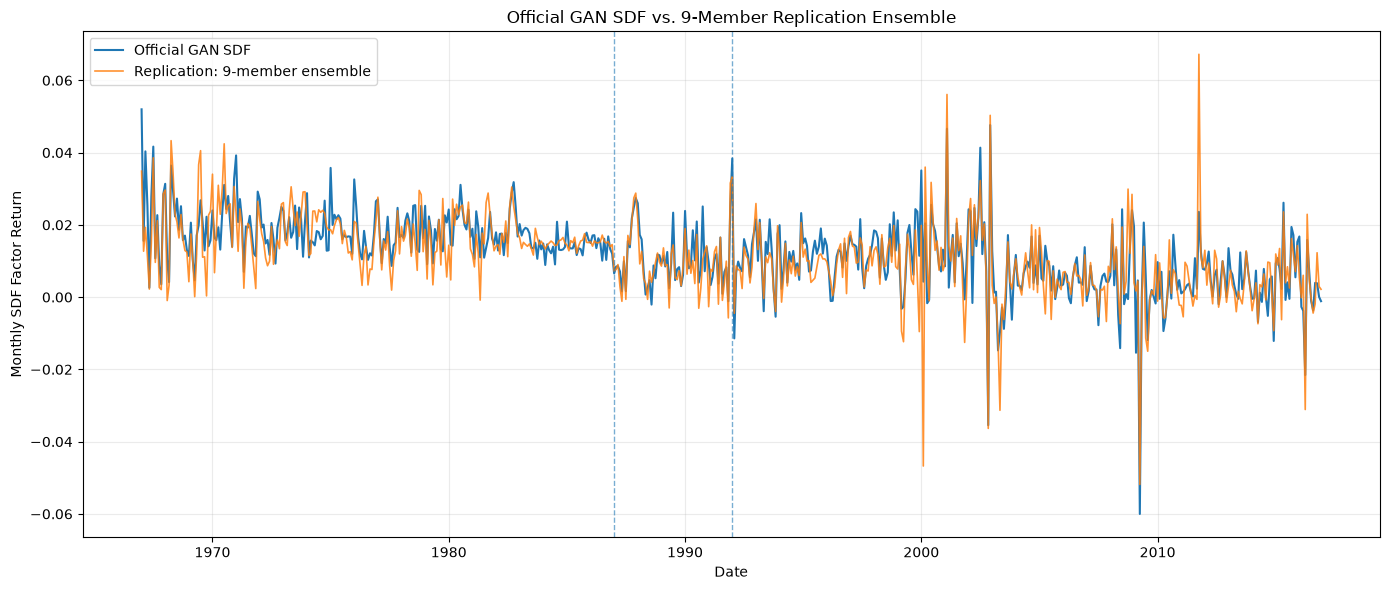

In [63]:
# ============================================================
# Part 27B — Official SDF vs replicated GAN ensemble
# ============================================================

import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    ensemble_official_comparison["date"],
    ensemble_official_comparison["official_sdf"],
    label="Official GAN SDF",
    linewidth=1.5,
)

ax.plot(
    ensemble_official_comparison["date"],
    ensemble_official_comparison["ensemble_sdf"],
    label="Replication: 9-member ensemble",
    linewidth=1.2,
    alpha=0.85,
)

# Train / validation / test boundaries
ax.axvline(
    pd.Timestamp("1986-12-31"),
    linestyle="--",
    linewidth=1,
    alpha=0.6,
)

ax.axvline(
    pd.Timestamp("1991-12-31"),
    linestyle="--",
    linewidth=1,
    alpha=0.6,
)

ax.set_title(
    "Official GAN SDF vs. 9-Member Replication Ensemble"
)

ax.set_xlabel("Date")
ax.set_ylabel("Monthly SDF Factor Return")

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Visual Comparison

The replicated nine-member GAN ensemble tracks the official SDF closely over
the 1967–2016 sample. The two series display similar broad time-series
variation, although some differences remain during periods with larger
factor-return movements.

This visual agreement is consistent with the quantitative results: the
full-sample correlation is 0.816, while the test-period correlation is 0.800.
The ensemble therefore captures a substantial portion of the dynamics of the
official SDF despite not reproducing the official series exactly.

In [64]:
# ============================================================
# Part 28A — Individual GAN member performance
# ============================================================

gan_member_summary = pd.DataFrame(
    all_member_summaries
)

# Make sure all nine members are present
assert len(gan_member_summary) == 9

assert sorted(
    gan_member_summary["member"].tolist()
) == list(range(1, 10))


member_sharpe_table = (
    gan_member_summary[
        [
            "member",
            "seed",
            "train_monthly_sharpe",
            "validation_monthly_sharpe",
            "test_monthly_sharpe",
        ]
    ]
    .sort_values("member")
    .reset_index(drop=True)
)

display(
    member_sharpe_table
)

,member,seed,train_monthly_sharpe,validation_monthly_sharpe,test_monthly_sharpe
0,1,42,1.838621,0.906674,0.321121
1,2,43,2.031429,0.685937,0.384286
2,3,44,1.740929,0.381331,0.341909
3,4,45,1.690065,0.413271,0.238862
4,5,46,1.971251,0.908532,0.513201
5,6,47,2.134443,0.954154,0.558370
6,7,48,1.558524,0.698820,0.428840
7,8,49,1.580727,0.540099,0.569579
8,9,50,2.005286,0.731261,0.496329


In [65]:
# ============================================================
# Part 28A — Cross-seed Sharpe diagnostics
# ============================================================

seed_sharpe_summary = pd.DataFrame(
    {
        "split": [
            "train",
            "validation",
            "test",
        ],

        "mean_member_sharpe": [
            member_sharpe_table[
                "train_monthly_sharpe"
            ].mean(),

            member_sharpe_table[
                "validation_monthly_sharpe"
            ].mean(),

            member_sharpe_table[
                "test_monthly_sharpe"
            ].mean(),
        ],

        "median_member_sharpe": [
            member_sharpe_table[
                "train_monthly_sharpe"
            ].median(),

            member_sharpe_table[
                "validation_monthly_sharpe"
            ].median(),

            member_sharpe_table[
                "test_monthly_sharpe"
            ].median(),
        ],

        "minimum_member_sharpe": [
            member_sharpe_table[
                "train_monthly_sharpe"
            ].min(),

            member_sharpe_table[
                "validation_monthly_sharpe"
            ].min(),

            member_sharpe_table[
                "test_monthly_sharpe"
            ].min(),
        ],

        "maximum_member_sharpe": [
            member_sharpe_table[
                "train_monthly_sharpe"
            ].max(),

            member_sharpe_table[
                "validation_monthly_sharpe"
            ].max(),

            member_sharpe_table[
                "test_monthly_sharpe"
            ].max(),
        ],

        "ensemble_sharpe": [
            ensemble_stats.loc[
                ensemble_stats["split"] == "train",
                "monthly_sharpe",
            ].iloc[0],

            ensemble_stats.loc[
                ensemble_stats["split"] == "validation",
                "monthly_sharpe",
            ].iloc[0],

            ensemble_stats.loc[
                ensemble_stats["split"] == "test",
                "monthly_sharpe",
            ].iloc[0],
        ],
    }
)

display(
    seed_sharpe_summary
)

,split,mean_member_sharpe,median_member_sharpe,minimum_member_sharpe,maximum_member_sharpe,ensemble_sharpe
0,train,1.839031,1.838621,1.558524,2.134443,2.218878
1,validation,0.691120,0.698820,0.381331,0.954154,1.175489
2,test,0.428055,0.428840,0.238862,0.569579,0.610867


In [66]:
# ============================================================
# Part 28A — Fix Member 9 and rebuild diagnostic table
# ============================================================

# Recover Member 9 statistics directly from its factor series
m9_train = factor_stats_from_array(
    all_member_factors[9]["train"],
    "train"
)

m9_valid = factor_stats_from_array(
    all_member_factors[9]["validation"],
    "validation"
)

m9_test = factor_stats_from_array(
    all_member_factors[9]["test"],
    "test"
)

print("Member 9 Sharpe ratios")
print(
    f"Train      : {m9_train['monthly_sharpe']:.6f}"
)
print(
    f"Validation : {m9_valid['monthly_sharpe']:.6f}"
)
print(
    f"Test       : {m9_test['monthly_sharpe']:.6f}"
)


# Update Member 9 row
mask9 = gan_member_summary["member"] == 9

gan_member_summary.loc[
    mask9,
    "train_monthly_sharpe"
] = m9_train["monthly_sharpe"]

gan_member_summary.loc[
    mask9,
    "validation_monthly_sharpe"
] = m9_valid["monthly_sharpe"]

gan_member_summary.loc[
    mask9,
    "test_monthly_sharpe"
] = m9_test["monthly_sharpe"]


# Verify no missing Sharpe values remain
sharpe_cols = [
    "train_monthly_sharpe",
    "validation_monthly_sharpe",
    "test_monthly_sharpe",
]

print(
    "\nMissing Sharpe values:",
    gan_member_summary[
        sharpe_cols
    ].isna().sum().to_dict()
)


# Rebuild individual-member table
member_sharpe_table = (
    gan_member_summary[
        [
            "member",
            "seed",
            "train_monthly_sharpe",
            "validation_monthly_sharpe",
            "test_monthly_sharpe",
        ]
    ]
    .sort_values("member")
    .reset_index(drop=True)
)

display(member_sharpe_table)


# Rebuild summary using all 9 members
seed_sharpe_summary = pd.DataFrame(
    {
        "split": [
            "train",
            "validation",
            "test",
        ],

        "mean_member_sharpe": [
            member_sharpe_table[
                "train_monthly_sharpe"
            ].mean(),

            member_sharpe_table[
                "validation_monthly_sharpe"
            ].mean(),

            member_sharpe_table[
                "test_monthly_sharpe"
            ].mean(),
        ],

        "median_member_sharpe": [
            member_sharpe_table[
                "train_monthly_sharpe"
            ].median(),

            member_sharpe_table[
                "validation_monthly_sharpe"
            ].median(),

            member_sharpe_table[
                "test_monthly_sharpe"
            ].median(),
        ],

        "minimum_member_sharpe": [
            member_sharpe_table[
                "train_monthly_sharpe"
            ].min(),

            member_sharpe_table[
                "validation_monthly_sharpe"
            ].min(),

            member_sharpe_table[
                "test_monthly_sharpe"
            ].min(),
        ],

        "maximum_member_sharpe": [
            member_sharpe_table[
                "train_monthly_sharpe"
            ].max(),

            member_sharpe_table[
                "validation_monthly_sharpe"
            ].max(),

            member_sharpe_table[
                "test_monthly_sharpe"
            ].max(),
        ],

        "ensemble_sharpe": [
            2.218878,
            1.175489,
            0.610867,
        ],
    }
)

display(seed_sharpe_summary)

Member 9 Sharpe ratios
Train      : 2.005286
Validation : 0.731261
Test       : 0.496329

Missing Sharpe values: {'train_monthly_sharpe': 0, 'validation_monthly_sharpe': 0, 'test_monthly_sharpe': 0}


,member,seed,train_monthly_sharpe,validation_monthly_sharpe,test_monthly_sharpe
0,1,42,1.838621,0.906674,0.321121
1,2,43,2.031429,0.685937,0.384286
2,3,44,1.740929,0.381331,0.341909
3,4,45,1.690065,0.413271,0.238862
4,5,46,1.971251,0.908532,0.513201
5,6,47,2.134443,0.954154,0.558370
6,7,48,1.558524,0.698820,0.428840
7,8,49,1.580727,0.540099,0.569579
8,9,50,2.005286,0.731261,0.496329


,split,mean_member_sharpe,median_member_sharpe,minimum_member_sharpe,maximum_member_sharpe,ensemble_sharpe
0,train,1.839031,1.838621,1.558524,2.134443,2.218878
1,validation,0.691120,0.698820,0.381331,0.954154,1.175489
2,test,0.428055,0.428840,0.238862,0.569579,0.610867


### Part 28B — Cross-Model Correlation

To evaluate diversification across independently trained GAN models, we compute
pairwise correlations between the normalized SDF factor returns generated by
the nine ensemble members.

Lower-than-perfect correlations indicate that different random initializations
produce related but distinct SDF estimates. Averaging these estimates can
therefore reduce model-specific noise and improve the stability of the final
ensemble.

In [67]:
# ============================================================
# Part 28B — Pairwise correlations across GAN members
# ============================================================

train_corr = pd.DataFrame(
    train_member_factors,
    columns=[
        f"M{i}"
        for i in member_ids
    ],
).corr()

validation_corr = pd.DataFrame(
    validation_member_factors,
    columns=[
        f"M{i}"
        for i in member_ids
    ],
).corr()

test_corr = pd.DataFrame(
    test_member_factors,
    columns=[
        f"M{i}"
        for i in member_ids
    ],
).corr()


print("TRAIN pairwise correlation")
display(train_corr.round(3))

print("\nVALIDATION pairwise correlation")
display(validation_corr.round(3))

print("\nTEST pairwise correlation")
display(test_corr.round(3))

TRAIN pairwise correlation


,M1,M2,M3,M4,M5,M6,M7,M8,M9
M1,1.000,0.607,0.550,0.565,0.597,0.626,0.627,0.594,0.575
M2,0.607,1.000,0.621,0.509,0.632,0.617,0.672,0.582,0.588
M3,0.550,0.621,1.000,0.572,0.625,0.593,0.726,0.578,0.598
M4,0.565,0.509,0.572,1.000,0.657,0.669,0.608,0.603,0.759
M5,0.597,0.632,0.625,0.657,1.000,0.713,0.705,0.597,0.652
M6,0.626,0.617,0.593,0.669,0.713,1.000,0.587,0.636,0.700
M7,0.627,0.672,0.726,0.608,0.705,0.587,1.000,0.630,0.638
M8,0.594,0.582,0.578,0.603,0.597,0.636,0.630,1.000,0.604
M9,0.575,0.588,0.598,0.759,0.652,0.700,0.638,0.604,1.000



VALIDATION pairwise correlation


,M1,M2,M3,M4,M5,M6,M7,M8,M9
M1,1.000,0.187,-0.092,0.334,0.479,0.262,0.215,0.036,0.296
M2,0.187,1.000,0.163,0.275,0.231,0.235,-0.056,-0.214,0.314
M3,-0.092,0.163,1.000,-0.404,-0.056,0.128,-0.070,0.434,0.055
M4,0.334,0.275,-0.404,1.000,0.631,0.605,0.334,-0.047,0.636
M5,0.479,0.231,-0.056,0.631,1.000,0.671,0.523,0.222,0.601
M6,0.262,0.235,0.128,0.605,0.671,1.000,0.485,0.373,0.592
M7,0.215,-0.056,-0.070,0.334,0.523,0.485,1.000,0.310,0.244
M8,0.036,-0.214,0.434,-0.047,0.222,0.373,0.310,1.000,0.405
M9,0.296,0.314,0.055,0.636,0.601,0.592,0.244,0.405,1.000



TEST pairwise correlation


,M1,M2,M3,M4,M5,M6,M7,M8,M9
M1,1.000,0.593,0.274,0.376,0.620,0.555,0.448,0.302,0.380
M2,0.593,1.000,0.261,0.394,0.568,0.574,0.364,0.208,0.512
M3,0.274,0.261,1.000,0.224,0.432,0.391,0.350,0.224,0.207
M4,0.376,0.394,0.224,1.000,0.442,0.496,0.503,0.165,0.562
M5,0.620,0.568,0.432,0.442,1.000,0.699,0.511,0.349,0.508
M6,0.555,0.574,0.391,0.496,0.699,1.000,0.534,0.361,0.494
M7,0.448,0.364,0.350,0.503,0.511,0.534,1.000,0.352,0.353
M8,0.302,0.208,0.224,0.165,0.349,0.361,0.352,1.000,0.138
M9,0.380,0.512,0.207,0.562,0.508,0.494,0.353,0.138,1.000


In [68]:
# ============================================================
# Part 28B — Summary of off-diagonal correlations
# ============================================================

def off_diagonal_corr_stats(
    corr_matrix,
    split,
):
    values = corr_matrix.to_numpy()

    mask = ~np.eye(
        values.shape[0],
        dtype=bool,
    )

    off_diag = values[mask]

    return {
        "split": split,
        "mean_pairwise_corr":
            off_diag.mean(),
        "median_pairwise_corr":
            np.median(off_diag),
        "minimum_pairwise_corr":
            off_diag.min(),
        "maximum_pairwise_corr":
            off_diag.max(),
    }


pairwise_corr_summary = pd.DataFrame(
    [
        off_diagonal_corr_stats(
            train_corr,
            "train",
        ),
        off_diagonal_corr_stats(
            validation_corr,
            "validation",
        ),
        off_diagonal_corr_stats(
            test_corr,
            "test",
        ),
    ]
)

display(
    pairwise_corr_summary
)

,split,mean_pairwise_corr,median_pairwise_corr,minimum_pairwise_corr,maximum_pairwise_corr
0,train,0.622491,0.612410,0.509226,0.758600
1,validation,0.259417,0.268706,-0.403900,0.670627
2,test,0.408912,0.392219,0.137954,0.698928


### Interpretation of Cross-Model Correlations

The independently trained GAN models exhibit meaningful variation across random
initializations. During the training period, the average pairwise correlation
is 0.622, indicating that the models learn a broadly common SDF structure.

Cross-model correlations are considerably lower during validation, with an
average correlation of 0.259 and some negative pairwise correlations. This
reflects greater estimation uncertainty outside the training sample and is also
affected by the relatively short 60-month validation period.

During the 300-month test period, the average pairwise correlation is 0.409.
All pairwise test correlations are positive, indicating that the models share a
common underlying economic signal while still providing meaningful
cross-model diversification.

This diversity is beneficial for ensembling. Averaging across the nine GAN
members reduces model-specific variation and produces higher Sharpe ratios than
the average individual model in the training, validation, and test samples.
The ensemble also achieves a strong 0.800 correlation with the official SDF
during the test period.

In [69]:
# ============================================================
# Part 29 — Save final GAN replication outputs
# ============================================================

# ------------------------------------------------------------
# 1. Save final member summary
# ------------------------------------------------------------

gan_member_summary.to_csv(
    TABLE_DIR / "gan_member_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 2. Save ensemble performance
# ------------------------------------------------------------

ensemble_stats.to_csv(
    TABLE_DIR / "gan_ensemble_performance.csv",
    index=False,
)


# ------------------------------------------------------------
# 3. Save benchmark comparison
# ------------------------------------------------------------

benchmark_comparison.to_csv(
    TABLE_DIR / "gan_benchmark_comparison.csv",
    index=False,
)


# ------------------------------------------------------------
# 4. Save pairwise-correlation summary
# ------------------------------------------------------------

pairwise_corr_summary.to_csv(
    TABLE_DIR / "gan_pairwise_correlation_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 5. Save official-vs-replication comparison
# ------------------------------------------------------------

ensemble_official_comparison.to_csv(
    TABLE_DIR / "gan_official_sdf_comparison.csv",
    index=False,
)


# ------------------------------------------------------------
# 6. Save final 600-month ensemble factor
# ------------------------------------------------------------

final_gan_factor = pd.DataFrame(
    {
        "date":
            ensemble_official_comparison["date"],

        "gan_ensemble_sdf":
            gan_ensemble_full,
    }
)

final_gan_factor.to_csv(
    FACTOR_DIR / "gan_ensemble_sdf.csv",
    index=False,
)


print("Saved final GAN outputs:")
print()

for path in [
    TABLE_DIR / "gan_member_summary.csv",
    TABLE_DIR / "gan_ensemble_performance.csv",
    TABLE_DIR / "gan_benchmark_comparison.csv",
    TABLE_DIR / "gan_pairwise_correlation_summary.csv",
    TABLE_DIR / "gan_official_sdf_comparison.csv",
    FACTOR_DIR / "gan_ensemble_sdf.csv",
]:
    print(
        f"{path.name}:",
        path.exists(),
    )

Saved final GAN outputs:

gan_member_summary.csv: True
gan_ensemble_performance.csv: True
gan_benchmark_comparison.csv: True
gan_pairwise_correlation_summary.csv: True
gan_official_sdf_comparison.csv: True
gan_ensemble_sdf.csv: True


In [70]:
# ============================================================
# Part 29B — Final integrity check of saved GAN outputs
# ============================================================

# Reload saved files from disk
saved_member_summary = pd.read_csv(
    TABLE_DIR / "gan_member_summary.csv"
)

saved_ensemble_stats = pd.read_csv(
    TABLE_DIR / "gan_ensemble_performance.csv"
)

saved_benchmark = pd.read_csv(
    TABLE_DIR / "gan_benchmark_comparison.csv"
)

saved_pairwise = pd.read_csv(
    TABLE_DIR / "gan_pairwise_correlation_summary.csv"
)

saved_official_compare = pd.read_csv(
    TABLE_DIR / "gan_official_sdf_comparison.csv"
)

saved_final_factor = pd.read_csv(
    FACTOR_DIR / "gan_ensemble_sdf.csv"
)


print("=" * 65)
print("FINAL GAN OUTPUT INTEGRITY CHECK")
print("=" * 65)


# ------------------------------------------------------------
# 1. Member summary
# ------------------------------------------------------------

print("\n1. GAN member summary")

print(
    "Rows:",
    len(saved_member_summary),
)

print(
    "Members:",
    saved_member_summary["member"].tolist(),
)

sharpe_cols = [
    "train_monthly_sharpe",
    "validation_monthly_sharpe",
    "test_monthly_sharpe",
]

print(
    "Missing Sharpe values:",
    saved_member_summary[
        sharpe_cols
    ].isna().sum().sum(),
)


# ------------------------------------------------------------
# 2. Ensemble performance
# ------------------------------------------------------------

print("\n2. Ensemble performance")

print(
    "Rows:",
    len(saved_ensemble_stats),
)

print(
    "Splits:",
    saved_ensemble_stats["split"].tolist(),
)


# ------------------------------------------------------------
# 3. Benchmark comparison
# ------------------------------------------------------------

print("\n3. Benchmark comparison")

print(
    "Rows:",
    len(saved_benchmark),
)

display(
    saved_benchmark[
        [
            "split",
            "monthly_sharpe",
            "official_monthly_sharpe",
            "percent_of_official",
        ]
    ]
)


# ------------------------------------------------------------
# 4. Pairwise-correlation summary
# ------------------------------------------------------------

print("\n4. Pairwise correlation summary")

print(
    "Rows:",
    len(saved_pairwise),
)

print(
    "Splits:",
    saved_pairwise["split"].tolist(),
)


# ------------------------------------------------------------
# 5. Official SDF comparison
# ------------------------------------------------------------

print("\n5. Official SDF comparison")

print(
    "Rows:",
    len(saved_official_compare),
)

print(
    "Missing values:",
    saved_official_compare.isna().sum().sum(),
)


# ------------------------------------------------------------
# 6. Final ensemble factor
# ------------------------------------------------------------

print("\n6. Final ensemble SDF")

print(
    "Rows:",
    len(saved_final_factor),
)

print(
    "Missing values:",
    saved_final_factor.isna().sum().sum(),
)

print(
    "Unique dates:",
    saved_final_factor["date"].nunique(),
)


# ------------------------------------------------------------
# 7. Hard assertions
# ------------------------------------------------------------

assert len(saved_member_summary) == 9
assert sorted(saved_member_summary["member"]) == list(range(1, 10))
assert saved_member_summary[sharpe_cols].isna().sum().sum() == 0

assert len(saved_ensemble_stats) == 3
assert len(saved_benchmark) == 3
assert len(saved_pairwise) == 3

assert len(saved_official_compare) == 600
assert len(saved_final_factor) == 600

assert saved_final_factor[
    "gan_ensemble_sdf"
].notna().all()

assert saved_final_factor[
    "date"
].nunique() == 600


print("\n" + "=" * 65)
print("✓ ALL FINAL GAN OUTPUT CHECKS PASSED")
print("=" * 65)

FINAL GAN OUTPUT INTEGRITY CHECK

1. GAN member summary
Rows: 9
Members: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Missing Sharpe values: 0

2. Ensemble performance
Rows: 3
Splits: ['train', 'validation', 'test']

3. Benchmark comparison
Rows: 3


,split,monthly_sharpe,official_monthly_sharpe,percent_of_official
0,train,2.218878,2.677974,82.856599
1,validation,1.175489,1.415615,83.037344
2,test,0.610867,0.748669,81.593722



4. Pairwise correlation summary
Rows: 3
Splits: ['train', 'validation', 'test']

5. Official SDF comparison
Rows: 600
Missing values: 0

6. Final ensemble SDF
Rows: 600
Missing values: 0
Unique dates: 600

✓ ALL FINAL GAN OUTPUT CHECKS PASSED


# Part 30 — Final GAN Replication Summary

This notebook implements a PyTorch reconstruction of the GAN-based stochastic
discount factor framework of Chen, Pelger, and Zhu using the supplied firm-level
characteristics, macroeconomic predictors, and official sample splits.

## Model Design

The GAN consists of two components:

1. **SDF network**
   - 46 firm characteristics
   - 4-dimensional macroeconomic LSTM state
   - Feed-forward architecture: 64 → 64 → 1
   - ReLU activation
   - Dropout = 0.05

2. **Conditional-instrument network**
   - 46 firm characteristics
   - 32-dimensional macroeconomic LSTM state
   - 8 learned conditional instruments

The model is estimated using the three-stage procedure:

- Stage 1: 256 epochs of unconditional SDF estimation
- Stage 2: 64 epochs of adversarial conditional-instrument estimation
- Stage 3: 1024 epochs of conditional SDF estimation

Nine independent GAN models are trained using seeds 42–50 and combined using
an equal-weight ensemble.

## Replication Results

The final nine-member ensemble produces the following monthly Sharpe ratios:

| Sample | Replication | Official | % of Official |
|---|---:|---:|---:|
| Training | 2.219 | 2.678 | 82.9% |
| Validation | 1.175 | 1.416 | 83.0% |
| Test | 0.611 | 0.749 | 81.6% |

The ensemble substantially improves upon the typical individual GAN model.
Across the nine independently estimated members, average monthly Sharpe ratios
are approximately 1.84, 0.69, and 0.43 for the training, validation, and test
samples, respectively, while the ensemble achieves 2.22, 1.18, and 0.61.

## Comparison with the Official SDF

The replicated ensemble is strongly correlated with the official SDF:

| Sample | Correlation |
|---|---:|
| Training | 0.650 |
| Validation | 0.837 |
| Test | 0.800 |
| Full sample | 0.816 |

The strong validation and test correlations indicate that the replicated GAN
captures a substantial portion of the time-series variation in the official
SDF outside the training sample.

## Cross-Model Diversification

Average pairwise correlations across independently trained GAN members are:

| Sample | Mean Pairwise Correlation |
|---|---:|
| Training | 0.622 |
| Validation | 0.259 |
| Test | 0.409 |

The individual models therefore learn related but non-identical pricing
functions. This cross-model variation creates a meaningful diversification
benefit when the nine SDF estimates are averaged.

## Overall Assessment

The replication successfully reproduces the central economic behavior of the
GAN asset-pricing model. The final SDF does not exactly reproduce the official
factor or its reported Sharpe ratios, which is expected because this notebook
is a PyTorch reconstruction rather than a line-by-line reproduction of the
original TensorFlow implementation.

Nevertheless, the replication produces:

- stable three-stage GAN training,
- economically meaningful SDF factors,
- positive out-of-sample Sharpe ratios,
- substantial improvement from model ensembling,
- approximately 82% of the official Sharpe ratio across all three sample
  periods, and
- an out-of-sample correlation of approximately 0.80 with the official SDF.

These results provide strong evidence that the implemented model captures the
main empirical mechanism of the original GAN-based asset-pricing framework.

In [71]:
# ============================================================
# Part 30 — Final Code 06 completion check
# ============================================================

print("=" * 72)
print("CODE 06 — GAN ASSET PRICING FINAL CHECK")
print("=" * 72)


# ------------------------------------------------------------
# 1. Nine trained GAN members
# ------------------------------------------------------------

assert len(member_ids) == 9
assert member_ids == list(range(1, 10))

print("✓ Nine independent GAN members")


# ------------------------------------------------------------
# 2. Factor dimensions
# ------------------------------------------------------------

assert train_member_factors.shape == (240, 9)
assert validation_member_factors.shape == (60, 9)
assert test_member_factors.shape == (300, 9)

assert gan_ensemble_train.shape == (240,)
assert gan_ensemble_validation.shape == (60,)
assert gan_ensemble_test.shape == (300,)
assert gan_ensemble_full.shape == (600,)

print("✓ Train / validation / test dimensions correct")


# ------------------------------------------------------------
# 3. Finite factors
# ------------------------------------------------------------

assert np.isfinite(
    gan_ensemble_full
).all()

print("✓ Final ensemble contains only finite values")


# ------------------------------------------------------------
# 4. Member Sharpe completeness
# ------------------------------------------------------------

assert len(
    gan_member_summary
) == 9

sharpe_columns = [
    "train_monthly_sharpe",
    "validation_monthly_sharpe",
    "test_monthly_sharpe",
]

assert (
    gan_member_summary[
        sharpe_columns
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

print("✓ All nine member performance statistics available")


# ------------------------------------------------------------
# 5. Final ensemble Sharpe ratios
# ------------------------------------------------------------

final_sharpes = {
    row["split"]:
        row["monthly_sharpe"]
    for _, row in ensemble_stats.iterrows()
}

print("\nFinal replication monthly Sharpe ratios:")

print(
    f"  Train      : "
    f"{final_sharpes['train']:.6f}"
)

print(
    f"  Validation : "
    f"{final_sharpes['validation']:.6f}"
)

print(
    f"  Test       : "
    f"{final_sharpes['test']:.6f}"
)


# ------------------------------------------------------------
# 6. Official comparison
# ------------------------------------------------------------

print("\nOfficial monthly Sharpe ratios:")

print("  Train      : 2.677974")
print("  Validation : 1.415615")
print("  Test       : 0.748669")


print("\nPercent of official benchmark:")

for _, row in benchmark_comparison.iterrows():

    print(
        f"  {row['split']:<10}: "
        f"{row['percent_of_official']:.2f}%"
    )


# ------------------------------------------------------------
# 7. Official-SDF correlations
# ------------------------------------------------------------

print("\nCorrelation with official SDF:")

print(
    f"  Full sample: "
    f"{full_ensemble_correlation:.6f}"
)

for _, row in (
    ensemble_correlation_by_split
    .sort_values(
        "split",
        key=lambda x: x.map(
            {
                "train": 0,
                "validation": 1,
                "test": 2,
            }
        )
    )
    .iterrows()
):

    print(
        f"  {row['split']:<10}: "
        f"{row['correlation']:.6f}"
    )


# ------------------------------------------------------------
# 8. Saved final outputs
# ------------------------------------------------------------

required_output_files = [
    TABLE_DIR / "gan_member_summary.csv",
    TABLE_DIR / "gan_ensemble_performance.csv",
    TABLE_DIR / "gan_benchmark_comparison.csv",
    TABLE_DIR / "gan_pairwise_correlation_summary.csv",
    TABLE_DIR / "gan_official_sdf_comparison.csv",
    FACTOR_DIR / "gan_ensemble_sdf.csv",
]

for path in required_output_files:
    assert path.exists(), (
        f"Missing output file: {path}"
    )

print("\n✓ All final result files saved")


# ------------------------------------------------------------
# 9. Nine model checkpoints
# ------------------------------------------------------------

checkpoint_files = [
    MODEL_DIR
    / f"gan_member_{member:02d}_seed_{seed}.pt"
    for member, seed in zip(
        range(1, 10),
        GAN_SEEDS,
    )
]

for path in checkpoint_files:
    assert path.exists(), (
        f"Missing checkpoint: {path}"
    )

print("✓ All nine GAN checkpoints saved")


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("✓ CODE 06 GAN REPLICATION COMPLETE")
print("=" * 72)

CODE 06 — GAN ASSET PRICING FINAL CHECK
✓ Nine independent GAN members
✓ Train / validation / test dimensions correct
✓ Final ensemble contains only finite values
✓ All nine member performance statistics available

Final replication monthly Sharpe ratios:
  Train      : 2.218878
  Validation : 1.175489
  Test       : 0.610867

Official monthly Sharpe ratios:
  Train      : 2.677974
  Validation : 1.415615
  Test       : 0.748669

Percent of official benchmark:
  train     : 82.86%
  validation: 83.04%
  test      : 81.59%

Correlation with official SDF:
  Full sample: 0.815782
  train     : 0.650285
  validation: 0.837413
  test      : 0.800484

✓ All final result files saved
✓ All nine GAN checkpoints saved

✓ CODE 06 GAN REPLICATION COMPLETE
